# ECOMMERCE RETURN & CUSTOMER BEHAVIOUR ANALYSIS

### Importing required libraries

In [1838]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Customers

In [1839]:
customers=pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/customers.csv")
customers.head()

,customer_id,customer_name,gender,age,city,state,signup_date,loyalty_tier,customer_status,annual_spend
0,100001,Nandini Shinde,Female,54,Indore,Madhya Pradesh,12-06-2023,Regular,Active,16515.62
1,100002,Pallavi Ghosh,FEMALE,41,Mumbai,Maharashtra,11-01-2021,Silver,Inactive,98509.42
2,100003,Vishal Srivastava,F,55,Pune,Maharashtra,24-02-2019,Silver,Inactive,7707.72
3,100004,Rahul Sen,Female,27,Delhi,Delhi,02-05-2020,Regular,Active,8848.62
4,100005,Rekha Singh,F,68,Hyderabad,Telangana,23-01-2024,Silver,Inactive,127193.74


In [1840]:
customers.shape

(50000, 10)

In [1841]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      50000 non-null  int64  
 1   customer_name    50000 non-null  object 
 2   gender           50000 non-null  object 
 3   age              50000 non-null  int64  
 4   city             50000 non-null  object 
 5   state            48429 non-null  object 
 6   signup_date      50000 non-null  object 
 7   loyalty_tier     48952 non-null  object 
 8   customer_status  50000 non-null  object 
 9   annual_spend     49078 non-null  float64
dtypes: float64(1), int64(2), object(7)
memory usage: 3.8+ MB


In [1842]:
customers.isna().sum()

customer_id           0
customer_name         0
gender                0
age                   0
city                  0
state              1571
signup_date           0
loyalty_tier       1048
customer_status       0
annual_spend        922
dtype: int64

In [1843]:
# convert signup_date column from object to datetime type
customers['signup_date'] = pd.to_datetime( customers['signup_date'],errors='coerce')
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      50000 non-null  int64         
 1   customer_name    50000 non-null  object        
 2   gender           50000 non-null  object        
 3   age              50000 non-null  int64         
 4   city             50000 non-null  object        
 5   state            48429 non-null  object        
 6   signup_date      19690 non-null  datetime64[ns]
 7   loyalty_tier     48952 non-null  object        
 8   customer_status  50000 non-null  object        
 9   annual_spend     49078 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 3.8+ MB


In [1844]:
# check inconsistency values
customers['gender'].value_counts()

gender
Male      18994
Female    18824
M          2617
FEMALE     2561
male       2526
F          2481
Other      1997
Name: count, dtype: int64

In [1845]:
# standardize gender values
customers['gender'] = customers['gender'].astype(str).str.strip().str.lower()

customers['gender'] = customers['gender'].replace({
    'M': 'Male',
    'm': 'Male',
    'male': 'Male',
     'f': 'Female',
    'F': 'Female',
    'female': 'Female',
    'FEMALE': 'Female'
})
customers['gender'].value_counts()

gender
Male      24137
Female    23866
other      1997
Name: count, dtype: int64

In [1846]:
# checking invalid ages
negative_ages=(customers['age']<0).sum()
print("negative ages:",negative_ages)

customers['age'] = pd.to_numeric(customers['age'], errors='coerce')
print("Before cleaning:")
print(customers["age"].describe())

negative ages: 85
Before cleaning:
count    50000.000000
mean        46.808620
std         18.580091
min         -5.000000
25%         32.000000
50%         46.000000
75%         61.000000
max        200.000000
Name: age, dtype: float64


In [1847]:
Q1 = customers['age'].quantile(0.25)
Q3 = customers['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("lower bound:",lower_bound)
print("upper bound:", upper_bound)

age_outliers = customers[
    (customers['age'] < lower_bound) |
    (customers['age'] > upper_bound)
]
print( "count no of ouliers:",age_outliers.shape[0])
age_outliers

lower bound: -11.5
upper bound: 104.5
count no of ouliers: 234


,customer_id,customer_name,gender,age,city,state,signup_date,loyalty_tier,customer_status,annual_spend
243,100244,Nandini Pillai,Male,200,Chennai,Tamil Nadu,NaT,Gold,Active,81739.75
444,100445,Geeta Verma,Female,200,Indore,Madhya Pradesh,2019-10-08,Regular,Active,182460.14
641,100642,Manoj Chakraborty,Female,200,Jaipur,Rajasthan,NaT,Gold,Active,102232.41
740,100741,Lata Gaikwad,Male,150,Chennai,Tamil Nadu,NaT,Gold,Inactive,NaN
746,100747,Divya Krishnan,Female,105,Hyderabad,Telangana,2022-03-09,Silver,Active,142634.85
...,...,...,...,...,...,...,...,...,...,...
48728,148729,Sridhar Sen,Female,105,Pune,Maharashtra,2021-03-09,Platinum,Active,151961.20
49133,149134,Santosh Roy,Male,105,Indore,Madhya Pradesh,NaT,Silver,Active,142386.33
49228,149229,Geeta Thorat,Male,200,Delhi,Delhi,NaT,Regular,Active,60793.24
49545,149546,Sona Srivastava,Female,200,Gurugram,Haryana,2023-10-11,Silver,Active,157803.50


In [1848]:
# Step 1: See what the outlier values actually are 
age_outliers = customers[
    (customers["age"] < 0) | (customers["age"] > 104)
]

print("Total outliers:", len(age_outliers))
print("\nOutlier age values:")
print(age_outliers["age"].value_counts().sort_index())


# ── Step 2: Check distribution of outliers 
print("Negative ages  :", (customers["age"] < 0).sum())
print("Age below 18   :", (customers["age"] < 18).sum())   
print("Age above 80   :", (customers["age"] > 80).sum())   
print("Age above 100  :", (customers["age"] > 100).sum())
print("Extreme (>150) :", (customers["age"] > 150).sum())

Total outliers: 319

Outlier age values:
age
-5      85
 105    71
 150    87
 200    76
Name: count, dtype: int64
Negative ages  : 85
Age below 18   : 256
Age above 80   : 234
Age above 100  : 234
Extreme (>150) : 76


In [1849]:
#Replace with NaN then fill with median
customers["age"] = customers["age"].where(
    customers["age"].between(18, 104), np.nan
)
customers["age"] = customers["age"].fillna(
    customers["age"].median()
).round().astype(int)

 #: Verify 
print("After cleaning:")
print(customers["age"].describe())

After cleaning:
count    50000.000000
mean        46.542500
std         16.607461
min         18.000000
25%         32.000000
50%         47.000000
75%         61.000000
max         75.000000
Name: age, dtype: float64


In [1850]:
# standardize the categorical caolumn labels

customers["city"]=customers["city"].astype(str).str.title()
customers["state"]=customers["state"].astype(str).str.title()
customers["loyalty_tier"]=customers["loyalty_tier"].astype(str).str.title()
customers["customer_status"]=customers["customer_status"].astype(str).str.title()


In [1851]:
print(customers["city"].value_counts())
print(customers["state"].value_counts())
print(customers["loyalty_tier"].value_counts())
print(customers["customer_status"].value_counts())

city
Pune                  3443
Bangalore             3400
Mumbai                3392
Chennai               3382
Jaipur                3366
Thiruvananthapuram    3355
Kolkata               3349
Lucknow               3296
Ahmedabad             3295
Noida                 3295
Hyderabad             3293
Visakhapatnam         3293
Indore                3289
Gurugram              3281
Delhi                 3271
Name: count, dtype: int64
state
Maharashtra       6610
Uttar Pradesh     6393
Karnataka         3296
Tamil Nadu        3279
Rajasthan         3261
Kerala            3248
West Bengal       3248
Gujarat           3203
Andhra Pradesh    3197
Haryana           3188
Telangana         3173
Madhya Pradesh    3172
Delhi             3161
Nan               1571
Name: count, dtype: int64
loyalty_tier
Regular     23437
Silver      13470
Gold         8022
Platinum     4023
Nan          1048
Name: count, dtype: int64
customer_status
Active      37921
Inactive     8061
Blocked      3499
Invalid    

In [1852]:
customers['state'] = customers['state'].replace('Nan', np.nan)
customers['loyalty_tier'] = customers['loyalty_tier'].replace('Nan', np.nan)
print(customers["state"].value_counts())
print(customers["state"].isna().sum())
print(customers["loyalty_tier"].value_counts())
print(customers["loyalty_tier"].isna().sum())

state
Maharashtra       6610
Uttar Pradesh     6393
Karnataka         3296
Tamil Nadu        3279
Rajasthan         3261
Kerala            3248
West Bengal       3248
Gujarat           3203
Andhra Pradesh    3197
Haryana           3188
Telangana         3173
Madhya Pradesh    3172
Delhi             3161
Name: count, dtype: int64
1571
loyalty_tier
Regular     23437
Silver      13470
Gold         8022
Platinum     4023
Name: count, dtype: int64
1048


In [1853]:
# fill based on cities
state_mode = customers.groupby("city")["state"].apply(lambda x: x.mode()[0])
customers['state'] = customers.groupby('city')['state'].transform(lambda x: x.fillna(x.mode()[0]))
customers["state"].isna().sum()

np.int64(0)

In [1854]:
loyalty_tier_mode = customers['loyalty_tier'].mode()[0]
print(f"The mode of 'loyalty_tier' is: {loyalty_tier_mode}")
# fill with most frequent value of loyalty tier
customers['loyalty_tier'] = customers['loyalty_tier'].fillna(loyalty_tier_mode)

customers["loyalty_tier"].isna().sum()

The mode of 'loyalty_tier' is: Regular


np.int64(0)

In [1855]:
# check future dates
(customers['signup_date'] > pd.Timestamp.today()).sum()

np.int64(60)

In [1856]:
# fill with median date
today = pd.Timestamp.today()
customers.loc[
    customers["signup_date"] > today,
    "signup_date"
] = pd.NaT

median_date = customers["signup_date"].dropna().median()

customers["signup_date"] = customers["signup_date"].fillna(median_date)
(customers['signup_date'] > pd.Timestamp.today()).sum()

np.int64(0)

In [1857]:
customers['annual_spend'].describe()

count    4.907800e+04
mean     1.630332e+05
std      6.539805e+05
min      5.024500e+02
25%      5.126361e+04
50%      1.017815e+05
75%      1.521000e+05
max      9.999485e+06
Name: annual_spend, dtype: float64

In [1858]:
customers['annual_spend'].isna().sum()

np.int64(922)

In [1859]:
# check missing values 
missing=customers['annual_spend'].isna().sum()
print(f"missing values:{missing}")
# fill with loyalty tier values based on fill median 
customers["annual_spend"] = customers.groupby("loyalty_tier")["annual_spend"].transform(
    lambda x: x.fillna(x.median())
)

fill_missing=customers['annual_spend'].isna().sum()
print(f"after filling missing values:{fill_missing}")

missing values:922
after filling missing values:0


In [1860]:
customers.head()

,customer_id,customer_name,gender,age,city,state,signup_date,loyalty_tier,customer_status,annual_spend
0,100001,Nandini Shinde,Female,54,Indore,Madhya Pradesh,2023-12-06,Regular,Active,16515.62
1,100002,Pallavi Ghosh,Female,41,Mumbai,Maharashtra,2021-11-01,Silver,Inactive,98509.42
2,100003,Vishal Srivastava,Female,55,Pune,Maharashtra,2022-02-11,Silver,Inactive,7707.72
3,100004,Rahul Sen,Female,27,Delhi,Delhi,2020-02-05,Regular,Active,8848.62
4,100005,Rekha Singh,Female,68,Hyderabad,Telangana,2022-02-11,Silver,Inactive,127193.74


In [1861]:
customers.to_csv('customers_clean.csv', index=False)


## customers EDA

###  Total Customers

In [1862]:
total_customers = customers['customer_id'].nunique()

print("Total Customers :", total_customers)

Total Customers : 50000


### Gender Distribution

In [1863]:
customers['gender'].value_counts()

gender
Male      24137
Female    23866
other      1997
Name: count, dtype: int64

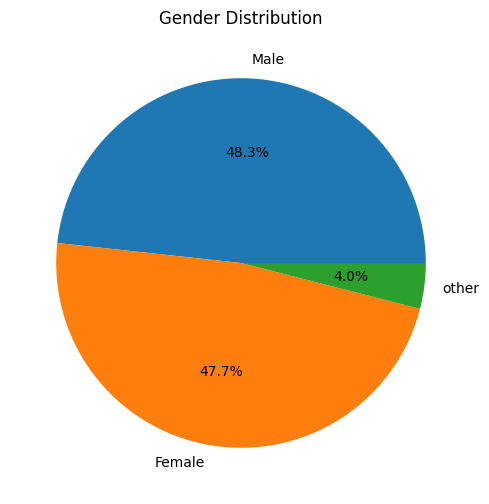

In [1864]:
customers['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

### Age Distribution

In [1865]:
customers['age'].describe()

count    50000.000000
mean        46.542500
std         16.607461
min         18.000000
25%         32.000000
50%         47.000000
75%         61.000000
max         75.000000
Name: age, dtype: float64

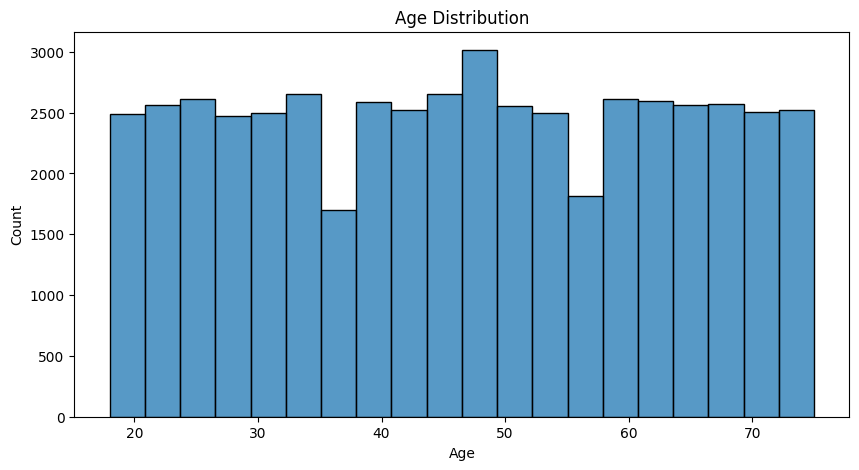

In [1866]:
plt.figure(figsize=(10,5))

sns.histplot(customers['age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

### Which Cities Generate Highest Revenue?

In [1867]:
city_revenue = customers.groupby(
    'city'
)['annual_spend'].sum().sort_values(ascending=False)

city_revenue.head(10)

city
Chennai               5.993749e+08
Gurugram              5.899922e+08
Bangalore             5.845974e+08
Hyderabad             5.775966e+08
Visakhapatnam         5.626526e+08
Kolkata               5.604490e+08
Pune                  5.395440e+08
Delhi                 5.310749e+08
Thiruvananthapuram    5.296864e+08
Mumbai                5.285150e+08
Name: annual_spend, dtype: float64

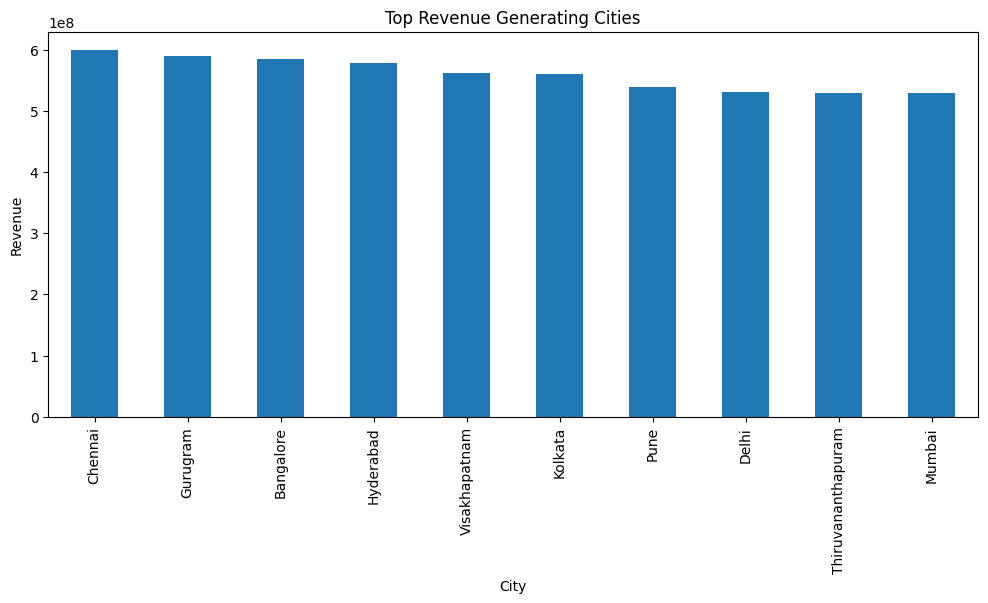

In [1868]:
city_revenue.head(10).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top Revenue Generating Cities')
plt.xlabel('City')
plt.ylabel('Revenue')

plt.show()

## Sellers

In [1869]:
sellers = pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/sellers.csv")
sellers.head()

,seller_id,seller_name,seller_city,seller_rating,seller_type,onboarding_date,return_rate_percent,seller_status
0,7001,Best Shoppe,Hyderabad,3.45,Individual,11-03-2023,146.60,Active
1,7002,Sky Plaza,Visakhapatnam,4.19,Brand,18-06-2024,14.84,Active
2,7003,Sun Retail,Gurugram,3.28,Individual,04-04-2020,10.98,Active
3,7004,Apex Gallery,Jaipur,3.50,Brand,02-01-2025,17.17,Active
4,7005,Royal Depot,Chennai,4.62,Brand,29-09-2023,12.74,Suspended


In [1870]:
sellers.shape

(2000, 8)

In [1871]:
print(sellers.info())
print(sellers.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   seller_id            2000 non-null   int64  
 1   seller_name          2000 non-null   object 
 2   seller_city          1945 non-null   object 
 3   seller_rating        2000 non-null   float64
 4   seller_type          2000 non-null   object 
 5   onboarding_date      2000 non-null   object 
 6   return_rate_percent  2000 non-null   float64
 7   seller_status        2000 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 125.1+ KB
None
seller_id               0
seller_name             0
seller_city            55
seller_rating           0
seller_type             0
onboarding_date         0
return_rate_percent     0
seller_status           0
dtype: int64


In [1872]:
#REMOVE DUPLICATE seller_id
print("Duplicate seller_id:", sellers["seller_id"].duplicated().sum())
sellers = sellers.drop_duplicates(subset="seller_id")

Duplicate seller_id: 0


In [1873]:
#CLEAN seller_name
sellers["seller_name"] = (sellers["seller_name"].astype(str).str.strip().str.title())
# CLEAN seller_city
sellers["seller_city"] = (sellers["seller_city"].astype(str).str.strip().str.title())

# Convert fake missing values to actual NaN
sellers["seller_city"] = sellers["seller_city"].replace(
    ["Nan", "nan", "None", ""],
    np.nan
)

# Fill missing city with mode
city_mode = sellers["seller_city"].mode()[0]
sellers["seller_city"] = sellers["seller_city"].fillna(city_mode)

In [1874]:
#CLEAN seller_rating
# Ratings must be between 0 and 5
invalid_rating = sellers[
    (sellers["seller_rating"] < 0) | (sellers["seller_rating"] > 5)
]
print("Invalid seller ratings:", invalid_rating.shape[0])

# Replace invalid values with NaN
sellers.loc[
    (sellers["seller_rating"] < 0) | (sellers["seller_rating"] > 5),
    "seller_rating"
] = np.nan

# Fill missing with median
sellers["seller_rating"] = sellers["seller_rating"].fillna(
    sellers["seller_rating"].median()
)

Invalid seller ratings: 26


In [1875]:
#CLEAN seller_type
sellers["seller_type"] = (
    sellers["seller_type"]
    .astype(str)
    .str.strip()
    .str.title()
)

valid_types = ["Individual", "Business", "Brand"]

invalid_types = sellers[~sellers["seller_type"].isin(valid_types)]
print("Invalid seller types:", invalid_types.shape[0])

# Replace invalid labels with mode
type_mode = sellers["seller_type"].mode()[0]
sellers.loc[
    ~sellers["seller_type"].isin(valid_types),
    "seller_type"
] = type_mode

Invalid seller types: 0


In [1876]:
#CLEAN onboarding_date
sellers["onboarding_date"] = pd.to_datetime(
    sellers["onboarding_date"],
    errors="coerce"
)

today = pd.Timestamp.today().normalize()

# Future dates are invalid
future_dates = sellers[sellers["onboarding_date"] > today]
print("Future onboarding dates:", future_dates.shape[0])

# Replace future dates with NaT
sellers.loc[sellers["onboarding_date"] > today, "onboarding_date"] = pd.NaT

# Fill missing with median date
if sellers["onboarding_date"].notna().any():
    sellers["onboarding_date"] = sellers["onboarding_date"].fillna(
        sellers["onboarding_date"].median()
    )

Future onboarding dates: 2


In [1877]:
#CLEAN return_rate_percent
# Must be between 0 and 100
invalid_return_rate = sellers[
    (sellers["return_rate_percent"] < 0) |
    (sellers["return_rate_percent"] > 100)
]
print("Invalid return rate values:", invalid_return_rate.shape[0])

sellers.loc[
    (sellers["return_rate_percent"] < 0) |
    (sellers["return_rate_percent"] > 100),
    "return_rate_percent"
] = np.nan

sellers["return_rate_percent"] = sellers["return_rate_percent"].fillna(
    sellers["return_rate_percent"].median()
)

# Optional: cap extreme values using IQR
Q1 = sellers["return_rate_percent"].quantile(0.25)
Q3 = sellers["return_rate_percent"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = min(100, Q3 + 1.5 * IQR)

sellers["return_rate_percent"] = sellers["return_rate_percent"].clip(
    lower=lower_bound,
    upper=upper_bound
)

Invalid return rate values: 25


In [1878]:
#CLEAN seller_status
sellers["seller_status"] = (
    sellers["seller_status"]
    .astype(str)
    .str.strip()
    .str.title()
)

valid_status = ["Active", "Suspended", "Inactive"]

invalid_status = sellers[~sellers["seller_status"].isin(valid_status)]
print("Invalid seller status labels:", invalid_status.shape[0])

status_mode = sellers["seller_status"].mode()[0]
sellers.loc[
    ~sellers["seller_status"].isin(valid_status),
    "seller_status"
] = status_mode

Invalid seller status labels: 58


In [1879]:
print(sellers.info())
print(sellers.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   seller_id            2000 non-null   int64         
 1   seller_name          2000 non-null   object        
 2   seller_city          2000 non-null   object        
 3   seller_rating        2000 non-null   float64       
 4   seller_type          2000 non-null   object        
 5   onboarding_date      2000 non-null   datetime64[ns]
 6   return_rate_percent  2000 non-null   float64       
 7   seller_status        2000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 125.1+ KB
None
seller_id              0
seller_name            0
seller_city            0
seller_rating          0
seller_type            0
onboarding_date        0
return_rate_percent    0
seller_status          0
dtype: int64


In [1880]:
sellers.head()

,seller_id,seller_name,seller_city,seller_rating,seller_type,onboarding_date,return_rate_percent,seller_status
0,7001,Best Shoppe,Hyderabad,3.45,Individual,2023-11-03,11.28,Active
1,7002,Sky Plaza,Visakhapatnam,4.19,Brand,2022-09-07,14.84,Active
2,7003,Sun Retail,Gurugram,3.28,Individual,2020-04-04,10.98,Active
3,7004,Apex Gallery,Jaipur,3.50,Brand,2025-02-01,17.17,Active
4,7005,Royal Depot,Chennai,4.62,Brand,2022-09-07,12.74,Suspended


In [1881]:
sellers.to_csv('sellers_clean.csv', index=False)

## Products


In [1882]:
products=pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/products.csv")
products.head()

,product_id,product_name,category,sub_category,brand,base_price,cost_price,product_rating,return_eligible,seller_id
0,50001,Fast&Up Medical Mini 9,Health,Medical Devices,Fast&Up,223.76,101.08,4.07,Yes,7111
1,50002,MRF Badminton Flex 4,Sports,Badminton,MRF,8460.19,6038.29,4.81,Yes,7867
2,50003,TITAN Men Elite 6,Fashion,Men Clothing,TITAN,49117.27,24827.04,2.55,Yes,8588
3,50004,HUL Staples Smart 8,Grocery,Staples,HUL,254075.46,169524.58,3.03,Yes,8106
4,50005,Nike Jewellery Ultra 9,Fashion,Jewellery,Nike,897.32,448.18,3.30,Yes,82


In [1883]:
products.shape

(10000, 10)

In [1884]:
products.isnull().sum()

product_id           0
product_name         0
category             0
sub_category       227
brand                0
base_price           0
cost_price           0
product_rating       0
return_eligible    212
seller_id            0
dtype: int64

In [1885]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       10000 non-null  int64  
 1   product_name     10000 non-null  object 
 2   category         10000 non-null  object 
 3   sub_category     9773 non-null   object 
 4   brand            10000 non-null  object 
 5   base_price       10000 non-null  float64
 6   cost_price       10000 non-null  float64
 7   product_rating   10000 non-null  float64
 8   return_eligible  9788 non-null   object 
 9   seller_id        10000 non-null  int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 781.4+ KB


In [1886]:
# Find Invalid Seller References
invalid_seller_refs = products[
    ~products["seller_id"].isin(sellers["seller_id"])
]

print("Invalid seller references:",
      invalid_seller_refs.shape[0])
# Clean the Invalid References
products = products[
    products["seller_id"].isin(sellers["seller_id"])
]

Invalid seller references: 111


In [1887]:
# standardize the categorical columns

products["category"] = products["category"].str.strip().str.title()
products["sub_category"] = products["sub_category"].str.strip().str.title()
products["brand"] = products["brand"].str.strip().str.upper()

# verify
print("after standardize:",products["category"].value_counts(),products["sub_category"].value_counts(),products["brand"].value_counts())

after standardize: category
Grocery         1044
Health          1026
Sports          1019
Automotive      1006
Toys            1004
Electronics      982
Fashion          973
Books            962
Home Kitchen     959
Beauty           914
Name: count, dtype: int64 sub_category
Tools               217
Mens Grooming       207
Lubricants          198
Car Accessories     194
Bike Accessories    194
                   ... 
Smartwatches        104
Decor               100
Mobiles             100
Women Clothing       99
Smart Tvs            88
Name: count, Length: 68, dtype: int64 brand
DABUR            259
VEGA             165
MUSCLEBLAZE      159
HARPERCOLLINS    159
PEARSON          159
                ... 
SONY              42
REALME            42
NOISE             40
CANON             40
LG                37
Name: count, Length: 100, dtype: int64


In [1888]:
return_mode = products.groupby("category")["sub_category"].apply(lambda x: x.mode()[0])
return_mode

category
Automotive              Tools
Beauty          Mens Grooming
Books                Academic
Electronics           Tablets
Fashion                  Bags
Grocery               Staples
Health              First Aid
Home Kitchen         Cookware
Sports                Cycling
Toys                Soft Toys
Name: sub_category, dtype: object

In [1889]:
# fill null values with  unknown
products['sub_category'] = products['sub_category'].fillna("Unknown")
products['sub_category'].isna().sum()

np.int64(0)

### Imputing `return_eligible`

Recalculating the mode for `return_eligible` grouped by `category` and `sub_category` and filling NaN values.

In [1890]:
products["return_eligible"].isna().sum()

np.int64(208)

In [1891]:
# fill null values with category and sub category based
eligible_mode  = products.groupby(["category","sub_category"])["return_eligible"].apply(lambda x:x.mode()[0] if not x.mode().empty else np.nan)
return_eligible_no = eligible_mode[eligible_mode == "No"]

products["return_eligible"] = products.groupby(["category", "sub_category"])["return_eligible"].transform(lambda x: x.fillna(eligible_mode.loc[x.name]))

products["return_eligible"].isna().sum()

np.int64(0)

In [1892]:
# check any null values 
products.isna().sum()

product_id         0
product_name       0
category           0
sub_category       0
brand              0
base_price         0
cost_price         0
product_rating     0
return_eligible    0
seller_id          0
dtype: int64

### `product_rating`

Converting `product_rating` to numeric and capping values between 0 and 5.

In [1893]:
products["product_rating"].describe()

count    9889.000000
mean        3.761755
std         0.740533
min         2.500000
25%         3.130000
50%         3.760000
75%         4.380000
max         6.000000
Name: product_rating, dtype: float64

In [1894]:
# Convert 'product_rating' to numeric, coercing errors to NaN
products['product_rating'] = pd.to_numeric(products['product_rating'], errors='coerce')

# Fill any new NaNs created by coercion with the median rating
products['product_rating'].fillna(products['product_rating'].median(), inplace=True)

# Cap product_rating values between 0 and 5
products['product_rating'] = products['product_rating'].clip(lower=0, upper=5)

products["product_rating"].describe()

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\247971603.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_rating'].fillna(products['product_rating'].median(), inplace=True)


count    9889.000000
mean        3.755848
std         0.727700
min         2.500000
25%         3.130000
50%         3.760000
75%         4.380000
max         5.000000
Name: product_rating, dtype: float64

### base_price

In [1895]:
products["base_price"].describe()

count    9.889000e+03
mean     4.936967e+04
std      3.409975e+05
min     -2.686171e+05
25%      8.351800e+02
50%      4.221890e+03
75%      2.048122e+04
max      8.944006e+06
Name: base_price, dtype: float64

In [1896]:
# count number of negative price values
print("number of negative price values:",products.loc[products['base_price'] < 0,'base_price'].count())


# replace negative values with NaN
products.loc[
    products['base_price'] < 0,
    'base_price'
] = np.nan

# fill using category + subcategory median
products['base_price'] = products.groupby(
    ['category', 'sub_category']
)['base_price'].transform(
    lambda x: x.fillna(x.median())
)

print("check any negative values:",(products['base_price'] < 0).sum())
print("summary:",products["base_price"].describe())

number of negative price values: 111
check any negative values: 0
summary: count    9.889000e+03
mean     4.970252e+04
std      3.408991e+05
min      1.002800e+02
25%      8.685200e+02
50%      4.331200e+03
75%      2.048122e+04
max      8.944006e+06
Name: base_price, dtype: float64


### cost_price

In [1897]:
products["cost_price"].describe()

count    9.889000e+03
mean     2.989879e+04
std      2.231316e+05
min      4.174000e+01
25%      4.911300e+02
50%      2.441040e+03
75%      1.285021e+04
max      9.283795e+06
Name: cost_price, dtype: float64

In [1898]:
# check cost price is > selling price 
products[products['cost_price'] > products['base_price']]

,product_id,product_name,category,sub_category,brand,base_price,cost_price,product_rating,return_eligible,seller_id
10,50011,Michelin Lubricants Premium 1,Automotive,Lubricants,MICHELIN,266304.590,332047.66,2.88,Yes,8492
38,50039,Bosch Tools Flex 7,Automotive,Tools,BOSCH,2739.050,3312.06,4.29,Yes,8980
82,50083,Nivia Cycling Edge 5,Sports,Cycling,NIVIA,67396.980,89196.20,4.33,Yes,7308
235,50236,Milton Decor Mini 1,Home Kitchen,Decor,MILTON,3454.390,3914.91,3.24,Yes,8470
241,50242,Muscleblaze Protein Max 3,Health,Protein,MUSCLEBLAZE,50521.230,64763.28,3.67,No,7582
...,...,...,...,...,...,...,...,...,...,...
9525,59526,Himalaya Vitamins Mini 1,Health,Vitamins,HIMALAYA,24552.390,35029.91,4.59,Yes,8231
9565,59566,Cosco Fitness Active 7,Sports,Unknown,COSCO,2819.195,109886.59,2.54,Yes,7420
9630,59631,Titan Watches Lite 1,Fashion,Watches,TITAN,4720.780,5742.87,4.13,Yes,8885
9646,59647,P&G Snacks Pro 3,Grocery,Snacks,P&G,574.170,737.73,3.75,Yes,7235


In [1899]:
# category-wise multipliers
category_multipliers = {
    'Grocery': 0.85,
    'Health': 0.75,
    'Sports': 0.70,
    'Toys': 0.65,
    'Automotive': 0.80,
    'Electronics': 0.90,
    'Fashion': 0.60,
    'Home Kitchen': 0.70,
    'Books': 0.50,
    'Beauty': 0.65
}

# apply category-wise correction
for category, multiplier in category_multipliers.items():

    mask = (
        (products['cost_price'] > products['base_price']) &
        (products['category'] == category)
    )

    products.loc[mask, 'cost_price'] = (
        products.loc[mask, 'base_price'] * multiplier
    )

#verify
(products['cost_price'] > products['base_price']).sum()

np.int64(0)

In [1900]:
products.head()

,product_id,product_name,category,sub_category,brand,base_price,cost_price,product_rating,return_eligible,seller_id
0,50001,Fast&Up Medical Mini 9,Health,Medical Devices,FAST&UP,223.76,101.08,4.07,Yes,7111
1,50002,MRF Badminton Flex 4,Sports,Badminton,MRF,8460.19,6038.29,4.81,Yes,7867
2,50003,TITAN Men Elite 6,Fashion,Men Clothing,TITAN,49117.27,24827.04,2.55,Yes,8588
3,50004,HUL Staples Smart 8,Grocery,Staples,HUL,254075.46,169524.58,3.03,Yes,8106
5,50006,Dabur Fruits Plus 4,Grocery,Fruits Vegetables,DABUR,18023.60,11093.77,2.85,Yes,8488


In [1901]:
products.to_csv('products_clean.csv', index=False)

## Products EDA

###  Product Categories Analysis

In [1902]:
category_count = products['category'].value_counts()

category_count

category
Grocery         1044
Health          1026
Sports          1019
Automotive      1006
Toys            1004
Electronics      982
Fashion          973
Books            962
Home Kitchen     959
Beauty           914
Name: count, dtype: int64

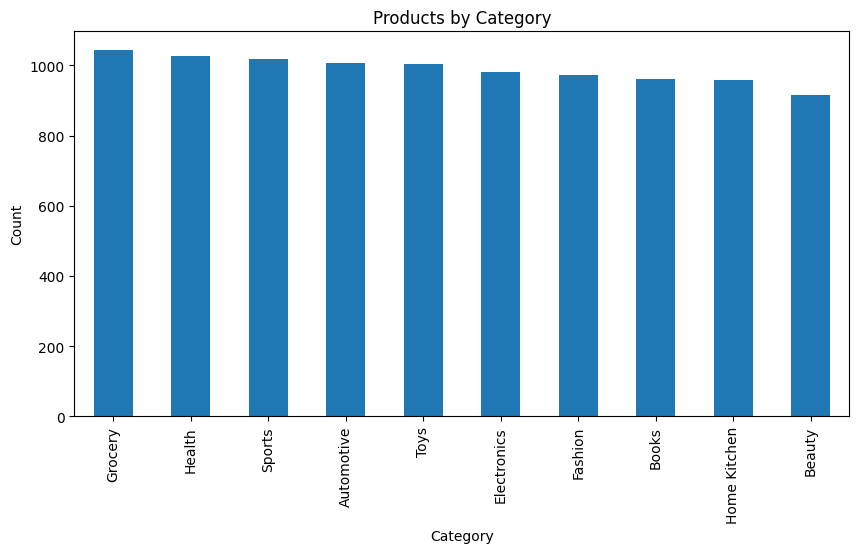

In [1903]:
category_count.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Products by Category')
plt.xlabel('Category')
plt.ylabel('Count')

plt.show()

### Brand Analysis

In [1904]:
top_brands = products['brand'].value_counts().head(10)

top_brands

brand
DABUR            259
VEGA             165
MUSCLEBLAZE      159
HARPERCOLLINS    159
PEARSON          159
WEBBY            154
STEELBIRD        154
FUNSKOOL         153
CIPLA            152
HIMALAYA         151
Name: count, dtype: int64

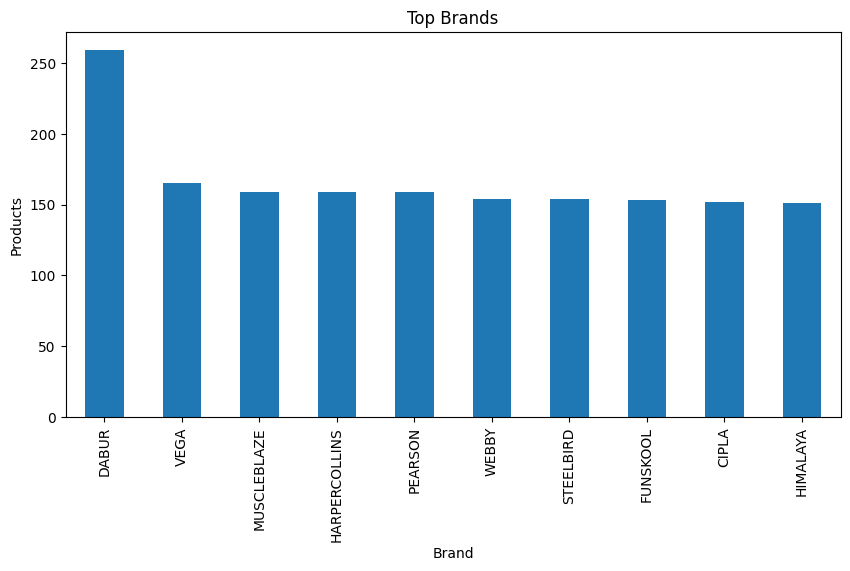

In [1905]:
top_brands.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Brands')
plt.xlabel('Brand')
plt.ylabel('Products')

plt.show()

### Pricing Distribution

In [1906]:
products['base_price'].describe()

count    9.889000e+03
mean     4.970252e+04
std      3.408991e+05
min      1.002800e+02
25%      8.685200e+02
50%      4.331200e+03
75%      2.048122e+04
max      8.944006e+06
Name: base_price, dtype: float64

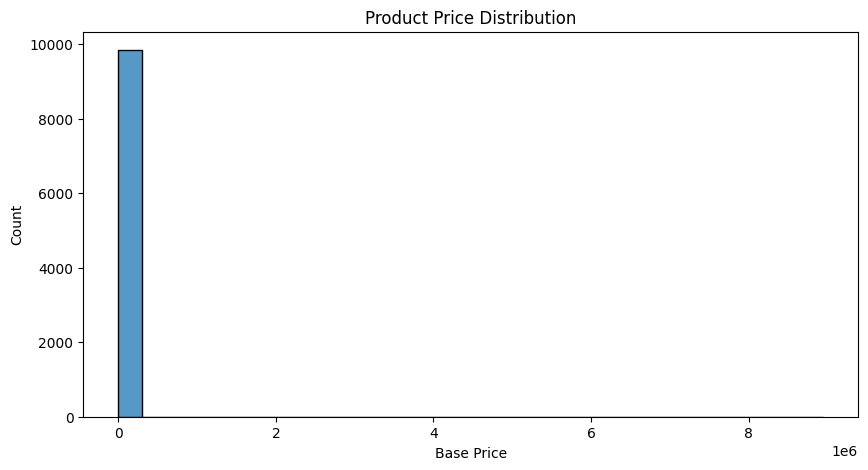

In [1907]:
plt.figure(figsize=(10,5))

sns.histplot(
    products['base_price'],
    bins=30
)

plt.title('Product Price Distribution')
plt.xlabel('Base Price')
plt.ylabel('Count')

plt.show()

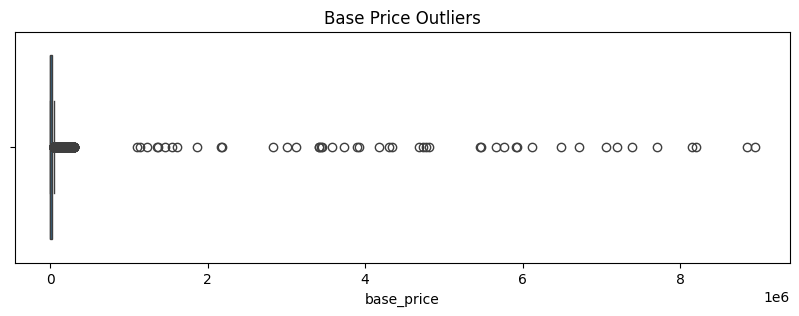

In [1908]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=products['base_price']
)

plt.title('Base Price Outliers')

plt.show()

### Product Ratings Analysis

In [1909]:
products['product_rating'].describe()

count    9889.000000
mean        3.755848
std         0.727700
min         2.500000
25%         3.130000
50%         3.760000
75%         4.380000
max         5.000000
Name: product_rating, dtype: float64

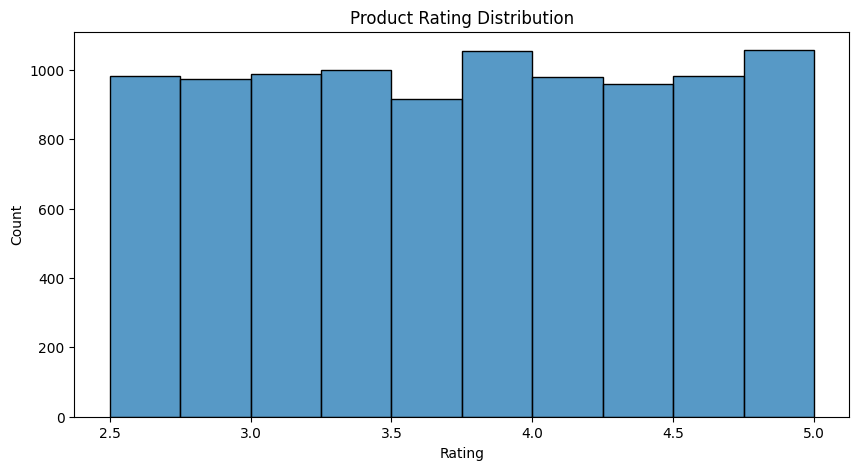

In [1910]:
plt.figure(figsize=(10,5))

sns.histplot(
    products['product_rating'],
    bins=10
)

plt.title('Product Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.show()

### Top Categories

In [1911]:
top_categories = products.groupby(
    'category'
)['product_id'].count().sort_values(ascending=False)

top_categories

category
Grocery         1044
Health          1026
Sports          1019
Automotive      1006
Toys            1004
Electronics      982
Fashion          973
Books            962
Home Kitchen     959
Beauty           914
Name: product_id, dtype: int64

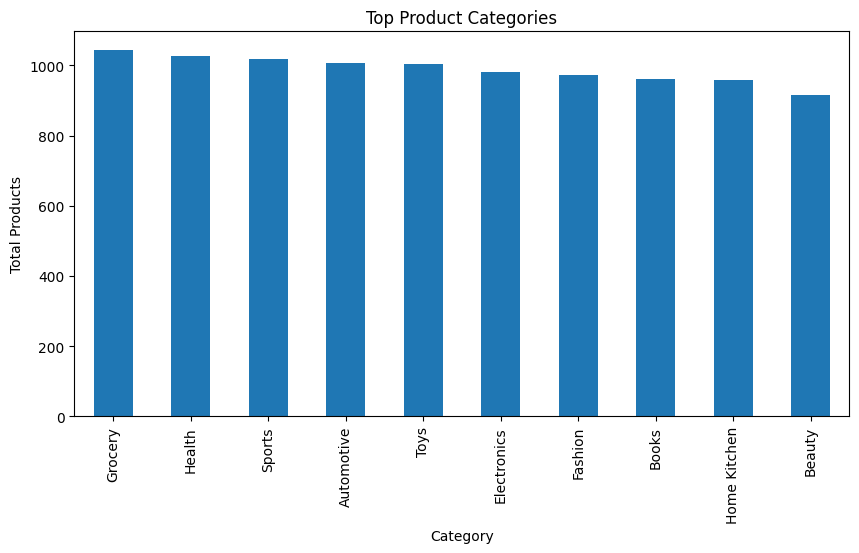

In [1912]:
top_categories.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Product Categories')
plt.xlabel('Category')
plt.ylabel('Total Products')

plt.show()

### High-Priced Products

In [1913]:
high_priced_products = products.nlargest(
    10,
    'base_price'
)[
    ['product_name','category','brand','base_price']
]

high_priced_products

,product_name,category,brand,base_price
8770,Bosch Bike Plus 4,Automotive,BOSCH,8944005.84
3745,Patanjali Snacks Neo 3,Grocery,PATANJALI,8852792.71
9070,Ok Play Puzzles Neo 1,Toys,OK PLAY,8197726.00
8227,Fastrack Women Mini 3,Fashion,FASTRACK,8143894.02
861,Muscleblaze Ayurveda Elite 1,Health,MUSCLEBLAZE,7710462.08
4406,Gillette Haircare Plus 3,Beauty,GILLETTE,7391654.77
4330,Shell Bike Lite 9,Automotive,SHELL,7201418.80
7030,Yonex Yoga Pro 5,Sports,YONEX,7059638.08
3476,Penguin Academic Edge 4,Books,PENGUIN,6714196.13
9,Dabur Supplements Neo 4,Health,DABUR,6487856.02


## Orders

In [1914]:
orders=pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/orders.csv")
orders.head()

,order_id,customer_id,order_datetime,order_status,order_amount,payment_method,coupon_used,delivery_city,expected_delivery_date,actual_delivery_date
0,9000001,108061,31-03-2024 19:24,Cancelled,72531.29,NetBanking,No,Jaipur,05-04-2024,NaN
1,9000002,137163,28-11-2023 20:54,Delivered,598.24,Card,No,Jaipur,01-12-2023,03-12-2023
2,9000003,111418,11-09-2024 17:38,CANCELLED,3625.41,UPI,No,Bangalore,13-09-2024,NaN
3,9000004,106360,27-11-2024 12:48,Delivered,11113.80,Wallet,No,Gurugram,02-12-2024,03-12-2024
4,9000005,107971,21-12-2023 14:22,Cancelled,1820.50,Wallet,Yes,Jaipur,26-12-2023,NaN


In [1915]:
orders.shape

(250000, 10)

In [1916]:
#Find Invalid Customer References
invalid_customers = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
]

print("Invalid customer references:",
      invalid_customers.shape[0])
# Remove Invalid Rows
orders = orders[
    orders["customer_id"].isin(customers["customer_id"])
]

Invalid customer references: 1277


In [1917]:
# check duplicates in order_id column
orders['order_id'].duplicated().sum()

np.int64(1797)

In [1918]:
# drop duplicates in order_id
orders = orders.drop_duplicates(subset='order_id')
orders['order_id'].duplicated().sum()

np.int64(0)

In [1919]:
# check null values
orders.isnull().sum()

order_id                      0
customer_id                   0
order_datetime                0
order_status                  0
order_amount                  0
payment_method                0
coupon_used                5011
delivery_city                 0
expected_delivery_date        0
actual_delivery_date      81659
dtype: int64

In [1920]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246926 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                246926 non-null  int64  
 1   customer_id             246926 non-null  int64  
 2   order_datetime          246926 non-null  object 
 3   order_status            246926 non-null  object 
 4   order_amount            246926 non-null  float64
 5   payment_method          246926 non-null  object 
 6   coupon_used             241915 non-null  object 
 7   delivery_city           246926 non-null  object 
 8   expected_delivery_date  246926 non-null  object 
 9   actual_delivery_date    165267 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 20.7+ MB


In [1921]:
# check categorical columns labels
print("order status labels:",orders['order_status'].value_counts())
print("payment method labels:",orders['payment_method'].value_counts())
print("coupons labels:",orders['coupon_used'].value_counts())
print("delivery city labels:",orders['delivery_city'].value_counts())

order status labels: order_status
Delivered     130696
Cancelled      32259
Returned       24637
Processing     19836
Shipped        12392
Pending        12281
delivered       7420
CANCELLED       4891
returned        2514
Name: count, dtype: int64
payment method labels: payment_method
UPI           84019
Card          49499
COD           48994
Wallet        24671
NetBanking    19739
EMI           12640
CARD           2490
upi            2443
Bitcoin        2431
Name: count, dtype: int64
coupons labels: coupon_used
No     172692
Yes     69223
Name: count, dtype: int64
delivery city labels: delivery_city
Ahmedabad             16340
Hyderabad             16300
Jaipur                16287
Indore                16273
Noida                 16249
Lucknow               16214
Thiruvananthapuram    16150
Delhi                 16143
Gurugram              16137
Kolkata               16081
Bangalore             16050
Mumbai                15992
Visakhapatnam         15970
Chennai               159

In [1922]:
# standardize the categorical columns
orders["order_status"] = orders["order_status"].str.strip().str.title()
orders["payment_method"] = orders["payment_method"].str.strip().str.title()
orders["delivery_city"] = orders["delivery_city"].str.strip().str.title()

In [1923]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246926 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                246926 non-null  int64  
 1   customer_id             246926 non-null  int64  
 2   order_datetime          246926 non-null  object 
 3   order_status            246926 non-null  object 
 4   order_amount            246926 non-null  float64
 5   payment_method          246926 non-null  object 
 6   coupon_used             241915 non-null  object 
 7   delivery_city           246926 non-null  object 
 8   expected_delivery_date  246926 non-null  object 
 9   actual_delivery_date    165267 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 20.7+ MB


In [1924]:
# fill coupon_used missing values with the mode

print("the most common coupon value:",orders['coupon_used'].mode()[0])

orders['coupon_used'] = orders[
    'coupon_used'
].fillna(
    orders['coupon_used'].mode()[0]
)
# check
orders['coupon_used'].isnull().sum()

the most common coupon value: No


np.int64(0)

### Date columns

In [1925]:
#converting data types of date columns from object to datetime
orders['order_datetime']=pd.to_datetime(orders['order_datetime'])

orders['expected_delivery_date'] = pd.to_datetime(orders['expected_delivery_date'],errors='coerce',  dayfirst=True)

orders['actual_delivery_date'] = pd.to_datetime(orders['actual_delivery_date'],errors='coerce',  dayfirst=True)

orders.info()

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\4141834648.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders['order_datetime']=pd.to_datetime(orders['order_datetime'])


<class 'pandas.core.frame.DataFrame'>
Index: 246926 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                246926 non-null  int64         
 1   customer_id             246926 non-null  int64         
 2   order_datetime          246926 non-null  datetime64[ns]
 3   order_status            246926 non-null  object        
 4   order_amount            246926 non-null  float64       
 5   payment_method          246926 non-null  object        
 6   coupon_used             246926 non-null  object        
 7   delivery_city           246926 non-null  object        
 8   expected_delivery_date  246926 non-null  datetime64[ns]
 9   actual_delivery_date    165267 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(2), object(4)
memory usage: 20.7+ MB


In [1926]:
# check future dates
(orders['order_datetime'] > pd.Timestamp.today()).sum()

np.int64(0)

In [1927]:
(orders['actual_delivery_date'] > pd.Timestamp.today()).sum()

np.int64(297)

In [1928]:
#Check where expected_delivery < order date
invalid_delivery = orders[
    orders["expected_delivery_date"] < orders["order_datetime"]
]
print("Invalid rows (delivery before order):", len(invalid_delivery))

Invalid rows (delivery before order): 1761


In [1929]:
# the dates are invalid because delivery cannot happen before the order.
# You can swap the two columns for those invalid rows.
mask = orders['expected_delivery_date'] < orders['order_datetime']

orders.loc[mask, ['order_datetime', 'expected_delivery_date']] = (
    orders.loc[mask, ['expected_delivery_date', 'order_datetime']].values
)
# verify columns 
(
    orders['expected_delivery_date'] < orders['order_datetime']
).sum()

np.int64(0)

In [1930]:
orders.isna().sum()

order_id                      0
customer_id                   0
order_datetime                0
order_status                  0
order_amount                  0
payment_method                0
coupon_used                   0
delivery_city                 0
expected_delivery_date        0
actual_delivery_date      81659
dtype: int64

In [1931]:
# check relation with orders
orders.groupby('order_status')[
    'actual_delivery_date'
].apply(lambda x: x.isnull().sum())

order_status
Cancelled     37150
Delivered         0
Pending       12281
Processing    19836
Returned          0
Shipped       12392
Name: actual_delivery_date, dtype: int64

In [1932]:
# create a flag
orders['delivery_completed_flag'] = (
    orders['actual_delivery_date'].notna()
).astype(int)


In [1933]:
orders

,order_id,customer_id,order_datetime,order_status,order_amount,payment_method,coupon_used,delivery_city,expected_delivery_date,actual_delivery_date,delivery_completed_flag
0,9000001,108061,2024-03-31 19:24:00,Cancelled,72531.29,Netbanking,No,Jaipur,2024-04-05,NaT,0
1,9000002,137163,2023-11-28 20:54:00,Delivered,598.24,Card,No,Jaipur,2023-12-01,2023-12-03,1
2,9000003,111418,2024-09-11 17:38:00,Cancelled,3625.41,Upi,No,Bangalore,2024-09-13,NaT,0
3,9000004,106360,2024-11-27 12:48:00,Delivered,11113.80,Wallet,No,Gurugram,2024-12-02,2024-12-03,1
4,9000005,107971,2023-12-21 14:22:00,Cancelled,1820.50,Wallet,Yes,Jaipur,2023-12-26,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...
249995,9249996,105848,2024-11-02 21:38:00,Returned,1368.68,Wallet,No,Kolkata,2024-11-07,2024-11-09,1
249996,9249997,105182,2023-10-29 12:49:00,Delivered,4564.23,Cod,No,Chennai,2023-11-02,2023-11-02,1
249997,9249998,104994,2024-12-31 21:09:00,Delivered,102427.48,Card,No,Indore,2025-01-06,2025-01-06,1
249998,9249999,102822,2023-08-06 08:54:00,Cancelled,11984.61,Upi,No,Noida,2023-08-09,NaT,0


In [1934]:
orders.to_csv('orders_clean.csv', index=False)

## orders EDA

In [1935]:
orders['order_date'] = orders[
    'order_datetime'
].dt.date

orders['order_month'] = orders[
    'order_datetime'
].dt.month_name()

orders['order_year_month'] = orders[
    'order_datetime'
].dt.to_period('M')

orders['weekday'] = orders[
    'order_datetime'
].dt.day_name()

orders['is_weekend'] = orders[
    'weekday'
].isin(['Saturday','Sunday'])

### Total Orders

In [1936]:
total_orders = orders['order_id'].nunique()

print("Total Orders :", total_orders)

Total Orders : 246926


### Gross Revenue

In [1937]:
gross_revenue = orders['order_amount'].sum()

print("Gross Revenue :", gross_revenue)

Gross Revenue : 9905306733.150002


### Average Order Value (AOV)  
Formula:  

AOV=Total Orders/ Total Revenue


In [1938]:
average_order_value = orders['order_amount'].mean()

print("Average Order Value :", average_order_value)

Average Order Value : 40114.47451118959


### Order Status Distribution

In [1939]:
orders['order_status'].value_counts()

order_status
Delivered     138116
Cancelled      37150
Returned       27151
Processing     19836
Shipped        12392
Pending        12281
Name: count, dtype: int64

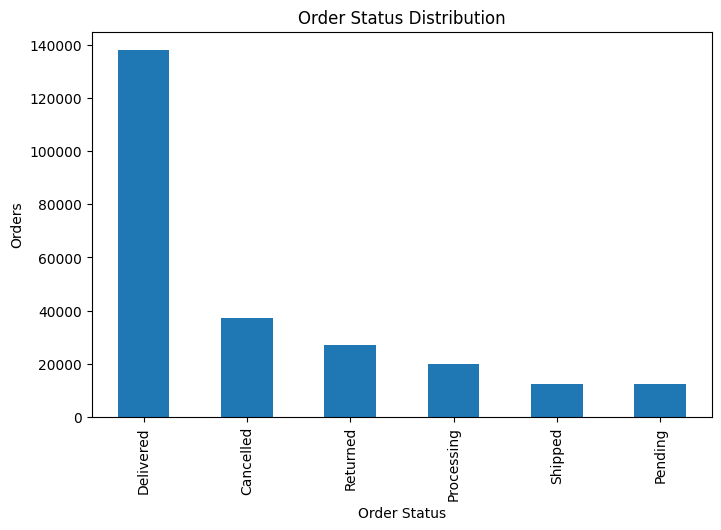

In [1940]:
orders['order_status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Orders')

plt.show()

### Daily Order Trend

In [1941]:
daily_orders = orders.groupby(
    'order_date'
)['order_amount'].sum()

daily_orders.head()

order_date
2021-12-27     99966.97
2021-12-28      5689.55
2021-12-29      3991.53
2021-12-30    290586.06
2021-12-31      4178.68
Name: order_amount, dtype: float64

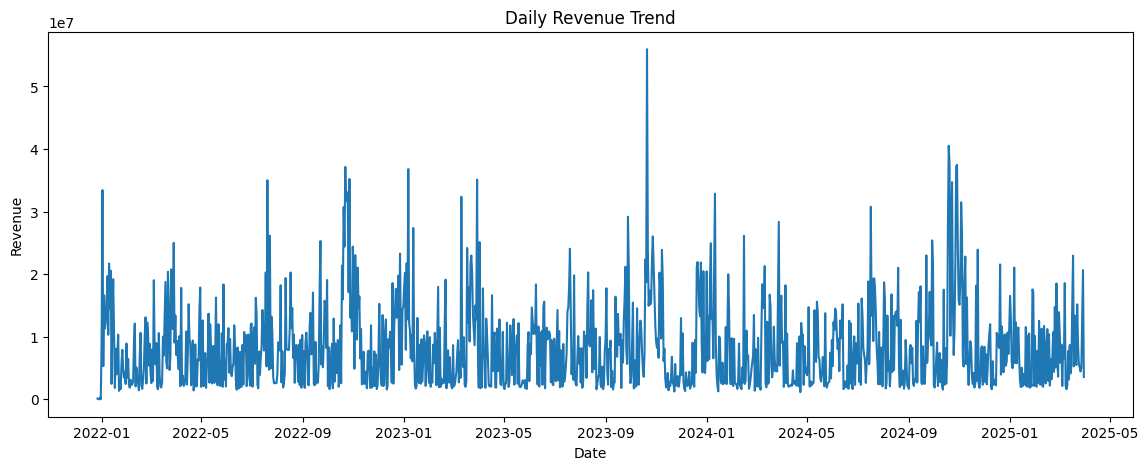

In [1942]:
plt.figure(figsize=(14,5))

daily_orders.plot()

plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.show()

### Monthly Order Trend

In [1943]:
monthly_orders = orders.groupby(
    'order_year_month'
)['order_amount'].sum()

monthly_orders.head()

order_year_month
2021-12    4.044128e+05
2022-01    3.101432e+08
2022-02    1.529327e+08
2022-03    2.837653e+08
2022-04    2.035568e+08
Freq: M, Name: order_amount, dtype: float64

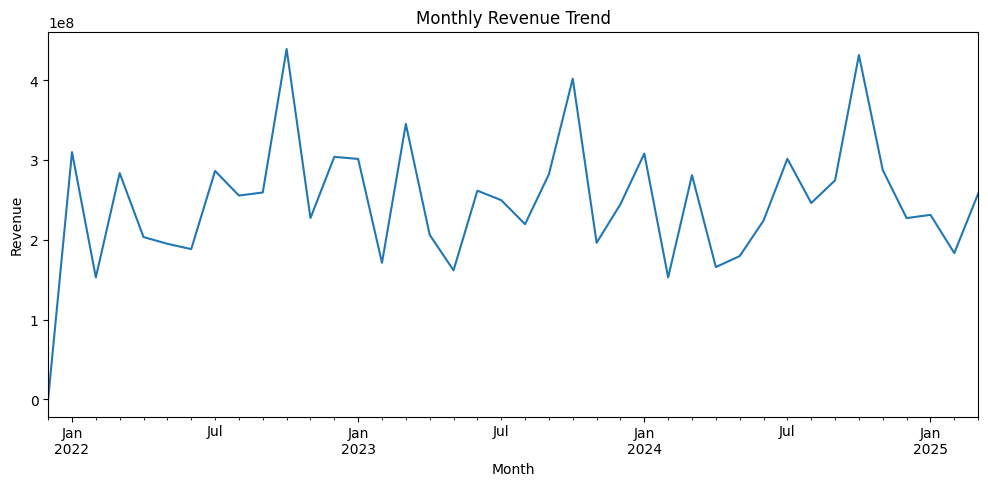

In [1944]:
plt.figure(figsize=(12,5))

monthly_orders.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

### Peak Sales Months

In [1945]:
peak_sales_months = orders.groupby(
    'order_month'
)['order_amount'].sum().sort_values(ascending=False)

peak_sales_months

order_month
October      1.273628e+09
March        1.168364e+09
January      1.151413e+09
July         8.380767e+08
September    8.165530e+08
December     7.767496e+08
August       7.216355e+08
November     7.113989e+08
June         6.743563e+08
February     6.606466e+08
April        5.758522e+08
May          5.366336e+08
Name: order_amount, dtype: float64

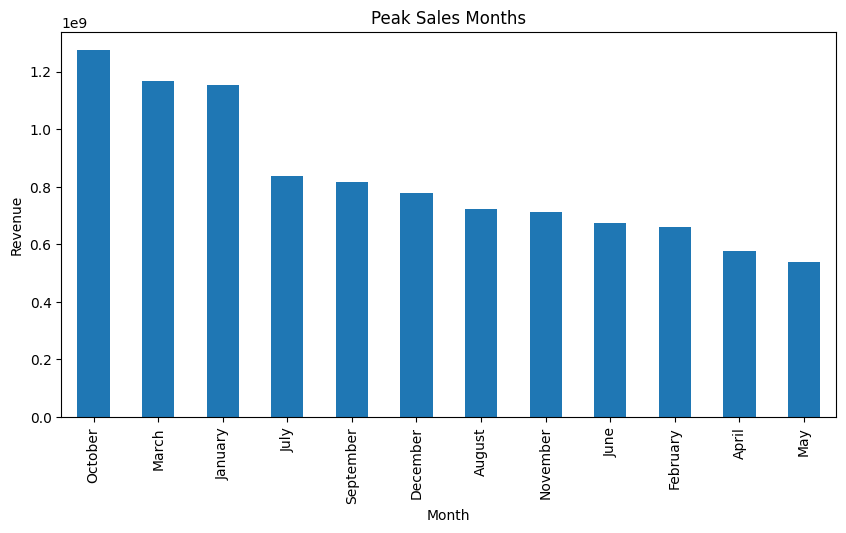

In [1946]:
peak_sales_months.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Peak Sales Months')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

### Weekend vs Weekday Sales

In [1947]:
weekend_sales = orders.groupby(
    'is_weekend'
)['order_amount'].sum()

weekend_sales

is_weekend
False    6.993481e+09
True     2.911826e+09
Name: order_amount, dtype: float64

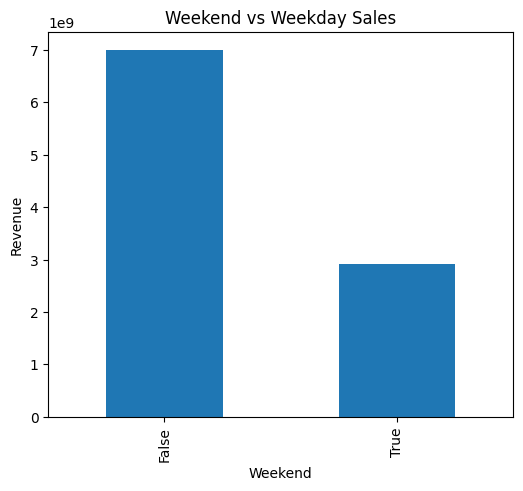

In [1948]:
weekend_sales.plot(
    kind='bar',
    figsize=(6,5)
)

plt.title('Weekend vs Weekday Sales')
plt.xlabel('Weekend')
plt.ylabel('Revenue')

plt.show()

### Seasonal Trends  
Quarterly Sales

In [1949]:
orders['quarter'] = orders[
    'order_datetime'
].dt.quarter

quarterly_sales = orders.groupby(
    'quarter'
)['order_amount'].sum()

quarterly_sales

quarter
1    2.980423e+09
2    1.786842e+09
3    2.376265e+09
4    2.761776e+09
Name: order_amount, dtype: float64

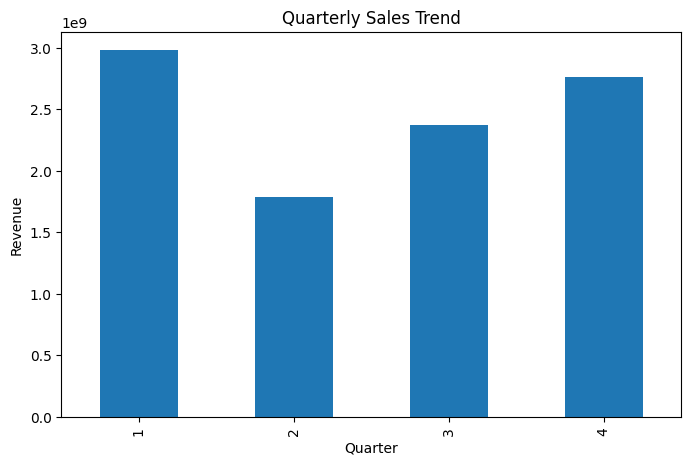

In [1950]:
quarterly_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

plt.show()

### Payment Method Analysis

In [1951]:
payment_analysis = orders.groupby(
    'payment_method'
)['order_amount'].sum().sort_values(ascending=False)

payment_analysis

payment_method
Upi           3.425520e+09
Card          2.168415e+09
Cod           1.940195e+09
Wallet        9.054442e+08
Netbanking    8.592370e+08
Emi           5.076439e+08
Bitcoin       9.885214e+07
Name: order_amount, dtype: float64

In [1952]:
orders['delivery_completed_flag'].value_counts()

delivery_completed_flag
1    165267
0     81659
Name: count, dtype: int64

### Top Delivery Cities by Revenue

In [1953]:
top_cities = orders.groupby(
    'delivery_city'
)['order_amount'].sum().sort_values(ascending=False)

top_cities.head(10)

delivery_city
Kolkata               7.503198e+08
Ahmedabad             7.222312e+08
Lucknow               7.162188e+08
Hyderabad             6.775968e+08
Delhi                 6.764752e+08
Thiruvananthapuram    6.688903e+08
Visakhapatnam         6.607016e+08
Noida                 6.594829e+08
Indore                6.579084e+08
Chennai               6.563906e+08
Name: order_amount, dtype: float64

Revenue Insight  

Total revenue shows strong sales concentration during festive and seasonal periods.  

Order Trend Insight  

Monthly order trends indicate increasing customer demand over time.  

Weekend Insight  

Weekend sales outperform weekday sales, indicating higher customer shopping activity during holidays and leisure periods.  

Payment Insight  

Digital payment methods contribute the majority of order revenue, reflecting customer preference for online transactions.  

Delivery Insight  

Major metropolitan cities contribute the highest order revenue due to larger customer bases and higher purchasing frequency.

## Customer_support_tickets

In [1954]:
cst = pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/customer_support_tickets.csv")
cst.head()

,ticket_id,customer_id,order_id,ticket_category,ticket_created_date,resolution_status,resolution_time_hours,customer_sentiment
0,7500001,129434,9057422.0,Technical Support,25-01-2023 22:05,Resolved,42,Neutral
1,7500002,149267,NaN,Wrong Item,12-09-2023 19:38,Escalated,-5,Neutral
2,7500003,116912,9179257.0,Return Request,19-03-2025 22:12,Escalated,158,Positive
3,7500004,132454,9249225.0,Return Request,29-09-2022 05:33,Escalated,116,Neutral
4,7500005,138274,9132525.0,Delivery Issue,29-09-2024 11:30,Open,64,Negative


In [1955]:
cst.shape

(60000, 8)

In [1956]:
cst.duplicated().sum()

np.int64(0)

In [1957]:
# Find Invalid Customer IDs
invalid_customers = cst[
    ~cst["customer_id"].isin(
        customers["customer_id"]
    )
]

print("Invalid customer IDs:",
      invalid_customers.shape[0])
# Remove Invalid Customer References
cst = cst[
    cst["customer_id"].isin(
        customers["customer_id"]
    )
]
# verify 
invalid_customers = cst[
    ~cst["customer_id"].isin(
        customers["customer_id"]
    )
]

print(invalid_customers.shape[0])

Invalid customer IDs: 308
0


In [1958]:
cst.isnull().sum()

ticket_id                   0
customer_id                 0
order_id                 6071
ticket_category          6015
ticket_created_date         0
resolution_status           0
resolution_time_hours       0
customer_sentiment       3564
dtype: int64

In [1959]:
cst.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59692 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              59692 non-null  int64  
 1   customer_id            59692 non-null  int64  
 2   order_id               53621 non-null  float64
 3   ticket_category        53677 non-null  object 
 4   ticket_created_date    59692 non-null  object 
 5   resolution_status      59692 non-null  object 
 6   resolution_time_hours  59692 non-null  int64  
 7   customer_sentiment     56128 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 4.1+ MB


In [1960]:
# convert incosistent data types
cst['order_id'] = cst['order_id'].astype('Int64')

# Convert date column to datetime
cst['ticket_created_date'] = pd.to_datetime(cst['ticket_created_date'],errors='coerce')
cst.info()

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\2990735430.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cst['ticket_created_date'] = pd.to_datetime(cst['ticket_created_date'],errors='coerce')


<class 'pandas.core.frame.DataFrame'>
Index: 59692 entries, 0 to 59999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_id              59692 non-null  int64         
 1   customer_id            59692 non-null  int64         
 2   order_id               53621 non-null  Int64         
 3   ticket_category        53677 non-null  object        
 4   ticket_created_date    59692 non-null  datetime64[ns]
 5   resolution_status      59692 non-null  object        
 6   resolution_time_hours  59692 non-null  int64         
 7   customer_sentiment     56128 non-null  object        
dtypes: Int64(1), datetime64[ns](1), int64(3), object(3)
memory usage: 4.2+ MB


In [1961]:
print("ticket category labels:",cst['ticket_category'].value_counts())
print("resolution status labels:",cst['resolution_status'].value_counts())
print("customer sentiment labels:",cst['customer_sentiment'].value_counts())


ticket category labels: ticket_category
Account Issue        6071
Wrong Item           6065
Refund               6034
Technical Support    6027
Delivery Issue       6021
Return Request       5927
Cancellation         5866
Product Quality      5862
Payment Issue        5804
Name: count, dtype: int64
resolution status labels: resolution_status
Resolved     29816
Open         16745
Escalated     8979
open          1786
RESOLVED      1194
Closed        1172
Name: count, dtype: int64
customer sentiment labels: customer_sentiment
Negative    26133
Neutral     18003
Positive    11992
Name: count, dtype: int64


In [1962]:
# standardize the resolution status column labels
cst['resolution_status']=cst['resolution_status'].str.strip().str.title()
# verify
cst['resolution_status'].value_counts()

resolution_status
Resolved     31010
Open         18531
Escalated     8979
Closed        1172
Name: count, dtype: int64

### order_id

In [1963]:
#Check ticket categories of null order_ids
cst[cst['order_id'].isnull()]['ticket_category'].value_counts()

ticket_category
Account Issue        650
Technical Support    625
Refund               610
Cancellation         607
Delivery Issue       606
Product Quality      606
Return Request       604
Wrong Item           585
Payment Issue        585
Name: count, dtype: int64

In [1964]:
#Create a flag column:hen analyze:Tickets with orders, Tickets without orders

cst['has_order_flag'] = cst['order_id'].notnull().astype(int)

In [1965]:
# fill null values with unknown in tickets category column
cst['ticket_category'] = cst['ticket_category'].fillna('Unknown')
# cross check
cst['ticket_category'].isna().sum()

C:\Users\Shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


np.int64(0)

In [1966]:
# fill unknown values 
cst['customer_sentiment'] = cst['customer_sentiment'].fillna('Unknown')
# check distribution
cst['customer_sentiment'].value_counts(dropna=False)

customer_sentiment
Negative    26133
Neutral     18003
Positive    11992
Unknown      3564
Name: count, dtype: int64

In [1967]:
cst.isna().sum()

ticket_id                   0
customer_id                 0
order_id                 6071
ticket_category             0
ticket_created_date         0
resolution_status           0
resolution_time_hours       0
customer_sentiment          0
has_order_flag              0
dtype: int64

In [1968]:
# check future dates
cst[cst['ticket_created_date'] > pd.Timestamp.today()]
# count the future dates
(cst['ticket_created_date'] > pd.Timestamp.today()).sum()

np.int64(238)

In [1969]:
# to remove those rows because they are likely invalid records
cst = cst[
    cst['ticket_created_date'] <= pd.Timestamp.today()
]
# verify
( cst['ticket_created_date'] > pd.Timestamp.today()).sum()

np.int64(0)

In [1970]:
cst['resolution_time_hours'].describe()

count    59454.000000
mean       330.420712
std       1332.808694
min        -10.000000
25%         13.000000
50%         33.000000
75%         75.000000
max       9995.000000
Name: resolution_time_hours, dtype: float64

In [1971]:
(cst['resolution_time_hours'] < 0).sum()

np.int64(2858)

In [1972]:
# remove negative values
cst = cst[
    cst['resolution_time_hours'] >= 0
]
# detecting outliers
Q1 = cst['resolution_time_hours'].quantile(0.25)
Q3 = cst['resolution_time_hours'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

-90.0
190.0


In [1973]:
# remove extreme outliers
cst = cst[
    cst['resolution_time_hours'] <= upper_bound
]
#check again
cst['resolution_time_hours'].describe()

count    50082.000000
mean        45.561319
std         45.465759
min          1.000000
25%         13.000000
50%         28.000000
75%         62.000000
max        190.000000
Name: resolution_time_hours, dtype: float64

In [1974]:
cst

,ticket_id,customer_id,order_id,ticket_category,ticket_created_date,resolution_status,resolution_time_hours,customer_sentiment,has_order_flag
0,7500001,129434,9057422,Technical Support,2023-01-25 22:05:00,Resolved,42,Neutral,1
2,7500003,116912,9179257,Return Request,2025-03-19 22:12:00,Escalated,158,Positive,1
3,7500004,132454,9249225,Return Request,2022-09-29 05:33:00,Escalated,116,Neutral,1
4,7500005,138274,9132525,Delivery Issue,2024-09-29 11:30:00,Open,64,Negative,1
5,7500006,118515,9184212,Technical Support,2024-12-01 14:58:00,Closed,54,Neutral,1
...,...,...,...,...,...,...,...,...,...
59995,7559996,148539,9141550,Product Quality,2024-01-30 17:49:00,Resolved,8,Neutral,1
59996,7559997,148794,9115951,Product Quality,2024-02-22 08:45:00,Resolved,58,Negative,1
59997,7559998,113405,9110531,Wrong Item,2023-10-29 16:56:00,Closed,1,Neutral,1
59998,7559999,114124,9072539,Delivery Issue,2023-03-18 17:22:00,Escalated,26,Negative,1


In [1975]:
cst.to_csv('customer_support_tickets_clean.csv', index=False)

## customer support tickets EDA

### Ticket Categories Analysis

In [1976]:
ticket_categories = cst['ticket_category'].value_counts()

ticket_categories

ticket_category
Account Issue        5113
Refund               5105
Delivery Issue       5091
Wrong Item           5078
Unknown              5063
Technical Support    5041
Return Request       4950
Product Quality      4911
Cancellation         4879
Payment Issue        4851
Name: count, dtype: int64

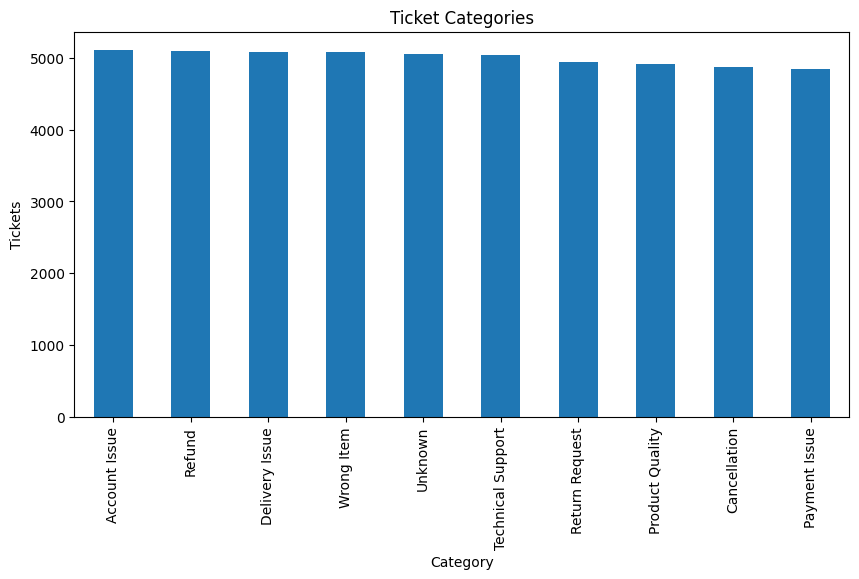

In [1977]:
ticket_categories.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Ticket Categories')
plt.xlabel('Category')
plt.ylabel('Tickets')

plt.show()

### Resolution Status Analysis

In [1978]:
cst['resolution_status'].value_counts()

resolution_status
Resolved     26089
Open         15497
Escalated     7523
Closed         973
Name: count, dtype: int64

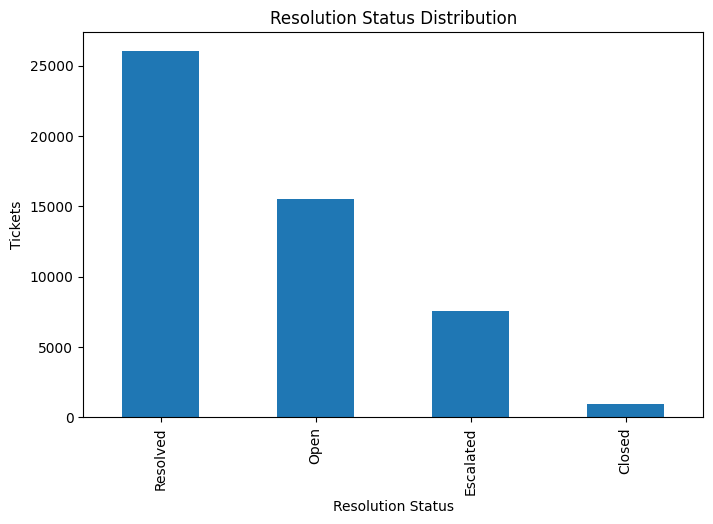

In [1979]:
cst['resolution_status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Resolution Status Distribution')
plt.xlabel('Resolution Status')
plt.ylabel('Tickets')

plt.show()

### Resolution Time Analysis

In [1980]:
cst['resolution_time_hours'].describe()

count    50082.000000
mean        45.561319
std         45.465759
min          1.000000
25%         13.000000
50%         28.000000
75%         62.000000
max        190.000000
Name: resolution_time_hours, dtype: float64

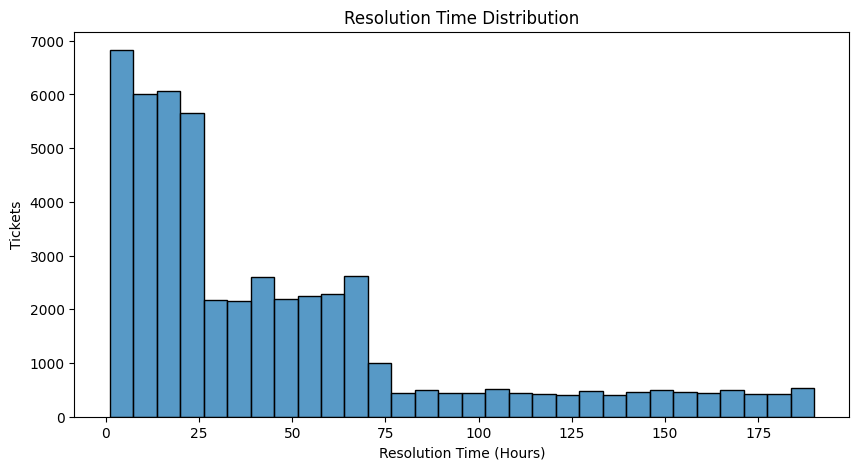

In [1981]:
plt.figure(figsize=(10,5))

sns.histplot(
    cst['resolution_time_hours'],
    bins=30
)

plt.title('Resolution Time Distribution')
plt.xlabel('Resolution Time (Hours)')
plt.ylabel('Tickets')

plt.show()

### Customer Sentiment Analysis

In [1982]:
cst['customer_sentiment'].value_counts()

customer_sentiment
Negative    21919
Neutral     15121
Positive    10033
Unknown      3009
Name: count, dtype: int64

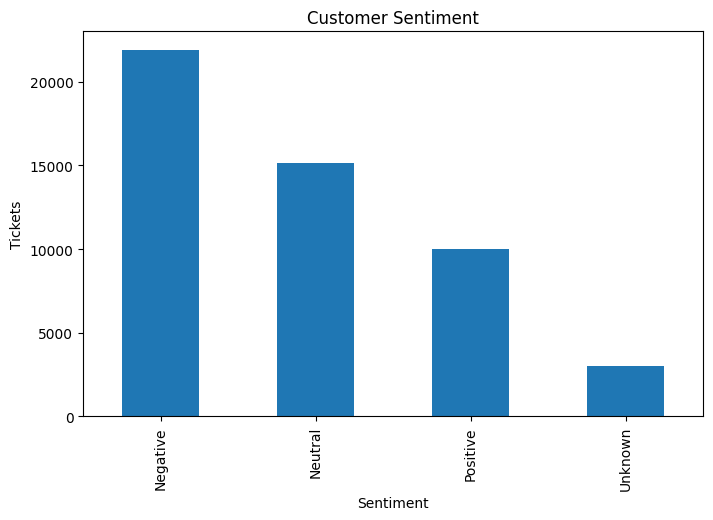

In [1983]:
cst['customer_sentiment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Tickets')

plt.show()

### Which Issues Occur Most?

In [1984]:
most_common_issues = cst.groupby(
    'ticket_category'
)['ticket_id'].count().sort_values(ascending=False)

most_common_issues

ticket_category
Account Issue        5113
Refund               5105
Delivery Issue       5091
Wrong Item           5078
Unknown              5063
Technical Support    5041
Return Request       4950
Product Quality      4911
Cancellation         4879
Payment Issue        4851
Name: ticket_id, dtype: int64

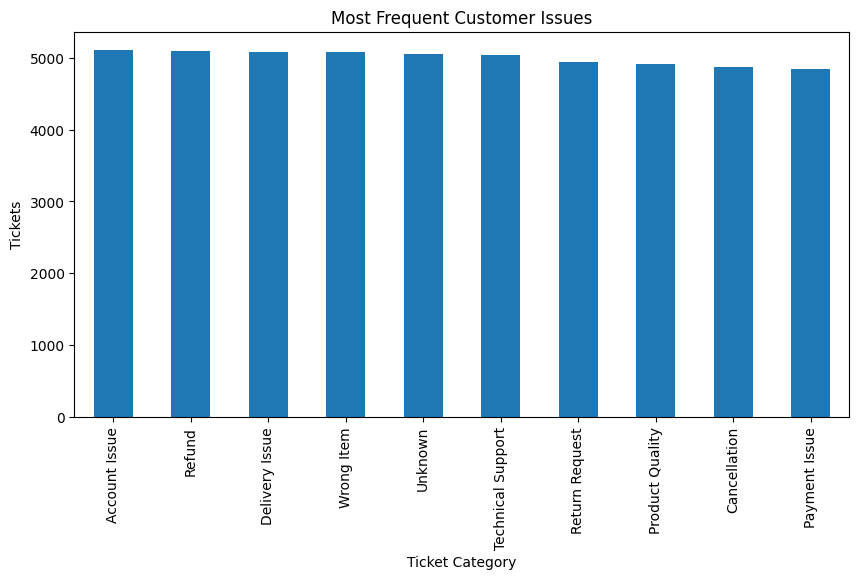

In [1985]:
most_common_issues.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Most Frequent Customer Issues')
plt.xlabel('Ticket Category')
plt.ylabel('Tickets')

plt.show()

### Which Complaints Take Longest?  
Average Resolution Time by Category

In [1986]:
longest_complaints = cst.groupby(
    'ticket_category'
)['resolution_time_hours'].mean().sort_values(ascending=False)

longest_complaints

ticket_category
Technical Support    46.574489
Unknown              46.514912
Account Issue        46.034618
Payment Issue        45.957122
Return Request       45.801616
Delivery Issue       45.346297
Refund               45.323800
Product Quality      45.129098
Cancellation         44.703013
Wrong Item           44.212879
Name: resolution_time_hours, dtype: float64

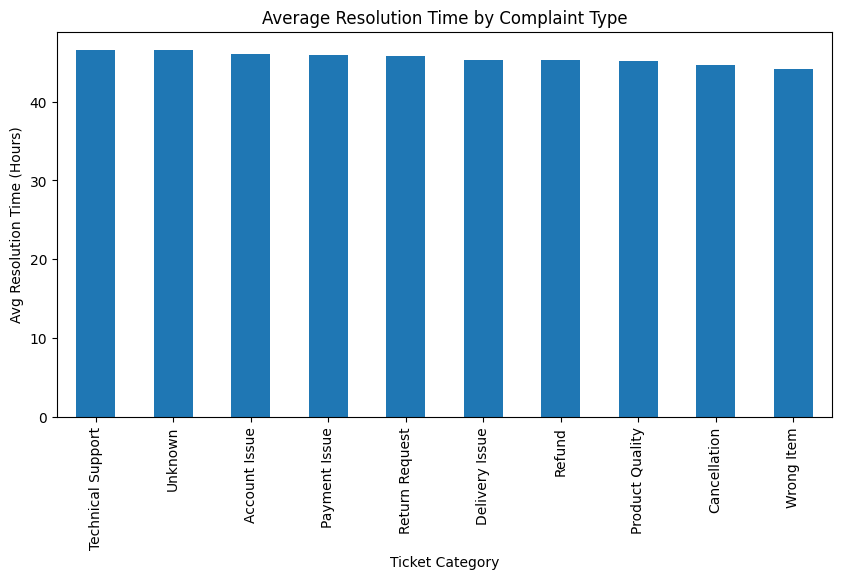

In [1987]:
longest_complaints.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Resolution Time by Complaint Type')
plt.xlabel('Ticket Category')
plt.ylabel('Avg Resolution Time (Hours)')

plt.show()

### Resolution Status vs Sentiment

In [1988]:
pd.crosstab(
    cst['resolution_status'],
    cst['customer_sentiment']
)

customer_sentiment,Negative,Neutral,Positive,Unknown
resolution_status,,,,
Closed,418,298,206,51
Escalated,3312,2259,1486,466
Open,6874,4729,2989,905
Resolved,11315,7835,5352,1587


In [1989]:
# Tickets With vs Without Orders
cst['has_order_flag'].value_counts()

has_order_flag
1    45021
0     5061
Name: count, dtype: int64

### Daily Ticket Trend

In [1990]:
daily_tickets = cst.groupby(
    cst['ticket_created_date'].dt.date
)['ticket_id'].count()

daily_tickets.head()

ticket_created_date
2022-01-01    86
2022-01-02    73
2022-01-03    78
2022-01-04    77
2022-01-05    75
Name: ticket_id, dtype: int64

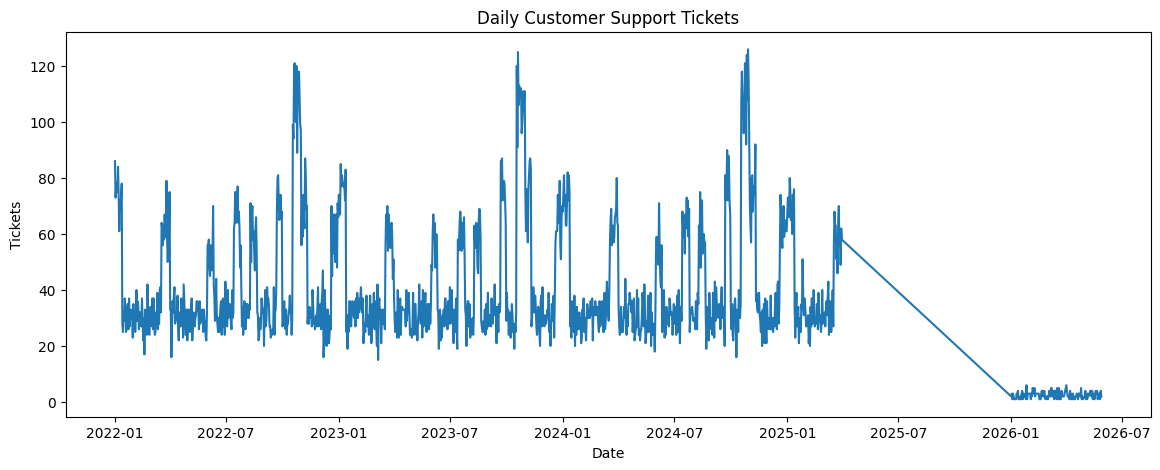

In [1991]:
plt.figure(figsize=(14,5))

daily_tickets.plot()

plt.title('Daily Customer Support Tickets')
plt.xlabel('Date')
plt.ylabel('Tickets')

plt.show()

### Average Resolution Time by Sentiment

In [1992]:
sentiment_resolution = cst.groupby(
    'customer_sentiment'
)['resolution_time_hours'].mean()

sentiment_resolution

customer_sentiment
Negative    45.492084
Neutral     45.567952
Positive    45.795973
Unknown     45.249917
Name: resolution_time_hours, dtype: float64

Complaint Insight

Delivery-related and refund-related issues contribute the highest share of customer support tickets.

Resolution Insight

Technical and refund complaints require the longest resolution times due to dependency on operational and payment processes.

Sentiment Insight

Negative customer sentiment is strongly associated with delayed resolution times.

Operational Insight

Faster ticket resolution significantly improves customer satisfaction and reduces negative feedback.

## order items

In [1993]:
order_items=pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/order_items.csv")
order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_amount,item_total
0,10000001,9034465,50926,0,14013.80,2439.11,11574.69
1,10000002,9209908,52714,1,14055.97,3877.95,10178.02
2,10000003,9138629,54073,1,69882.62,10274.50,59608.12
3,10000004,9101683,58303,1,28196.87,1896.92,26299.95
4,10000005,9208832,50078,3,13023.65,789.09,38281.86


In [1994]:
order_items.shape

(400000, 7)

In [1995]:
# Find Invalid order_id References
invalid_orders = order_items[
    ~order_items["order_id"].isin(orders["order_id"])
]

print("Invalid order references:",
      invalid_orders.shape[0])
# Remove Invalid order_id Rows
order_items = order_items[
    order_items["order_id"].isin(orders["order_id"])
]

Invalid order references: 2033


In [1996]:
# Find Invalid product_id References
invalid_products = order_items[
    ~order_items["product_id"].isin(products["product_id"])
]

print("Invalid product references:",
      invalid_products.shape[0])
# Remove Invalid product_id Rows
order_items = order_items[
    order_items["product_id"].isin(products["product_id"])
]

Invalid product references: 6303


In [1997]:
order_items.isna().sum()

order_item_id      0
order_id           0
product_id         0
quantity           0
unit_price         0
discount_amount    0
item_total         0
dtype: int64

In [1998]:
order_items.dropna(inplace=True)

In [1999]:
order_items.isna().sum()

order_item_id      0
order_id           0
product_id         0
quantity           0
unit_price         0
discount_amount    0
item_total         0
dtype: int64

In [2000]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391664 entries, 0 to 399999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_item_id    391664 non-null  int64  
 1   order_id         391664 non-null  int64  
 2   product_id       391664 non-null  int64  
 3   quantity         391664 non-null  int64  
 4   unit_price       391664 non-null  float64
 5   discount_amount  391664 non-null  float64
 6   item_total       391664 non-null  float64
dtypes: float64(3), int64(4)
memory usage: 23.9 MB


In [2001]:
(order_items['quantity'] <= 0).sum()

np.int64(7664)

In [2002]:
# fill Using Product-wise Median
order_items.loc[
    order_items['quantity'] <= 0,
    'quantity'
] = np.nan

order_items['quantity'] = order_items.groupby(
    'product_id'
)['quantity'].transform(
    lambda x: x.fillna(x.median())
)

(order_items['quantity'] <= 0).sum()

np.int64(0)

In [2003]:
order_items['discount_amount'].describe() 

count    3.916640e+05
mean     1.709138e+04
std      1.757972e+05
min      0.000000e+00
25%      1.122200e+02
50%      5.824750e+02
75%      3.453798e+03
max      1.645383e+07
Name: discount_amount, dtype: float64

In [2004]:
order_items['unit_price'].describe()

count    3.916640e+05
mean     9.525822e+04
std      6.227581e+05
min      8.581000e+01
25%      8.595200e+02
50%      4.322495e+03
75%      2.442832e+04
max      9.956203e+06
Name: unit_price, dtype: float64

In [2005]:
# check for outliers
Q1 = order_items['unit_price'].quantile(0.25)
Q3 = order_items['unit_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("lower bound:",lower_bound)
print("Upper bound:", upper_bound)

unit_price_outliers = order_items[
    (order_items['unit_price'] < lower_bound) |
    (order_items['unit_price'] > upper_bound)
]

print(unit_price_outliers)
print(unit_price_outliers.shape[0])

lower bound: -34493.68
Upper bound: 59781.52
        order_item_id  order_id  product_id  quantity  unit_price  \
6            10000007   9246280       52371       2.0    87921.35   
8            10000009   9229595       51148       2.0   168537.95   
15           10000016   9185872       56877       1.0    60179.89   
21           10000022   9119358       54654       1.0  4783545.39   
23           10000024   9007703       54536       1.0   187420.87   
...               ...       ...         ...       ...         ...   
399967       10399968   9183347       57495       1.0    66527.88   
399969       10399970   9132316       52105       2.0   274401.20   
399972       10399973   9048501       58270       5.0   178211.21   
399985       10399986   9248803       51476       2.0    64550.25   
399998       10399999   9241448       50563       1.0    69264.13   

        discount_amount  item_total  
6              22244.06   153598.64  
8              17179.72   260004.10  
15          

In [2006]:
# fill category-wise capping:
order_items['unit_price'] = order_items.groupby(
    'product_id'
)['unit_price'].transform(
    lambda x: x.clip(
        lower=x.quantile(0.05),
        upper=x.quantile(0.95)
    )
)
order_items['unit_price'].describe()

count    3.916640e+05
mean     5.193546e+04
std      3.505588e+05
min      8.732600e+01
25%      8.547550e+02
50%      4.262250e+03
75%      2.213774e+04
max      9.880307e+06
Name: unit_price, dtype: float64

In [2007]:
#discount cannot exceed the total product price.

invalid_discounts = order_items[
    order_items['discount_amount'] >
    (
        order_items['quantity'] *
        order_items['unit_price']
    )
]

print(invalid_discounts)

invalid_discounts.shape[0]

        order_item_id  order_id  product_id  quantity  unit_price  \
92           10000093   9033589       53939       1.0  38029.8600   
114          10000115   9237070       50593       2.0    604.1635   
124          10000125   9054195       55581       1.0    989.3500   
178          10000179   9107648       51945       1.0  15829.3200   
281          10000282   9157437       54117       1.0  10555.4500   
...               ...       ...         ...       ...         ...   
399863       10399864   9085768       57297       1.0    612.6050   
399895       10399896   9236755       53281       1.0  13668.8100   
399897       10399898   9132728       55128       5.0  15573.8600   
399951       10399952   9135382       54448       4.0   4570.7920   
399960       10399961   9083377       56478       1.0  16545.6400   

        discount_amount   item_total  
92             62744.73    -24714.87  
114           611249.97  11799823.57  
124             1208.29      -218.94  
178            

7507

In [2008]:
# Cap Discount to 50% of Total Price
mask = (
    order_items['discount_amount'] >
    (
        order_items['quantity'] *
        order_items['unit_price']
    )
)

order_items.loc[
    mask,
    'discount_amount'
] = (
    order_items['quantity'] *
    order_items['unit_price'] *
    0.5
)
# verify
(
    order_items['discount_amount'] >
    (
        order_items['quantity'] *
        order_items['unit_price']
    )
).sum()

np.int64(0)

In [2009]:
order_items['quantity'] = pd.to_numeric(order_items['quantity'], errors='coerce')
order_items['unit_price'] = pd.to_numeric(order_items['unit_price'], errors='coerce')
order_items['discount_amount'] = pd.to_numeric(order_items['discount_amount'], errors='coerce')

In [2010]:
#Item Total=(Quantity×Unit Price)−Discount Amount
#if item_total does not match this formula, the row is invalid.
invalid_item_totals = order_items[
    order_items['item_total'] !=
    (
        order_items['quantity'] *
        order_items['unit_price']
    ) - order_items['discount_amount']
]

invalid_item_totals.shape[0]

165089

In [2011]:
# Recalculate Correct Item Total
order_items['item_total'] = (
    (
        order_items['quantity'] *
        order_items['unit_price']
    )
    -
    order_items['discount_amount']
).round(2)
#Prevent negative totals:
order_items['item_total'] = order_items[
    'item_total'
].clip(lower=0)
# verify
(order_items['item_total'].round(2)
    !=
    (
        (
            order_items['quantity'] *
            order_items['unit_price']
        )
        -
        order_items['discount_amount']
    ).round(2)
).sum()

np.int64(0)

In [2012]:
order_items.to_csv('order_items_clean.csv', index=False)

1. Identify best-selling products.
2. Find high-revenue products.
3. Detect pricing outliers.
4. Analyze discount effectiveness.
5. Detect incorrect order calculations.
6. Understand customer buying patterns.
7. Support inventory planning.
8. Identify cross-selling opportunities.

## order items EDA

### TOP-SELLING PRODUCTS

product_id
50989    120.0
56818    119.0
52290    119.0
51000    115.0
56134    115.0
52407    114.0
56329    113.0
51694    112.0
50573    112.0
52017    111.5
Name: quantity, dtype: float64


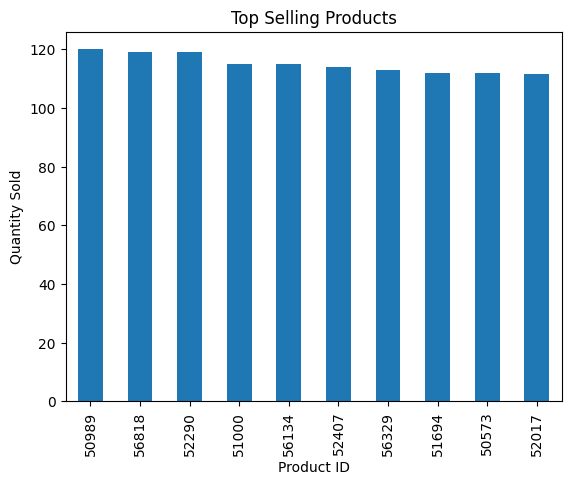

In [2013]:
top_products = (
    order_items.groupby("product_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)
#plot
top_products.plot(kind='bar')

plt.title("Top Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Quantity Sold")

plt.show()

### TOTAL QUANTITY SOLD


In [2014]:

total_qty = order_items["quantity"].sum()

print("Total Quantity Sold:", total_qty)

Total Quantity Sold: 675418.5


###  TOTAL REVENUE

In [2015]:

total_revenue = order_items["item_total"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 31612215480.170002


### AVERAGE ORDER VALUE

In [2016]:
avg_order_value = (
    order_items.groupby("order_id")["item_total"]
    .sum()
    .mean()
)

print("Average Order Value:", avg_order_value)

Average Order Value: 161128.15176978792


###  REVENUE BY PRODUCT

product_id
53746    7.483710e+08
58771    5.755118e+08
50862    5.601276e+08
59071    5.224210e+08
57031    4.976467e+08
54407    4.514364e+08
54331    4.378728e+08
58513    4.009299e+08
53477    3.998614e+08
55701    3.850789e+08
Name: item_total, dtype: float64


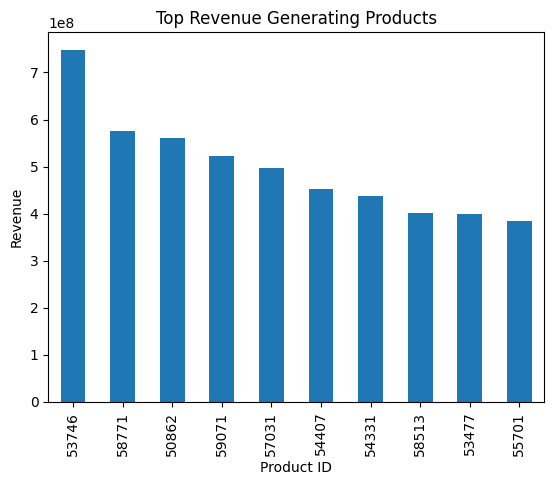

In [2017]:
revenue_by_product = (
    order_items.groupby("product_id")["item_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(revenue_by_product)
# Plot
revenue_by_product.plot(kind='bar')

plt.title("Top Revenue Generating Products")
plt.xlabel("Product ID")
plt.ylabel("Revenue")

plt.show()

###  QUANTITY DISTRIBUTION

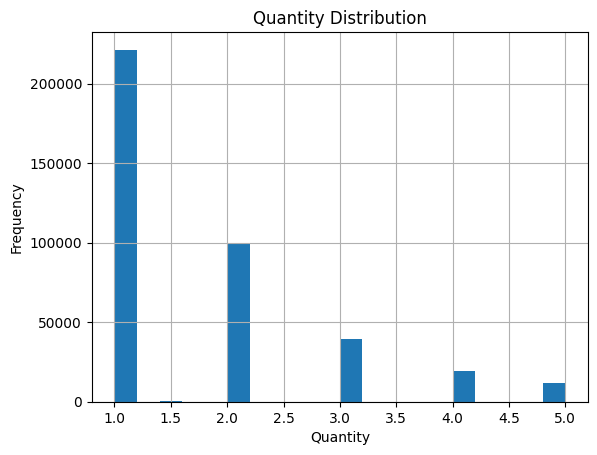

In [2018]:
order_items["quantity"].hist(bins=20)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()


### UNIT PRICE DISTRIBUTION

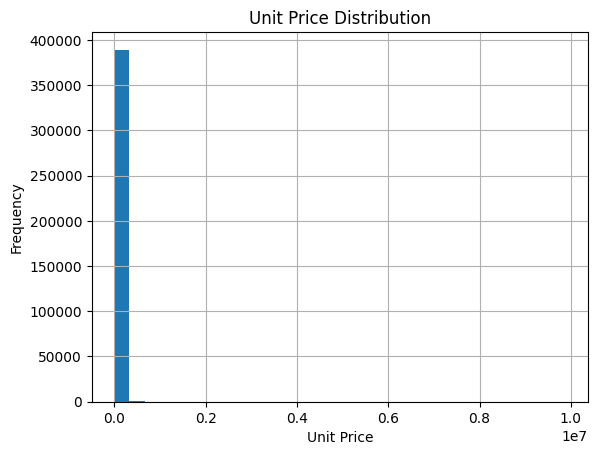

In [2019]:
order_items["unit_price"].hist(bins=30)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

## Returns

In [2020]:
returns = pd.read_csv ("C:/Users/Shiva/Downloads/ecommerce_raw/returns.csv")
returns.head()

,return_id,order_id,customer_id,return_reason,return_request_date,return_status,return_pickup_status,is_suspicious_return
0,8000001,9104490,102865.0,Missing parts,27-06-2024 10:59,Approved,Picked,0.0
1,8000002,9161939,131653.0,Wrong item delivered,24-11-2023 17:34,Approved,Not Picked,NaN
2,8000003,9002298,101747.0,Duplicate order,17-09-2022 01:25,Rejected,Not Picked,0.0
3,8000004,9050756,127483.0,Duplicate order,22-07-2024 00:15,Pending,Picked,1.0
4,8000005,9089900,132093.0,Quality issue,18-06-2022 00:54,Pending,Picked,0.0


In [2021]:
returns.shape

(45000, 8)

In [2022]:
returns.isnull().sum()

return_id                  0
order_id                   0
customer_id             1416
return_reason           1455
return_request_date        0
return_status              0
return_pickup_status    2227
is_suspicious_return     495
dtype: int64

In [2023]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   return_id             45000 non-null  int64  
 1   order_id              45000 non-null  int64  
 2   customer_id           43584 non-null  float64
 3   return_reason         43545 non-null  object 
 4   return_request_date   45000 non-null  object 
 5   return_status         45000 non-null  object 
 6   return_pickup_status  42773 non-null  object 
 7   is_suspicious_return  44505 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 2.7+ MB


In [2024]:
returns['customer_id']=pd.to_numeric(returns['customer_id'],errors='coerce')
returns["return_request_date"] = pd.to_datetime(returns["return_request_date"],errors="coerce")

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\658234630.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  returns["return_request_date"] = pd.to_datetime(returns["return_request_date"],errors="coerce")


In [2025]:
# REMOVE DUPLICATE RETURN REQUESTS
duplicate_returns = returns["return_id"].duplicated().sum()

print("Duplicate Return IDs:", duplicate_returns)

returns = returns.drop_duplicates(subset="return_id")

Duplicate Return IDs: 302


In [2026]:
#CHECK INVALID ORDER REFERENCES
# order_id should exist in orders table
invalid_orders = returns[
    ~returns["order_id"].isin(orders["order_id"])
]

print("Invalid Order References:",
      invalid_orders.shape[0])

# Optional remove
returns = returns[
    returns["order_id"].isin(orders["order_id"])
]


Invalid Order References: 427


In [2027]:
# HANDLE MISSING CUSTOMER IDs
print("Missing Customer IDs:",
      returns["customer_id"].isnull().sum())

# Remove rows with missing customer IDs
returns = returns.dropna(subset=["customer_id"])

Missing Customer IDs: 1392


In [2028]:
# Convert to lowercase and remove spaces
returns["return_reason"] = (
    returns["return_reason"]
    .str.strip()
    .str.lower()
)

# Replace inconsistent labels
returns["return_reason"] = returns["return_reason"].replace({
    "wrong size ": "wrong size",
    "damaged item": "damaged",
    "not as described ": "not as described"
})

# Fill missing values
mode_reason = returns["return_reason"].mode()[0]

returns["return_reason"] = (
    returns["return_reason"]
    .fillna(mode_reason)
)

In [2029]:
#CHECK RETURN DATE BEFORE DELIVERY DATE
# Merge with orders table
returns_orders = returns.merge(
    orders[["order_id", "actual_delivery_date"]],
    on="order_id",
    how="left"
)

invalid_dates = returns_orders[
    returns_orders["return_request_date"] <
    returns_orders["actual_delivery_date"]
]

print("Invalid Return Dates:",
      invalid_dates.shape[0])


Invalid Return Dates: 485


In [2030]:
# CLEAN RETURN STATUS
returns["return_status"] = (
    returns["return_status"]
    .str.strip()
    .str.title()
)

print(returns["return_status"].value_counts())

return_status
Approved    23589
Rejected    11177
Pending      8113
Name: count, dtype: int64


In [2031]:
# CLEAN RETURN PICKUP STATUS
returns["return_pickup_status"] = (
    returns["return_pickup_status"]
    .str.strip()
    .str.title()
)

# Fill missing values with mode
pickup_mode = (
    returns["return_pickup_status"]
    .mode()[0]
)

returns["return_pickup_status"] = (
    returns["return_pickup_status"]
    .fillna(pickup_mode)
)


In [2032]:
#HANDLE SUSPICIOUS RETURN FLAG
print(
    returns["is_suspicious_return"]
    .isnull()
    .sum()
)

# Fill NULL with 0
returns["is_suspicious_return"] = (
    returns["is_suspicious_return"]
    .fillna(0)
)

# Convert datatype
returns["is_suspicious_return"] = (
    returns["is_suspicious_return"]
    .astype(int)
)

473


In [2033]:
print(returns.isnull().sum())

return_id               0
order_id                0
customer_id             0
return_reason           0
return_request_date     0
return_status           0
return_pickup_status    0
is_suspicious_return    0
dtype: int64


In [2034]:
print(returns.info())

<class 'pandas.core.frame.DataFrame'>
Index: 42879 entries, 0 to 44999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   return_id             42879 non-null  int64         
 1   order_id              42879 non-null  int64         
 2   customer_id           42879 non-null  float64       
 3   return_reason         42879 non-null  object        
 4   return_request_date   42879 non-null  datetime64[ns]
 5   return_status         42879 non-null  object        
 6   return_pickup_status  42879 non-null  object        
 7   is_suspicious_return  42879 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 2.9+ MB
None


In [2035]:
returns

,return_id,order_id,customer_id,return_reason,return_request_date,return_status,return_pickup_status,is_suspicious_return
0,8000001,9104490,102865.0,missing parts,2024-06-27 10:59:00,Approved,Picked,0
1,8000002,9161939,131653.0,wrong item delivered,2023-11-24 17:34:00,Approved,Not Picked,0
2,8000003,9002298,101747.0,duplicate order,2022-09-17 01:25:00,Rejected,Not Picked,0
3,8000004,9050756,127483.0,duplicate order,2024-07-22 00:15:00,Pending,Picked,1
4,8000005,9089900,132093.0,quality issue,2022-06-18 00:54:00,Pending,Picked,0
...,...,...,...,...,...,...,...,...
44995,8044996,9106865,114298.0,product not working,2023-07-29 16:48:00,Approved,Picked,0
44996,8044997,9151039,149196.0,changed mind,2024-12-14 04:01:00,Approved,Not Picked,0
44997,8044998,9190580,124852.0,better price elsewhere,2022-03-31 07:43:00,Pending,Not Picked,0
44998,8044999,9184736,107079.0,quality issue,2025-02-09 17:49:00,Pending,Failed,0


In [2036]:
returns.to_csv('returns_clean.csv', index=False)

1. Removed duplicate return requests.
2. Removed invalid order references.
3. Handled missing customer IDs.
4. Standardized return reason labels.
5. Filled missing return reasons using mode.
6. Standardized return status values.
7. Filled missing pickup statuses.
8. Handled suspicious return NULL values.
9. Validated return request dates.

## returns EDA


### Return Count

In [2037]:
return_count = returns['return_id'].nunique()

print("Return Count :", return_count)

Return Count : 42879


### Return Rate

In [2038]:
return_rate = (
    returns['order_id'].nunique()
    /
    orders['order_id'].nunique()
) * 100

print("Return Rate :", round(return_rate,2), "%")

Return Rate : 15.32 %


## Refunds

In [2039]:
refunds = pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/refunds.csv")
refunds.head()

,refund_id,return_id,refund_amount,refund_status,refund_method,refund_processed_date,refund_reason_code
0,8500001,8022000,3682.07,Pending,Original Payment,18-03-2025,CHANGED_MIND
1,8500002,8003316,4723.20,Processed,UPI,13-01-2024,QUALITY_ISSUE
2,8500003,8024548,7419.70,Rejected,Wallet,30-04-2022,NaN
3,8500004,8020163,1055.04,Processed,UPI,23-01-2022,CHANGED_MIND
4,8500005,8022732,1192.03,Processed,Original Payment,23-01-2024,NOT_AS_DESCRIBED


In [2040]:
refunds.shape

(35000, 7)

In [2041]:
print(refunds.info())

print(refunds.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   refund_id              35000 non-null  int64  
 1   return_id              35000 non-null  int64  
 2   refund_amount          35000 non-null  float64
 3   refund_status          35000 non-null  object 
 4   refund_method          35000 non-null  object 
 5   refund_processed_date  35000 non-null  object 
 6   refund_reason_code     31567 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.9+ MB
None
refund_id                   0
return_id                   0
refund_amount               0
refund_status               0
refund_method               0
refund_processed_date       0
refund_reason_code       3433
dtype: int64


In [2042]:
refunds["refund_processed_date"]=pd.to_datetime(refunds["refund_processed_date"],errors='coerce')

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\4010410178.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  refunds["refund_processed_date"]=pd.to_datetime(refunds["refund_processed_date"],errors='coerce')


In [2043]:
#REMOVE DUPLICATE REFUND IDs
duplicate_refunds = refunds["refund_id"].duplicated().sum()

print("Duplicate Refund IDs:", duplicate_refunds)

refunds = refunds.drop_duplicates(subset="refund_id")

Duplicate Refund IDs: 0


In [2044]:
# CHECK INVALID RETURN IDs
# return_id should exist in returns table

invalid_return_ids = refunds[
    ~refunds["return_id"].isin(returns["return_id"])
]

print("Invalid Return IDs:",
      invalid_return_ids.shape[0])

# Optional remove invalid records
refunds = refunds[
    refunds["return_id"].isin(returns["return_id"])
]

Invalid Return IDs: 1556


In [2045]:
#CHECK REFUND AMOUNT > ORDER AMOUNT
# Merge refunds with returns and order_items
refund_check = refunds.merge(
    returns[["return_id", "order_id"]],
    on="return_id",
    how="left"
)

order_totals = (
    order_items.groupby("order_id")["item_total"]
    .sum()
    .reset_index()
)

refund_check = refund_check.merge(
    order_totals,
    on="order_id",
    how="left"
)

invalid_refunds = refund_check[
    refund_check["refund_amount"] >
    refund_check["item_total"]
]

print("Refund Amount Greater Than Order Total:",
      invalid_refunds.shape[0])

Refund Amount Greater Than Order Total: 6241


In [2046]:
#CLEAN REFUND STATUS
refunds["refund_status"] = (
    refunds["refund_status"]
    .str.strip()
    .str.title()
)

print(refunds["refund_status"].value_counts())

refund_status
Processed    21902
Pending       7235
Rejected      4307
Name: count, dtype: int64


In [2047]:
#CLEAN REFUND METHOD
refunds["refund_method"] = (
    refunds["refund_method"]
    .str.strip()
    .str.title()
)

# Allowed methods
valid_methods = [
    "Original Payment",
    "Wallet",
    "Coupon"
]

# Find invalid values
invalid_methods = refunds[
    ~refunds["refund_method"].isin(valid_methods)
]

print("Invalid Refund Methods:",
      invalid_methods.shape[0])

# Replace invalid methods with mode
method_mode = refunds["refund_method"].mode()[0]

refunds.loc[
    ~refunds["refund_method"].isin(valid_methods),
    "refund_method"
] = method_mode


Invalid Refund Methods: 6371


In [2048]:
#CHECK REFUND DATE BEFORE RETURN DATE
refund_dates = refunds.merge(
    returns[["return_id", "return_request_date"]],
    on="return_id",
    how="left"
)

invalid_dates = refund_dates[
    refund_dates["refund_processed_date"] <
    refund_dates["return_request_date"]
]

print("Refund Date Before Return Date:",
      invalid_dates.shape[0])


Refund Date Before Return Date: 584


In [2049]:
# HANDLE MISSING REFUND REASON CODE
print(
    refunds["refund_reason_code"]
    .isnull()
    .sum()
)

# Standardize values
refunds["refund_reason_code"] = (
    refunds["refund_reason_code"]
    .str.strip()
    .str.upper()
)

# Fill missing with mode
reason_mode = (
    refunds["refund_reason_code"]
    .mode()[0]
)

refunds["refund_reason_code"] = (
    refunds["refund_reason_code"]
    .fillna(reason_mode)
)


3268


In [2050]:
print(refunds.isnull().sum())
print(refunds.info())

refund_id                0
return_id                0
refund_amount            0
refund_status            0
refund_method            0
refund_processed_date    0
refund_reason_code       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 33444 entries, 0 to 34999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   refund_id              33444 non-null  int64         
 1   return_id              33444 non-null  int64         
 2   refund_amount          33444 non-null  float64       
 3   refund_status          33444 non-null  object        
 4   refund_method          33444 non-null  object        
 5   refund_processed_date  33444 non-null  datetime64[ns]
 6   refund_reason_code     33444 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 2.0+ MB
None


In [2051]:
refunds.head()

,refund_id,return_id,refund_amount,refund_status,refund_method,refund_processed_date,refund_reason_code
0,8500001,8022000,3682.07,Pending,Original Payment,2025-03-18,CHANGED_MIND
1,8500002,8003316,4723.20,Processed,Original Payment,2024-01-13,QUALITY_ISSUE
2,8500003,8024548,7419.70,Rejected,Wallet,2022-04-30,MISSING_PARTS
3,8500004,8020163,1055.04,Processed,Original Payment,2022-01-23,CHANGED_MIND
4,8500005,8022732,1192.03,Processed,Original Payment,2024-01-23,NOT_AS_DESCRIBED


In [2052]:
refunds.to_csv('refunds_clean.csv', index=False)

1. Removed duplicate refund records.
2. Removed invalid return references.
3. Identified refunds greater than order value.
4. Standardized refund status labels.
5. Cleaned invalid refund methods.
6. Validated refund processing dates.
7. Filled missing refund reason codes.
8. Improved refund transaction consistency.

## Refunds EDA

### Net Revenue

In [2053]:
total_refund_amount = refunds['refund_amount'].sum()

net_revenue = gross_revenue - total_refund_amount

print("Net Revenue :", net_revenue)

Net Revenue : 8969971011.440002


## Payments

In [2054]:
payments=pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/payments.csv")
payments.head(20)

,payment_id,order_id,payment_method,payment_status,payment_amount,payment_datetime,transaction_reference
0,3000001,9046181,UPI,Success,176441.25,08-08-2023 17:28,TXN_PGXFZF0Q64
1,3000002,9032157,UPI,Refunded,8340.27,10-08-2022 14:16,TXN_4TORI6R916
2,3000003,9114603,EMI,Success,7425.37,07-12-2022 18:56,TXN_KVKZGIU1BP
3,3000004,9248198,UPI,Success,1852.17,19-04-2023 05:20,NaN
4,3000005,9194773,Card,Refunded,1319.53,01-06-2022 19:02,TXN_S7ON2LTHTO
5,3000006,9155281,upi,Pending,8769.84,27-09-2022 19:48,TXN_QXOBGY7X9N
6,3000007,9126100,EMI,Success,1256.90,29-12-2024 20:21,TXN_QCM1N3R6DS
7,3000008,9140420,UPI,Success,2169.80,06-05-2022 07:32,TXN_7WYV7XQ84J
8,3000009,9116122,Card,Success,170415.79,01-07-2024 12:50,TXN_05WZ24Y2R2
9,3000010,9246701,UPI,Success,11963.81,01-01-2024 13:56,TXN_3KY1TTCSC3


In [2055]:
payments.shape

(220000, 7)

In [2056]:
print(payments.info())

print(payments.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220000 entries, 0 to 219999
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   payment_id             220000 non-null  int64  
 1   order_id               220000 non-null  int64  
 2   payment_method         220000 non-null  object 
 3   payment_status         220000 non-null  object 
 4   payment_amount         220000 non-null  float64
 5   payment_datetime       220000 non-null  object 
 6   transaction_reference  213468 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 11.7+ MB
None
payment_id                  0
order_id                    0
payment_method              0
payment_status              0
payment_amount              0
payment_datetime            0
transaction_reference    6532
dtype: int64


In [2057]:
payments["payment_datetime"] = pd.to_datetime(
    payments["payment_datetime"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)
print(payments["payment_datetime"].isna().sum())

0


In [2058]:
#REMOVE DUPLICATE PAYMENT IDs

print("Duplicate payment_id:", payments["payment_id"].duplicated().sum())
payments = payments.drop_duplicates(subset="payment_id")

Duplicate payment_id: 1530


In [2059]:
#CHECK INVALID ORDER REFERENCES
# order_id should exist in orders table
invalid_order_ids = payments[~payments["order_id"].isin(orders["order_id"])]
print("Invalid order references:", invalid_order_ids.shape[0])
#remove invalid rows
payments = payments[payments["order_id"].isin(orders["order_id"])]

Invalid order references: 2175


In [2060]:
#CLEAN PAYMENT METHOD
payments["payment_method"] = (
    payments["payment_method"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Standardize values
payments["payment_method"] = payments["payment_method"].replace({
    "UPI": "UPI",
    "CARD": "Card",
    "COD": "COD",
    "NETBANKING": "NetBanking",
    "NET BANKING": "NetBanking"
})

valid_methods = ["UPI", "Card", "COD", "NetBanking"]
invalid_methods = payments[~payments["payment_method"].isin(valid_methods)]
print("Invalid payment methods:", invalid_methods.shape[0])

# Replace invalid values with mode
method_mode = payments["payment_method"].mode()[0]
payments.loc[~payments["payment_method"].isin(valid_methods), "payment_method"] = method_mode



Invalid payment methods: 32393


In [2061]:
payments["payment_method"].value_counts()

payment_method
UPI           108115
Card           47377
COD            43545
NetBanking     17258
Name: count, dtype: int64

In [2062]:
# CLEAN PAYMENT STATUS
payments["payment_status"] = (payments["payment_status"].astype(str).str.strip().str.title())

valid_status = ["Success", "Failed", "Pending", "Refunded"]
invalid_status = payments[~payments["payment_status"].isin(valid_status)]
print("Invalid payment statuses:", invalid_status.shape[0])

# Replace invalid statuses with mode
status_mode = payments["payment_status"].mode()[0]
payments.loc[~payments["payment_status"].isin(valid_status), "payment_status"] = status_mode


Invalid payment statuses: 1128


In [2063]:
# CLEAN PAYMENT AMOUNT
# Negative values are invalid
negative_payments = payments[payments["payment_amount"] < 0]
print("Negative payment amounts:", negative_payments.shape[0])

# Option 1: set negative values to NaN
payments.loc[payments["payment_amount"] < 0, "payment_amount"] = np.nan

# Fill missing payment_amount with median
payments["payment_amount"] = payments["payment_amount"].fillna(payments["payment_amount"].median())


Negative payment amounts: 2185


In [2064]:
#CHECK PAYMENT DATETIME BEFORE ORDER TIME
# Requires orders table with order_datetime column
payments["payment_datetime"] = pd.to_datetime(payments["payment_datetime"], errors="coerce")
orders["order_datetime"] = pd.to_datetime(orders["order_datetime"], errors="coerce")

payment_check = payments.merge(
    orders[["order_id", "order_datetime"]],
    on="order_id",
    how="left"
)

invalid_time_rows = payment_check[
    payment_check["payment_datetime"] < payment_check["order_datetime"]
]
print("Payments before order time:", invalid_time_rows.shape[0])
payment_check.loc[payment_check["payment_datetime"] < payment_check["order_datetime"], "payment_datetime"] = \
    payment_check["order_datetime"] + pd.Timedelta(minutes=5)
invalid_time_rows 

Payments before order time: 3626


,payment_id,order_id,payment_method,payment_status,payment_amount,payment_datetime,transaction_reference,order_datetime
1,3000002,9032157,UPI,Refunded,8340.27,2022-08-10 14:16:00,TXN_4TORI6R916,2022-08-10 22:16:00
81,3000082,9053990,COD,Success,1132.74,2023-11-02 21:42:00,TXN_VW0MSOYQ0Y,2024-09-09 19:33:00
105,3000106,9055534,UPI,Pending,57964.01,2024-08-04 23:25:00,TXN_KYOQ8ISVJG,2024-10-21 15:48:00
195,3000196,9093919,Card,Failed,1571.70,2022-09-07 18:59:00,TXN_C52GUH0Y68,2024-01-22 18:59:00
232,3000233,9029878,COD,Success,2323.50,2022-12-27 17:35:00,TXN_TYO8V0E6CF,2023-08-06 08:17:00
...,...,...,...,...,...,...,...,...
216094,3219797,9080639,UPI,Refunded,477.02,2022-03-24 04:17:00,NaN,2022-03-25 18:17:00
216264,3219970,9249460,UPI,Success,734.52,2023-05-21 05:34:00,TXN_HL5BKT21XM,2023-05-22 21:34:00
216274,3219980,9075341,UPI,Pending,3071.26,2022-11-02 15:39:00,TXN_GMW6J7SJQZ,2022-11-04 11:39:00
216279,3219985,9174646,UPI,Failed,9975.73,2023-09-14 23:09:00,TXN_M7I3RQ7O79,2024-04-07 18:24:00


In [2065]:

print(payments["payment_datetime"].isna().sum())

0


In [2066]:
#HANDLE TRANSACTION REFERENCE MISSING VALUES
print("Missing transaction_reference:", payments["transaction_reference"].isna().sum())

payments["transaction_reference"] = (
    payments["transaction_reference"]
    .astype(str)
    .str.strip()
)

# Replace "nan" string with actual NaN
payments["transaction_reference"] = payments["transaction_reference"].replace("nan", np.nan)

# Fill missing with a generated placeholder
payments["transaction_reference"] = payments["transaction_reference"].fillna(
    "MISSING_TXN_" + payments["payment_id"].astype(str)
)

Missing transaction_reference: 6429


In [2067]:
print(payments.isnull().sum())
print(payments.info())

payment_id               0
order_id                 0
payment_method           0
payment_status           0
payment_amount           0
payment_datetime         0
transaction_reference    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 216295 entries, 0 to 219999
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   payment_id             216295 non-null  int64         
 1   order_id               216295 non-null  int64         
 2   payment_method         216295 non-null  object        
 3   payment_status         216295 non-null  object        
 4   payment_amount         216295 non-null  float64       
 5   payment_datetime       216295 non-null  datetime64[ns]
 6   transaction_reference  216295 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 13.2+ MB
None


In [2068]:
payments.head()

,payment_id,order_id,payment_method,payment_status,payment_amount,payment_datetime,transaction_reference
0,3000001,9046181,UPI,Success,176441.25,2023-08-08 17:28:00,TXN_PGXFZF0Q64
1,3000002,9032157,UPI,Refunded,8340.27,2022-08-10 14:16:00,TXN_4TORI6R916
2,3000003,9114603,UPI,Success,7425.37,2022-12-07 18:56:00,TXN_KVKZGIU1BP
3,3000004,9248198,UPI,Success,1852.17,2023-04-19 05:20:00,MISSING_TXN_3000004
4,3000005,9194773,Card,Refunded,1319.53,2022-06-01 19:02:00,TXN_S7ON2LTHTO


In [2069]:
payments.to_csv('payments_clean.csv', index=False)

## Delivery logs

In [2070]:
delivery_logs = pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/delivary_logs.csv")
delivery_logs.head()

,delivery_id,order_id,warehouse_id,delivery_partner,dispatch_date,delivery_attempts,delivery_status,delay_days
0,6000001,9090295,112.0,Ekart,13-11-2023,1,Failed,1
1,6000002,9066720,110.0,Xpressbees,01-11-2024,1,Returned,0
2,6000003,9109884,103.0,DTDC,28-08-2022,1,Delivered,1
3,6000004,9117033,101.0,Ekart,04-11-2023,1,Returned,3
4,6000005,9025173,147.0,EKART,27-02-2022,1,In Transit,3


In [2071]:
delivery_logs.shape

(180000, 8)

In [2072]:
print(delivery_logs.info())
print(delivery_logs.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   delivery_id        180000 non-null  int64  
 1   order_id           180000 non-null  int64  
 2   warehouse_id       174610 non-null  float64
 3   delivery_partner   180000 non-null  object 
 4   dispatch_date      180000 non-null  object 
 5   delivery_attempts  180000 non-null  int64  
 6   delivery_status    180000 non-null  object 
 7   delay_days         180000 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 11.0+ MB
None
delivery_id             0
order_id                0
warehouse_id         5390
delivery_partner        0
dispatch_date           0
delivery_attempts       0
delivery_status         0
delay_days              0
dtype: int64


In [2073]:
# REMOVE DUPLICATE DELIVERY IDs
print("Duplicate delivery_id:", delivery_logs["delivery_id"].duplicated().sum())
delivery_logs = delivery_logs.drop_duplicates(subset="delivery_id")

Duplicate delivery_id: 1288


In [2074]:
delivery_logs["warehouse_id"] = delivery_logs["warehouse_id"].astype('Int64')

In [2075]:
#CHECK INVALID ORDER REFERENCES
invalid_order_ids = delivery_logs[~delivery_logs["order_id"].isin(orders["order_id"])]
print("Invalid order references:", invalid_order_ids.shape[0])
#remove invalid rows
delivery_logs = delivery_logs[delivery_logs["order_id"].isin(orders["order_id"])]

Invalid order references: 1803


In [2076]:
#HANDLE MISSING WAREHOUSE IDs
print("Missing warehouse_id:", delivery_logs["warehouse_id"].isna().sum())

# Option A: fill with mode
warehouse_mode = delivery_logs["warehouse_id"].mode()[0]
delivery_logs["warehouse_id"] = delivery_logs["warehouse_id"].fillna(warehouse_mode)

Missing warehouse_id: 5295


In [2077]:
# CLEAN DELIVERY PARTNER
delivery_logs["delivery_partner"] = (
    delivery_logs["delivery_partner"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize names
delivery_logs["delivery_partner"] = delivery_logs["delivery_partner"].replace({
    "delhivery": "Delhivery",
    "ekart": "Ekart",
    "bluedart": "BlueDart",
    "blue dart": "BlueDart"
})

# Replace invalid values with mode
partner_mode = delivery_logs["delivery_partner"].mode()[0]
valid_partners = ["Delhivery", "Ekart", "BlueDart"]

delivery_logs.loc[
    ~delivery_logs["delivery_partner"].isin(valid_partners),
    "delivery_partner"
] = partner_mode


In [2078]:
# CONVERT dispatch_date TO DATE
delivery_logs["dispatch_date"] = pd.to_datetime(
    delivery_logs["dispatch_date"],
    errors="coerce"
)


C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\4032166831.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  delivery_logs["dispatch_date"] = pd.to_datetime(


In [2079]:
# CHECK DISPATCH DATE BEFORE ORDER DATE
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

delivery_check = delivery_logs.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

invalid_dates = delivery_check[
    delivery_check["dispatch_date"] < delivery_check["order_date"]
]
print("Dispatch dates before order dates:", invalid_dates.shape[0])

# Optional: correct invalid dispatch dates
mask = delivery_check["dispatch_date"] < delivery_check["order_date"]
delivery_check.loc[mask, "dispatch_date"] = delivery_check.loc[mask, "order_date"]

# Save back
delivery_logs = delivery_check.drop(columns=["order_date"])

Dispatch dates before order dates: 3002


In [2080]:
# CLEAN delivery_attempts
# Remove negative or zero attempts if not valid
invalid_attempts = delivery_logs[delivery_logs["delivery_attempts"] <= 0]
print("Invalid delivery attempts:", invalid_attempts.shape[0])

# Replace outliers like 15 with upper cap using IQR
Q1 = delivery_logs["delivery_attempts"].quantile(0.25)
Q3 = delivery_logs["delivery_attempts"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

delivery_logs["delivery_attempts"] = delivery_logs["delivery_attempts"].clip(lower=1, upper=upper_bound)


Invalid delivery attempts: 0


In [2081]:
# CLEAN delivery_status
delivery_logs["delivery_status"] = (
    delivery_logs["delivery_status"]
    .astype(str)
    .str.strip()
    .str.title()
)

valid_status = ["Delivered", "Failed", "Returned", "Pending", "In Transit"]
status_mode = delivery_logs["delivery_status"].mode()[0]

delivery_logs.loc[
    ~delivery_logs["delivery_status"].isin(valid_status),
    "delivery_status"
] = status_mode

In [2082]:
# CLEAN delay_days
negative_delay = delivery_logs[delivery_logs["delay_days"] < 0]
print("Negative delay days:", negative_delay.shape[0])

# Negative delay days are invalid, set them to 0 or NaN
delivery_logs.loc[delivery_logs["delay_days"] < 0, "delay_days"] = 0

# Optional: fill missing delay_days
delivery_logs["delay_days"] = delivery_logs["delay_days"].fillna(0)

Negative delay days: 3537


In [2083]:
print(delivery_logs.isnull().sum())
delivery_logs.info()

delivery_id          0
order_id             0
warehouse_id         0
delivery_partner     0
dispatch_date        0
delivery_attempts    0
delivery_status      0
delay_days           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176909 entries, 0 to 176908
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   delivery_id        176909 non-null  int64         
 1   order_id           176909 non-null  int64         
 2   warehouse_id       176909 non-null  Int64         
 3   delivery_partner   176909 non-null  object        
 4   dispatch_date      176909 non-null  datetime64[ns]
 5   delivery_attempts  176909 non-null  float64       
 6   delivery_status    176909 non-null  object        
 7   delay_days         176909 non-null  int64         
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 11.0+ MB


In [2084]:
delivery_logs.head()

,delivery_id,order_id,warehouse_id,delivery_partner,dispatch_date,delivery_attempts,delivery_status,delay_days
0,6000001,9090295,112,Ekart,2023-11-13,1.0,Failed,1
1,6000002,9066720,110,Ekart,2024-11-01,1.0,Returned,0
2,6000003,9109884,103,Ekart,2022-08-28,1.0,Delivered,1
3,6000004,9117033,101,Ekart,2023-11-04,1.0,Returned,3
4,6000005,9025173,147,Ekart,2022-02-27,1.0,In Transit,3


In [2085]:
delivery_logs.to_csv('delivery_logs_clean.csv', index=False)

## Warrehouses

In [2086]:
warehouses=pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/warehouses.csv")
warehouses.head()

,warehouse_id,warehouse_name,city,state,region,capacity_units,avg_dispatch_time_hours
0,101,Mumbai Central Warehouse,Mumbai,Maharashtra,West,207473,33.41
1,102,Delhi Distribution Centre,Delhi,Delhi,North,731262,16.77
2,103,Bangalore Distribution Centre,Bangalore,Karnataka,South,106814,15.83
3,104,Hyderabad Fulfillment Center,Hyderabad,Telangana,South,197251,20.62
4,105,Chennai Fulfillment Center,Chennai,Tamil Nadu,South,496922,19.04


In [2087]:
warehouses.shape

(50, 7)

In [2088]:
print(warehouses.info())
print(warehouses.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   warehouse_id             50 non-null     int64  
 1   warehouse_name           50 non-null     object 
 2   city                     50 non-null     object 
 3   state                    48 non-null     object 
 4   region                   50 non-null     object 
 5   capacity_units           50 non-null     int64  
 6   avg_dispatch_time_hours  50 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 2.9+ KB
None
warehouse_id               0
warehouse_name             0
city                       0
state                      2
region                     0
capacity_units             0
avg_dispatch_time_hours    0
dtype: int64


In [2089]:
# REMOVE DUPLICATE warehouse_id
print("Duplicate warehouse_id:",
      warehouses["warehouse_id"].duplicated().sum())

warehouses = warehouses.drop_duplicates(
    subset="warehouse_id"
)

Duplicate warehouse_id: 0


In [2090]:
# CLEAN warehouse_name
# Remove extra spaces and standardize case
warehouses["warehouse_name"] = (warehouses["warehouse_name"].astype(str).str.strip().str.title())
#CLEAN city COLUMN
warehouses["city"] = (warehouses["city"].astype(str).str.strip().str.title())


In [2091]:
#CLEAN state COLUMN
warehouses["state"] = (warehouses["state"].astype(str).str.strip().str.title())

# Convert fake nulls to actual NaN
warehouses["state"] = warehouses["state"].replace(
    ["Nan", "nan", "None", ""],
    np.nan
)

print("Missing state values:",
      warehouses["state"].isna().sum())

# Fill missing states using mode
state_mode = warehouses["state"].mode()[0]

warehouses["state"] = (
    warehouses["state"]
    .fillna(state_mode)
)

Missing state values: 2


In [2092]:
#CLEAN region COLUMN
warehouses["region"] = (warehouses["region"].astype(str).str.strip().str.title())
valid_regions = [
    "North",
    "South",
    "East",
    "West",
    "Central"
]

# Find invalid regions
invalid_regions = warehouses[
    ~warehouses["region"].isin(valid_regions)
]

print("Invalid regions:",
      invalid_regions.shape[0])
# Replace invalid regions with mode
region_mode = warehouses["region"].mode()[0]

warehouses.loc[
    ~warehouses["region"].isin(valid_regions),
    "region"
] = region_mode

Invalid regions: 1


In [2093]:
#CLEAN capacity_units
# Check negative values
negative_capacity = warehouses[
    warehouses["capacity_units"] < 0
]

print("Negative capacity values:",
      negative_capacity.shape[0])

# Replace negative values with NaN
warehouses.loc[
    warehouses["capacity_units"] < 0,
    "capacity_units"
] = np.nan

# Fill missing with median
warehouses["capacity_units"] = (
    warehouses["capacity_units"]
    .fillna(
        warehouses["capacity_units"].median()
    )
)

# Detect outliers using IQR
Q1 = warehouses["capacity_units"].quantile(0.25)
Q3 = warehouses["capacity_units"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = warehouses[
    (warehouses["capacity_units"] < lower_bound) |
    (warehouses["capacity_units"] > upper_bound)
]

print("Capacity outliers:",
      outliers.shape[0])

# Optional: cap outliers
warehouses["capacity_units"] = (
    warehouses["capacity_units"]
    .clip(lower=lower_bound, upper=upper_bound)
)

Negative capacity values: 0
Capacity outliers: 0


In [2094]:
#CLEAN avg_dispatch_time_hours
# Negative dispatch time is invalid
negative_dispatch = warehouses[
    warehouses["avg_dispatch_time_hours"] < 0
]

print("Negative dispatch times:",
      negative_dispatch.shape[0])

# Replace negatives with NaN
warehouses.loc[
    warehouses["avg_dispatch_time_hours"] < 0,
    "avg_dispatch_time_hours"
] = np.nan

# Fill missing values with median
dispatch_median = (
    warehouses["avg_dispatch_time_hours"]
    .median()
)

warehouses["avg_dispatch_time_hours"] = (
    warehouses["avg_dispatch_time_hours"]
    .fillna(dispatch_median)
)

Negative dispatch times: 0


In [2095]:
print(warehouses.isnull().sum())
print(warehouses.info())

warehouse_id               0
warehouse_name             0
city                       0
state                      0
region                     0
capacity_units             0
avg_dispatch_time_hours    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   warehouse_id             50 non-null     int64  
 1   warehouse_name           50 non-null     object 
 2   city                     50 non-null     object 
 3   state                    50 non-null     object 
 4   region                   50 non-null     object 
 5   capacity_units           50 non-null     float64
 6   avg_dispatch_time_hours  50 non-null     float64
dtypes: float64(2), int64(1), object(4)
memory usage: 2.9+ KB
None


In [2096]:
warehouses.head()

,warehouse_id,warehouse_name,city,state,region,capacity_units,avg_dispatch_time_hours
0,101,Mumbai Central Warehouse,Mumbai,Maharashtra,West,207473.0,33.41
1,102,Delhi Distribution Centre,Delhi,Delhi,North,731262.0,16.77
2,103,Bangalore Distribution Centre,Bangalore,Karnataka,South,106814.0,15.83
3,104,Hyderabad Fulfillment Center,Hyderabad,Telangana,South,197251.0,20.62
4,105,Chennai Fulfillment Center,Chennai,Tamil Nadu,South,496922.0,19.04


In [2097]:
warehouses.to_csv('warehouses_clean.csv', index=False)

## Reviews

In [2098]:
reviews = pd.read_csv("C:/Users/Shiva/Downloads/ecommerce_raw/reviews.csv")
reviews.head()

,review_id,order_id,customer_id,product_id,rating,review_text,review_date
0,9500001,9220697,118258.0,59172,4,Great product! Exactly as described.,16-06-2023
1,9500002,9009543,132165.0,59887,3,"Average product, nothing special.",21-06-2023
2,9500003,9193066,120679.0,51845,4,Customer support was helpful.,02-11-2023
3,9500004,9101273,116027.0,57357,4,"Poor quality, not recommended.",19-06-2023
4,9500005,9019435,149944.0,56008,4,"Average product, nothing special.",11-08-2024


In [2099]:
reviews.shape

(100000, 7)

In [2100]:
print(reviews.info())
print(reviews.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   review_id    100000 non-null  int64  
 1   order_id     100000 non-null  int64  
 2   customer_id  97043 non-null   float64
 3   product_id   100000 non-null  int64  
 4   rating       100000 non-null  int64  
 5   review_text  95155 non-null   object 
 6   review_date  100000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 5.3+ MB
None
review_id         0
order_id          0
customer_id    2957
product_id        0
rating            0
review_text    4845
review_date       0
dtype: int64


In [2101]:
# 2. REMOVE DUPLICATE review_id
print("Duplicate review_id:",
      reviews["review_id"].duplicated().sum())

reviews = reviews.drop_duplicates(subset="review_id")

Duplicate review_id: 687


In [2102]:
# CHECK INVALID ORDER IDs
invalid_orders = reviews[
    ~reviews["order_id"].isin(orders["order_id"])
]

print("Invalid order IDs:",
      invalid_orders.shape[0])

Invalid order IDs: 489


In [2103]:
# HANDLE MISSING customer_id
print("Missing customer IDs:",
      reviews["customer_id"].isna().sum())

# Remove rows with missing customer_id
reviews = reviews.dropna(subset=["customer_id"])

# Convert datatype
reviews["customer_id"] = (
    reviews["customer_id"]
    .astype(int)
)


Missing customer IDs: 2940


In [2104]:
# CHECK INVALID product_id
invalid_products = reviews[
    ~reviews["product_id"].isin(products["product_id"])
]

print("Invalid product IDs:",
      invalid_products.shape[0])

#remove invalid rows
reviews = reviews[
    reviews["product_id"].isin(products["product_id"])
]

Invalid product IDs: 1543


In [2105]:

# CLEAN rating COLUMN
# Ratings should be between 1 and 5
invalid_ratings = reviews[
    (reviews["rating"] < 1) |
    (reviews["rating"] > 5)
]

print("Invalid ratings:",
      invalid_ratings.shape[0])

# Replace invalid ratings with NaN
reviews.loc[(reviews["rating"] < 1) |(reviews["rating"] > 5),"rating"] = np.nan

# Fill missing ratings with median
reviews["rating"] = (reviews["rating"].fillna(reviews["rating"].median()))

# Convert to integer
reviews["rating"] = (reviews["rating"].astype(int))

Invalid ratings: 1896


In [2106]:
# CLEAN review_text
reviews["review_text"] = (
    reviews["review_text"]
    .astype(str)
    .str.strip()
)

# Convert fake nulls to actual NaN
reviews["review_text"] = reviews["review_text"].replace(
    ["nan", "Nan", "None", ""],
    np.nan
)

print("Missing review_text:",
      reviews["review_text"].isna().sum())

# Fill missing reviews
reviews["review_text"] = (
    reviews["review_text"]
    .fillna("No Review Provided")
)

Missing review_text: 4603


In [2107]:
# CLEAN review_date
reviews["review_date"] = pd.to_datetime(reviews["review_date"],errors="coerce")

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\1963285880.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  reviews["review_date"] = pd.to_datetime(reviews["review_date"],errors="coerce")


In [2108]:
# CHECK review_date BEFORE delivery_date
orders["actual_delivery_date"] = pd.to_datetime(
    orders["actual_delivery_date"],
    errors="coerce"
)

review_check = reviews.merge(
    orders[["order_id", "actual_delivery_date"]],
    on="order_id",
    how="left"
)

invalid_review_dates = review_check[
    review_check["review_date"] <
    review_check["actual_delivery_date"]
]

print("Review dates before delivery date:",
      invalid_review_dates.shape[0])

# Correct invalid dates
mask = (
    review_check["review_date"] <
    review_check["actual_delivery_date"]
)

review_check.loc[
    mask,
    "review_date"
] = (
    review_check.loc[mask, "actual_delivery_date"]
    + pd.Timedelta(days=1)
)

# Save back
reviews = review_check.drop(columns=["actual_delivery_date"])

Review dates before delivery date: 1071


In [2109]:
print(reviews.isnull().sum())
print(reviews.info())

review_id      0
order_id       0
customer_id    0
product_id     0
rating         0
review_text    0
review_date    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94830 entries, 0 to 94829
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    94830 non-null  int64         
 1   order_id     94830 non-null  int64         
 2   customer_id  94830 non-null  int64         
 3   product_id   94830 non-null  int64         
 4   rating       94830 non-null  int64         
 5   review_text  94830 non-null  object        
 6   review_date  94830 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 5.1+ MB
None


In [2110]:
reviews.head()

,review_id,order_id,customer_id,product_id,rating,review_text,review_date
0,9500001,9220697,118258,59172,4,Great product! Exactly as described.,2023-06-16
1,9500002,9009543,132165,59887,3,"Average product, nothing special.",2023-06-21
2,9500003,9193066,120679,51845,4,Customer support was helpful.,2023-11-02
3,9500004,9101273,116027,57357,4,"Poor quality, not recommended.",2023-06-19
4,9500005,9019435,149944,56008,4,"Average product, nothing special.",2024-08-11


In [2111]:
reviews.to_csv('reviews_clean.csv', index=False)

# EDA

#### 1.Total Orders, Gross Revenue, Net Revenue, Return Count, Return Rate

##### Total Orders

In [2112]:
total_orders = orders['order_id'].nunique()

print("Total Orders :", total_orders)

Total Orders : 246926


#####  Gross Revenue

In [2113]:
gross_revenue = orders['order_amount'].sum()

print("Gross Revenue :", gross_revenue)

Gross Revenue : 9905306733.150002


##### Net Revenue

In [2114]:
return_count = returns['return_id'].nunique()

print("Return Count :", return_count)

Return Count : 42879


##### Return Count

In [2115]:
return_rate = (
    returns['order_id'].nunique()
    /
    orders['order_id'].nunique()
) * 100

print("Return Rate :", round(return_rate,2), "%")

Return Rate : 15.32 %


##### Return Rate

In [2116]:
total_refund_amount = refunds['refund_amount'].sum()

net_revenue = gross_revenue - total_refund_amount

print("Net Revenue :", net_revenue)

Net Revenue : 8969971011.440002


#### 2.Return Amount by Product Category and Seller

#### Merge Tables

In [2117]:
return_analysis = (
    returns
    .merge(order_items, on='order_id')
    .merge(products, on='product_id')
    .merge(refunds, on='return_id')
)

##### Category-wise Return Amount

category
Toys            1.855586e+08
Home Kitchen    1.794823e+08
Grocery         1.751262e+08
Electronics     1.678981e+08
Fashion         1.542958e+08
Sports          1.483068e+08
Automotive      1.384156e+08
Health          1.357565e+08
Beauty          1.104017e+08
Books           9.190657e+07
Name: refund_amount, dtype: float64


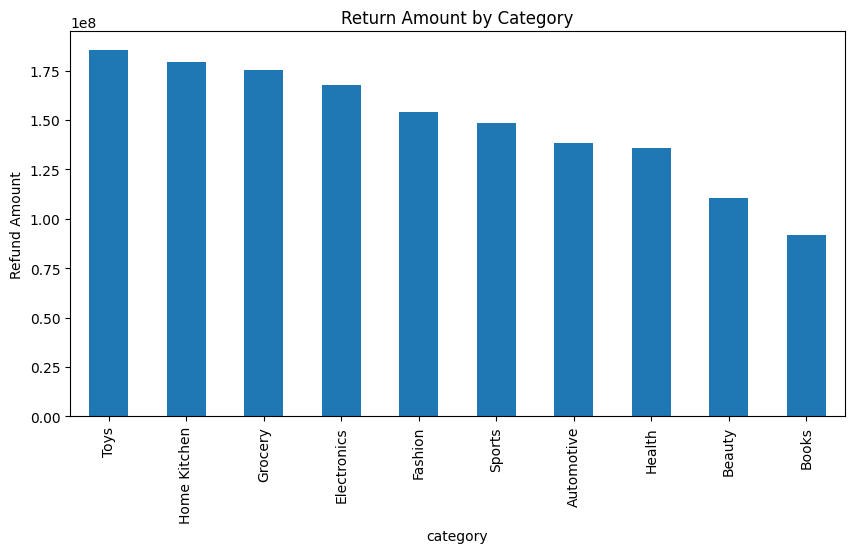

In [2118]:
category_returns = return_analysis.groupby(
    'category'
)['refund_amount'].sum().sort_values(ascending=False)

print(category_returns)

category_returns.plot(kind='bar', figsize=(10,5))

plt.title('Return Amount by Category')
plt.ylabel('Refund Amount')

plt.show()

##### Seller-wise Return Amount

In [2119]:
seller_returns = return_analysis.groupby(
    'seller_id'
)['refund_amount'].sum().sort_values(ascending=False)

seller_returns.head(10)

seller_id
7074    18488567.38
8161    17907908.60
7666    17883601.20
7594    17604538.27
8345    16820143.60
8249    16414290.88
8287    15791949.46
7862    15528540.02
8246    15276007.80
7711    14537260.24
Name: refund_amount, dtype: float64

#### 3. Return Count by City, Warehouse, Delivery Partner, Product Category

##### Merge Delivery Data

In [2120]:
returns_delivery = (
    returns
    .merge(orders[['order_id','delivery_city']], on='order_id')
    .merge(delivery_logs, on='order_id')
    .merge(order_items[['order_id','product_id']], on='order_id')
    .merge(products[['product_id','category']], on='product_id')
)

##### City-wise Returns

In [2121]:
city_returns = returns_delivery.groupby(
    'delivery_city'
)['return_id'].count().sort_values(ascending=False)

city_returns.head(10)

delivery_city
Noida                 3686
Delhi                 3634
Jaipur                3459
Thiruvananthapuram    3405
Lucknow               3331
Chennai               3310
Visakhapatnam         3292
Gurugram              3253
Bangalore             3234
Indore                3208
Name: return_id, dtype: int64

##### Warehouse-wise Returns

In [2122]:
warehouse_returns = returns_delivery.groupby(
    'warehouse_id'
)['return_id'].count().sort_values(ascending=False)

warehouse_returns

warehouse_id
127    2329
104    1088
122    1076
129    1054
146    1041
106    1040
118    1038
125    1037
149    1028
110    1026
105    1014
101    1008
102     998
112     993
115     989
135     984
148     982
134     978
117     977
126     973
143     972
103     969
144     968
119     961
150     959
141     958
130     952
123     950
114     944
145     940
132     936
139     934
136     930
133     928
128     928
131     925
138     925
107     919
111     916
147     913
140     912
120     911
109     901
137     891
124     882
113     881
121     878
116     854
142     852
108     833
Name: return_id, dtype: int64

##### Delivery Partner Returns

In [2123]:
partner_returns = returns_delivery.groupby(
    'delivery_partner'
)['return_id'].count().sort_values(ascending=False)

partner_returns

delivery_partner
Ekart        33383
Delhivery     8668
BlueDart      7224
Name: return_id, dtype: int64

##### Product Category Returns

In [2124]:
product_returns = returns_delivery.groupby(
    'category'
)['return_id'].count().sort_values(ascending=False)

product_returns

category
Grocery         5209
Health          5207
Toys            5056
Automotive      5008
Electronics     4932
Sports          4931
Fashion         4858
Home Kitchen    4832
Books           4720
Beauty          4522
Name: return_id, dtype: int64

#### 4. Monthly Order, Return, and Refund Trends

##### Create Month Columns

In [2125]:
orders['month'] = pd.to_datetime(
    orders['order_datetime']
).dt.to_period('M')

returns['month'] = pd.to_datetime(
    returns['return_request_date']
).dt.to_period('M')

refunds['month'] = pd.to_datetime(
    refunds['refund_processed_date']
).dt.to_period('M')

##### Monthly Orders,Returns,Refunds

In [2126]:
monthly_orders = orders.groupby(
    'month'
)['order_id'].count()

In [2127]:
monthly_returns = returns.groupby(
    'month'
)['return_id'].count()

In [2128]:
monthly_refunds = refunds.groupby(
    'month'
)['refund_amount'].sum()

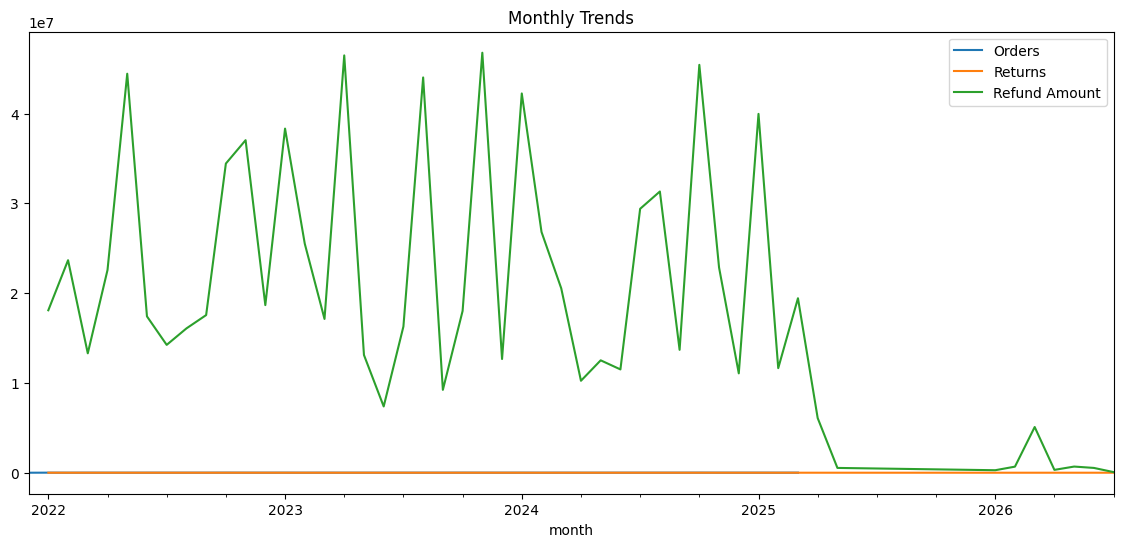

In [2129]:
plt.figure(figsize=(14,6))

monthly_orders.plot(label='Orders')
monthly_returns.plot(label='Returns')
monthly_refunds.plot(label='Refund Amount')

plt.legend()
plt.title('Monthly Trends')

plt.show()

#### 5. Customer Age Group vs Return Behavior

##### Create Age Groups

In [2130]:
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[0,18,25,35,45,60,100],
    labels=[
        '0-18',
        '19-25',
        '26-35',
        '36-45',
        '46-60',
        '60+'
    ]
)

##### Merge Returns with Customers

In [2131]:
age_returns = (
    returns
    .merge(customers[['customer_id','age_group']],
           on='customer_id')
)

##### Return Count by Age Group

In [2132]:
age_group_returns = age_returns.groupby(
    'age_group'
)['return_id'].count()

age_group_returns

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\896923782.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_returns = age_returns.groupby(


age_group
0-18       759
19-25     5082
26-35     7396
36-45     7353
46-60    11507
60+      10782
Name: return_id, dtype: int64

#### 6. Payment Method vs Cancellation/Return Behavior

##### Cancellation Analysis

In [2133]:
cancel_analysis = orders.groupby(
    ['payment_method','order_status']
)['order_id'].count()

cancel_analysis

payment_method  order_status
Bitcoin         Cancelled         332
                Delivered        1396
                Pending           128
                Processing        200
                Returned          255
                Shipped           120
Card            Cancelled        7855
                Delivered       28976
                Pending          2630
                Processing       4232
                Returned         5681
                Shipped          2615
Cod             Cancelled        7395
                Delivered       27387
                Pending          2405
                Processing       3898
                Returned         5451
                Shipped          2458
Emi             Cancelled        1900
                Delivered        7078
                Pending           632
                Processing        980
                Returned         1398
                Shipped           652
Netbanking      Cancelled        2964
                Deliv

##### Return Analysis

In [2134]:
payment_returns = (
    returns
    .merge(
        orders[['order_id','payment_method']],
        on='order_id'
    )
)

payment_return_analysis = payment_returns.groupby(
    'payment_method'
)['return_id'].count()

payment_return_analysis

payment_method
Bitcoin         435
Card           8959
Cod            8469
Emi            2234
Netbanking     3514
Upi           15040
Wallet         4228
Name: return_id, dtype: int64

#### 7. Product Rating vs Return Rate

##### Merge Ratings with Returns

In [2135]:
rating_returns = (
    products[['product_id','product_rating']]
    .merge(order_items[['order_id','product_id']], on='product_id')
    .merge(returns[['order_id','return_id']], on='order_id')
)

##### Return Rate by Rating

In [2136]:
rating_return_rate = rating_returns.groupby(
    'product_rating'
)['return_id'].count()

rating_return_rate

product_rating
2.50    147
2.51    289
2.52    303
2.53    274
2.54    267
       ... 
4.96    185
4.97    302
4.98    324
4.99    280
5.00    797
Name: return_id, Length: 251, dtype: int64

#### 8. Delivery Delay Impact on Return Probability

##### Merge Delivery + Returns

In [2137]:
delay_returns = (
    delivery_logs[['order_id','delay_days']]
    .merge(
        returns[['order_id','return_id']],
        on='order_id',
        how='left'
    )
)

##### Create Return Flag

In [2138]:
delay_returns['returned_flag'] = np.where(
    delay_returns['return_id'].notna(),
    1,
    0
)

##### Delay vs Return Probability

In [2139]:
delay_impact = delay_returns.groupby(
    'delay_days'
)['returned_flag'].mean()

delay_impact

delay_days
0     0.167154
1     0.166462
2     0.171054
3     0.170025
4     0.180308
5     0.175239
6     0.171429
7     0.169903
8     0.157733
9     0.192402
10    0.179423
11    0.185697
12    0.215528
Name: returned_flag, dtype: float64

#### 9. Refund Amount Distribution and Outlier Analysis

##### Distribution


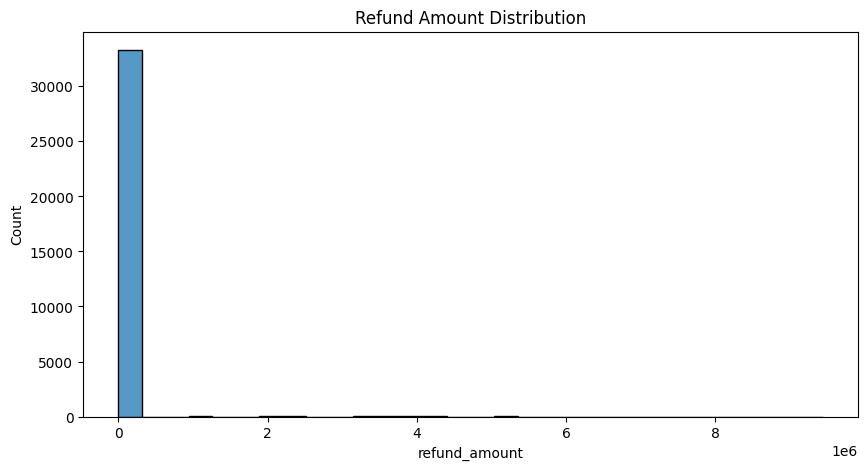

In [2140]:
plt.figure(figsize=(10,5))

sns.histplot(
    refunds['refund_amount'],
    bins=30
)

plt.title('Refund Amount Distribution')

plt.show()

##### Boxplot

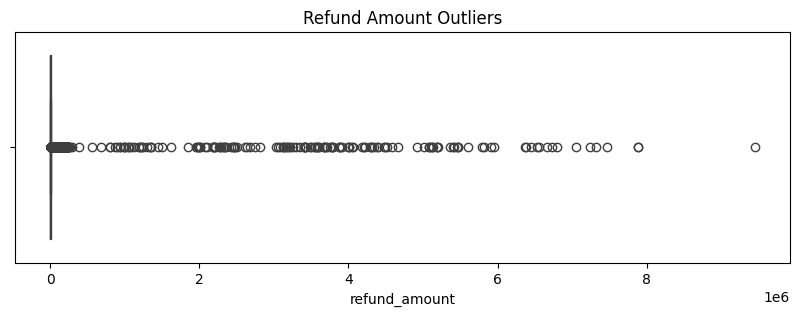

In [2141]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=refunds['refund_amount']
)

plt.title('Refund Amount Outliers')

plt.show()

##### IQR Outlier Detection

In [2142]:
Q1 = refunds['refund_amount'].quantile(0.25)
Q3 = refunds['refund_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

refund_outliers = refunds[
    refunds['refund_amount'] > upper_bound
]

refund_outliers

,refund_id,return_id,refund_amount,refund_status,refund_method,refund_processed_date,refund_reason_code,month
5,8500006,8011010,18090.81,Pending,Original Payment,2024-09-01,SIZE_ISSUE,2024-09
6,8500007,8000027,53099.51,Processed,Coupon,2023-01-18,SIZE_ISSUE,2023-01
13,8500014,8044074,96996.24,Pending,Original Payment,2023-06-23,MISSING_PARTS,2023-06
15,8500016,8004898,33074.32,Processed,Coupon,2023-02-15,DEFECTIVE,2023-02
28,8500029,8000836,31199.38,Processed,Original Payment,2024-03-31,DEFECTIVE,2024-03
...,...,...,...,...,...,...,...,...
34963,8534964,8012322,67963.50,Rejected,Coupon,2023-02-09,QUALITY_ISSUE,2023-02
34964,8534965,8039016,34231.11,Processed,Coupon,2023-05-30,MISSING_PARTS,2023-05
34965,8534966,8019675,20383.87,Processed,Original Payment,2022-05-18,SIZE_ISSUE,2022-05
34967,8534968,8005261,27018.22,Processed,Original Payment,2022-01-15,DUPLICATE_ORDER,2022-01


#### 10. High-Risk Customer and High-Risk Product Profiles

##### High-Risk Customers

In [2143]:
high_risk_customers = returns.groupby(
    'customer_id'
)['return_id'].count().sort_values(ascending=False)

high_risk_customers.head(10)

customer_id
135604.0    26
106468.0    24
108525.0    23
128643.0    23
142644.0    22
119364.0    22
135724.0    22
128886.0    22
146873.0    22
136849.0    21
Name: return_id, dtype: int64

##### Suspicious Customers

In [2144]:
suspicious_customers = returns.groupby(
    'customer_id'
)['is_suspicious_return'].sum().sort_values(ascending=False)

suspicious_customers.head(10)

customer_id
122498.0    11
148531.0    10
104997.0    10
128643.0    10
114430.0    10
148359.0    10
135604.0    10
117475.0     9
142912.0     9
122413.0     9
Name: is_suspicious_return, dtype: int64

##### High-Risk Products

In [2145]:
high_risk_products = (
    returns
    .merge(order_items[['order_id','product_id']], on='order_id')
    .groupby('product_id')['return_id']
    .count()
    .sort_values(ascending=False)
)

high_risk_products.head(10)

product_id
59058    21
58519    21
51194    21
59534    20
57229    19
50611    19
52388    19
57302    19
54606    18
58416    18
Name: return_id, dtype: int64

### Master Table

In [2225]:
# 1. ORDER ITEMS AGGREGATION
order_items_agg = order_items.groupby("order_id").agg(
    total_quantity=("quantity", "sum"),
    total_discount=("discount_amount", "sum"),
    order_item_total=("item_total", "sum"),
    distinct_products=("product_id", "nunique")
).reset_index()
# 3. PAYMENTS AGGREGATION
payments_agg = payments.groupby("order_id").agg(
    total_paid_amount=("payment_amount", "sum"),
    payment_count=("payment_id", "count"),
    payment_status_mode=("payment_status", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    payment_method_mode=("payment_method", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
).reset_index()

# 4. DELIVERY AGGREGATION
delivery_agg = delivery_logs.groupby("order_id").agg(
    delivery_attempts=("delivery_attempts", "max"),
    delay_days=("delay_days", "max"),
    delivery_status_mode=("delivery_status", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    delivery_partner_mode=("delivery_partner", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    warehouse_id=("warehouse_id", "first")
).reset_index()

# 5. RETURNS AGGREGATION
returns_agg = returns.groupby("order_id").agg(
    return_count=("return_id", "count"),
    return_status_mode=("return_status", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    return_pickup_status_mode=("return_pickup_status", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    suspicious_return_flag=("is_suspicious_return", "max")
).reset_index()

# 6. REFUNDS AGGREGATION
# start from a clean copy
refunds_clean = refunds.copy()

# remove old merge columns if they exist
refunds_clean = refunds_clean.loc[:, ~refunds_clean.columns.str.contains(r'^order_id(_x|_y)?$')]

# bring order_id from returns
refund_check = refunds_clean.merge(
    returns[["return_id", "order_id"]],
    on="return_id",
    how="left"
)

# order totals
order_totals = (
    order_items.groupby("order_id")["item_total"]
    .sum()
    .reset_index()
)

# merge totals
refund_check = refund_check.merge(
    order_totals,
    on="order_id",
    how="left"
)

# flag
refund_check["refund_amount_mismatch_flag"] = np.where(
    refund_check["refund_amount"] > refund_check["item_total"],
    1,
    0
)

# 7. REVIEWS AGGREGATION
reviews_agg = reviews.groupby("order_id").agg(
    review_count=("review_id", "count"),
    avg_rating=("rating", "mean")
).reset_index()

# 8. PRODUCT-LEVEL AGGREGATION BY ORDER
product_info = order_items.merge(
    products[["product_id", "seller_id", "category"]],
    on="product_id",
    how="left"
)

product_order_agg = product_info.groupby("order_id").agg(
    distinct_sellers=("seller_id", "nunique"),
    distinct_categories=("category", "nunique")
).reset_index()

# 9. CUSTOMER MASTER FEATURES
customer_features = customers[[
    "customer_id",
    "age",
    "gender",
    "city",
    "state",
    "loyalty_tier",
    "annual_spend"
]].copy()

C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\2572118920.py:38: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  refunds_clean = refunds_clean.loc[:, ~refunds_clean.columns.str.contains(r'^order_id(_x|_y)?$')]


In [2226]:
# 10. CREATE MASTER TABLE
master_table = orders.merge(
    customer_features,
    on="customer_id",
    how="left"
)

master_table = master_table.merge(
    order_items_agg,
    on="order_id",
    how="left"
)

master_table = master_table.merge(
    payments_agg,
    on="order_id",
    how="left"
)

master_table = master_table.merge(
    delivery_agg,
    on="order_id",
    how="left"
)

master_table = master_table.merge(
    returns_agg,
    on="order_id",
    how="left"
)

master_table = master_table.merge(
    refunds_agg,
    on="order_id",
    how="left"
)

master_table = master_table.merge(
    reviews_agg,
    on="order_id",
    how="left"
)

master_table = master_table.merge(
    product_order_agg,
    on="order_id",
    how="left"
)

master_table = master_table.merge(
    warehouses[[
        "warehouse_id",
        "warehouse_name",
        "city",
        "state",
        "region",
        "capacity_units",
        "avg_dispatch_time_hours"
    ]],
    on="warehouse_id",
    how="left",
    suffixes=("", "_warehouse")
)

In [2227]:
# Useful flags
master_table["returned_flag"] = np.where(master_table["return_count"].fillna(0) > 0, 1, 0)
master_table["refunded_flag"] = np.where(master_table["refund_count"].fillna(0) > 0, 1, 0)
master_table["delayed_flag"] = np.where(master_table["delay_days"].fillna(0) > 0, 1, 0)
master_table["cancelled_flag"] = np.where(master_table["order_status"].astype(str).str.lower().eq("cancelled"), 1, 0)

In [2228]:
master_table["delivery_delay_flag"] = np.where(
    master_table["delay_days"].fillna(0) > 0,
    1,
    0
)

master_table["high_value_order_flag"] = np.where(
    master_table["order_item_total"].fillna(0) >
    master_table["order_item_total"].fillna(0).quantile(0.90),
    1,
    0
)

master_table["refund_amount_mismatch_flag"] = np.where(
    master_table["total_refund_amount"].fillna(0) >
    master_table["order_item_total"].fillna(0),
    1,
    0
)

master_table["order_return_risk_score"] = (
    master_table["high_value_order_flag"] * 20 +
    master_table["delivery_delay_flag"] * 15 +
    np.where(master_table["avg_rating"].fillna(5) <= 2, 20, 0) +
    master_table["refund_amount_mismatch_flag"] * 25 +
    np.where(master_table["returned_flag"] == 1, 10, 0)
)

In [2229]:
# CLEAN FINAL NULLS IN IMPORTANT FLAGS

#  Step 1: Group nulls by reason 
print("NULL SUMMARY BY GROUP")
print("="*50)

groups = {
    "Delivery related" : ["actual_delivery_date", "delivery_partner_mode",
                          "warehouse_id", "warehouse_name", "city_warehouse",
                          "state_warehouse", "region", "capacity_units",
                          "avg_dispatch_time_hours"],
    "Payment related"  : ["payment_method_mode"],
    "Return related"   : ["return_pickup_status_mode"],
    "Refund related"   : ["refund_method_mode"]
}

for group, cols in groups.items():
    print(f"\n{group}:")
    for col in cols:
        print(f"  {col:<35} : {master_table[col].isna().sum():>6}")

#Step 2: actual_delivery_date → 81,659 nulls 
# Valid nulls — Cancelled/Pending/Processing orders have no delivery date
master_table["actual_delivery_date"] = master_table["actual_delivery_date"].fillna(pd.NaT)

# Verify it aligns with non-delivered orders
print(master_table[master_table["actual_delivery_date"].isna()]["order_status"]
      .value_counts())

NULL SUMMARY BY GROUP

Delivery related:
  actual_delivery_date                :  81659
  delivery_partner_mode               : 120859
  warehouse_id                        : 120859
  warehouse_name                      : 120859
  city_warehouse                      : 120859
  state_warehouse                     : 120859
  region                              : 120859
  capacity_units                      : 120859
  avg_dispatch_time_hours             : 120859

Payment related:
  payment_method_mode                 : 102807

Return related:
  return_pickup_status_mode           : 209094

Refund related:
  refund_method_mode                  : 225154
order_status
Cancelled     37150
Processing    19836
Shipped       12392
Pending       12281
Name: count, dtype: int64


In [2230]:
# Step 3: payment_method_mode → 1,02,807 nulls 
# Orders with no payment record → fill from order-level payment_method
master_table["payment_method_mode"] = master_table["payment_method_mode"].fillna(
    master_table["payment_method"]
)

# Remaining nulls → Unknown
master_table["payment_method_mode"] = master_table["payment_method_mode"].fillna("Unknown")
print("payment_method_mode nulls:", master_table["payment_method_mode"].isna().sum())

# Step 4: Delivery/Warehouse cols → 1,20,859 nulls 
# Orders with no delivery log → fill with safe defaults

delivery_fill = {
    "delivery_partner_mode"   : "Unknown",
    "warehouse_id"            : 0,              # 0 = not assigned
    "warehouse_name"          : "Not Assigned",
    "city_warehouse"          : "Unknown",
    "state_warehouse"         : "Unknown",
    "region"                  : "Unknown",
    "capacity_units"          : 0,
    "avg_dispatch_time_hours" : 0.0
}

master_table.fillna(delivery_fill, inplace=True)

print("Delivery nulls after fix:")
print(master_table[list(delivery_fill.keys())].isna().sum())

# Step 5: return_pickup_status_mode → 2,09,094 nulls 
# Orders with no return → fill with 'No Return'
master_table["return_pickup_status_mode"] = master_table["return_pickup_status_mode"].fillna(
    "No Return"
)
print("return_pickup_status_mode nulls:", 
      master_table["return_pickup_status_mode"].isna().sum())

# Step 6: refund_method_mode → 2,25,154 nulls 
# Orders with no refund → fill with 'No Refund'
master_table["refund_method_mode"] = master_table["refund_method_mode"].fillna("No Refund")
print("refund_method_mode nulls:", master_table["refund_method_mode"].isna().sum())

payment_method_mode nulls: 0
Delivery nulls after fix:
delivery_partner_mode      0
warehouse_id               0
warehouse_name             0
city_warehouse             0
state_warehouse            0
region                     0
capacity_units             0
avg_dispatch_time_hours    0
dtype: int64
return_pickup_status_mode nulls: 0
refund_method_mode nulls: 0


In [2282]:
master_table["payment_method"] = (
    master_table["payment_method"]
    .astype(str)
    .str.strip()
    .str.upper()
)

cod_mask = master_table["payment_method"] == "COD"

if cod_mask.sum() == 0:
    print("COD order return rate: no COD records found")
else:
    cod_rate = master_table.loc[cod_mask, "returned_flag"].fillna(0).mean() * 100

In [2231]:
# Step 7: Final null check 
remaining_nulls = master_table.isna().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if len(remaining_nulls) == 0:
    print("✔ No nulls remaining in master table")
else:
    print("Remaining nulls:")
    print(remaining_nulls)

Remaining nulls:
actual_delivery_date       81659
total_quantity             50733
total_discount             50733
order_item_total           50733
distinct_products          50733
total_paid_amount         102807
payment_count             102807
payment_status_mode       102807
delivery_attempts         120859
delay_days                120859
delivery_status_mode      120859
return_count              209094
return_status_mode        209094
suspicious_return_flag    209094
refund_count              225154
total_refund_amount       225154
refund_status_mode        225154
review_count              168779
avg_rating                168779
distinct_sellers           50733
distinct_categories        50733
dtype: int64


In [2232]:
print(master_table.shape)
print(master_table.info())
print(master_table.head())
print(master_table.isna().sum())

(246926, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246926 entries, 0 to 246925
Data columns (total 65 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_id                     246926 non-null  int64         
 1   customer_id                  246926 non-null  int64         
 2   order_datetime               246926 non-null  datetime64[ns]
 3   order_status                 246926 non-null  object        
 4   order_amount                 246926 non-null  float64       
 5   payment_method               246926 non-null  object        
 6   coupon_used                  246926 non-null  object        
 7   delivery_city                246926 non-null  object        
 8   expected_delivery_date       246926 non-null  datetime64[ns]
 9   actual_delivery_date         165267 non-null  datetime64[ns]
 10  delivery_completed_flag      246926 non-null  int64         
 11  order_date   

In [2233]:
master_table.head()

,order_id,customer_id,order_datetime,order_status,order_amount,payment_method,coupon_used,delivery_city,expected_delivery_date,actual_delivery_date,...,region,capacity_units,avg_dispatch_time_hours,returned_flag,refunded_flag,delayed_flag,cancelled_flag,delivery_delay_flag,refund_amount_mismatch_flag,order_return_risk_score
0,9000001,108061,2024-03-31 19:24:00,Cancelled,72531.29,Netbanking,No,Jaipur,2024-04-05,NaT,...,North,269430.0,25.24,0,0,0,1,0,0,0
1,9000002,137163,2023-11-28 20:54:00,Delivered,598.24,Card,No,Jaipur,2023-12-01,2023-12-03,...,South,379766.0,28.83,0,0,0,0,0,0,0
2,9000003,111418,2024-09-11 17:38:00,Cancelled,3625.41,Upi,No,Bangalore,2024-09-13,NaT,...,Unknown,0.0,0.00,0,0,0,1,0,0,20
3,9000004,106360,2024-11-27 12:48:00,Delivered,11113.80,Wallet,No,Gurugram,2024-12-02,2024-12-03,...,North,731262.0,16.77,1,1,1,0,1,0,25
4,9000005,107971,2023-12-21 14:22:00,Cancelled,1820.50,Wallet,Yes,Jaipur,2023-12-26,NaT,...,Unknown,0.0,0.00,0,0,0,1,0,0,20


## Feature Engineering

In [2235]:
# 1. ORDER MONTH
orders["order_month"] = (
    orders["order_datetime"].dt.month_name()
)

In [2236]:
# 2. ORDER DAY NAME
orders["order_day_name"] = (
    orders["order_datetime"].dt.day_name()
)

In [2237]:
# IS FESTIVAL PERIOD
# Example festival months in India:
# Oct, Nov, Dec
festival_months = [10, 11, 12]

orders["is_festival_period"] = np.where(
    orders["order_datetime"].dt.month.isin(festival_months),
    1,
    0
)

In [2238]:
# 4. DELIVERY DELAY FLAG
# delay_days > 0
delivery_logs["delivery_delay_flag"] = np.where(
    delivery_logs["delay_days"] > 0,
    1,
    0
)

In [2239]:
# 5. HIGH VALUE ORDER FLAG
# Orders above 90th percentile
order_values = (
    order_items.groupby("order_id")["item_total"]
    .sum()
    .reset_index()
)

high_value_threshold = (
    order_values["item_total"].quantile(0.90)
)

order_values["high_value_order_flag"] = np.where(
    order_values["item_total"] > high_value_threshold,
    1,
    0
)

orders = orders.merge(
    order_values[["order_id", "high_value_order_flag"]],
    on="order_id",
    how="left"
)

In [2240]:
# 6. RETURN WITHIN 24 HOURS FLAG
returns_check = returns.merge(
    orders[["order_id", "actual_delivery_date"]],
    on="order_id",
    how="left"
)

returns_check["return_hours"] = (
    (
        returns_check["return_request_date"] -
        returns_check["actual_delivery_date"]
    ).dt.total_seconds() / 3600
)

returns_check["return_within_24_hours_flag"] = np.where(
    returns_check["return_hours"] <= 24,
    1,
    0
)

In [2241]:
#  7. REPEAT RETURN CUSTOMER FLAG
customer_returns = (
    returns.groupby("customer_id")["return_id"]
    .count()
    .reset_index(name="total_returns")
)

customer_returns["repeat_return_customer_flag"] = np.where(
    customer_returns["total_returns"] >= 3,
    1,
    0
)

In [2244]:
## ── Step 2: Get order_id from Returns into Refunds ───────────────
# Returns has both return_id and order_id
# Merge refunds with returns on return_id to get order_id
# Remove old merged columns if already present
refunds = refunds.drop(
    columns=[
        col for col in refunds.columns
        if col.startswith("order_id")
        or col.startswith("customer_id")
    ],
    errors="ignore"
)

# Now merge safely
refunds = refunds.merge(
    returns[["return_id", "order_id", "customer_id"]],
    on="return_id",
    how="left"
)

print(refunds.columns)
print(refunds.head())

Index(['refund_id', 'return_id', 'refund_amount', 'refund_status',
       'refund_method', 'refund_processed_date', 'refund_reason_code', 'month',
       'order_id', 'customer_id'],
      dtype='object')
   refund_id  return_id  refund_amount refund_status     refund_method  \
0    8500001    8022000        3682.07       Pending  Original Payment   
1    8500002    8003316        4723.20     Processed  Original Payment   
2    8500003    8024548        7419.70      Rejected            Wallet   
3    8500004    8020163        1055.04     Processed  Original Payment   
4    8500005    8022732        1192.03     Processed  Original Payment   

  refund_processed_date refund_reason_code    month  order_id  customer_id  
0            2025-03-18       CHANGED_MIND  2025-03   9178529     127922.0  
1            2024-01-13      QUALITY_ISSUE  2024-01   9133916     127584.0  
2            2022-04-30      MISSING_PARTS  2022-04   9176591     126195.0  
3            2022-01-23       CHANGED_MIND 

In [2246]:
#  8. REFUND AMOUNT MISMATCH FLAG
# Returns has both return_id and order_id
# Merge refunds with returns on return_id to get order_id


#  Now retry the refund check merge 
refund_check = refunds.merge(
    order_totals,
    on="order_id",
    how="left"
)

print("Merge successful — shape:", refund_check.shape)
print(refund_check.head())

print(refund_check.columns)   # check that order_id is present

# Step 2: order totals by order_id
# ── Step 5: Rebuild with correct column name from order_items ────
# Use whatever column name exists in order_items
# Could be: item_total / order_item_total / line_total / total_price

total_col = "item_total"        # ← change this to match your column name

order_totals = (
    order_items
    .groupby("order_id")[total_col]
    .sum()
    .reset_index()
    .rename(columns={total_col: "order_item_total"})
)


# Step 3: merge order totals
refund_check = refund_check.merge(
    order_totals,
    on="order_id",
    how="left"
)

# Step 4: mismatch flag
refund_check["refund_amount_mismatch_flag"] = np.where(
    refund_check["refund_amount"] > refund_check["order_item_total_x"], 1, 0
)

Merge successful — shape: (33444, 11)
   refund_id  return_id  refund_amount refund_status     refund_method  \
0    8500001    8022000        3682.07       Pending  Original Payment   
1    8500002    8003316        4723.20     Processed  Original Payment   
2    8500003    8024548        7419.70      Rejected            Wallet   
3    8500004    8020163        1055.04     Processed  Original Payment   
4    8500005    8022732        1192.03     Processed  Original Payment   

  refund_processed_date refund_reason_code    month  order_id  customer_id  \
0            2025-03-18       CHANGED_MIND  2025-03   9178529     127922.0   
1            2024-01-13      QUALITY_ISSUE  2024-01   9133916     127584.0   
2            2022-04-30      MISSING_PARTS  2022-04   9176591     126195.0   
3            2022-01-23       CHANGED_MIND  2022-01   9213258     133977.0   
4            2024-01-23   NOT_AS_DESCRIBED  2024-01   9079165     104687.0   

   order_item_total  
0           2328.11  
1   

In [2247]:
# 9. PRODUCT RETURN RATE
product_orders = (
    order_items.groupby("product_id")["order_id"]
    .count()
    .reset_index(name="total_orders")
)

product_returns = (
    returns.merge(order_items, on="order_id")
    .groupby("product_id")["return_id"]
    .count()
    .reset_index(name="total_returns")
)

product_return_rate = product_orders.merge(
    product_returns,
    on="product_id",
    how="left"
)

product_return_rate["total_returns"] = (
    product_return_rate["total_returns"]
    .fillna(0)
)

product_return_rate["product_return_rate"] = (
    product_return_rate["total_returns"] /
    product_return_rate["total_orders"]
) * 100


In [2248]:
# 10. SELLER RETURN RISK FLAG
seller_risk_threshold = (
    sellers["return_rate_percent"].quantile(0.90)
)

sellers["seller_return_risk_flag"] = np.where(
    sellers["return_rate_percent"] >
    seller_risk_threshold,
    1,
    0
)

In [2249]:
# 11. WAREHOUSE DELAY FLAG
warehouse_delay = (
    delivery_logs.groupby("warehouse_id")["delay_days"]
    .mean()
    .reset_index(name="avg_delay")
)

warehouse_delay["warehouse_delay_flag"] = np.where(
    warehouse_delay["avg_delay"] > 3,
    1,
    0
)

In [2250]:
# 12. CUSTOMER LIFETIME VALUE (CLV)
customer_lifetime_value = (
    orders.merge(order_items, on="order_id")
    .groupby("customer_id")["item_total"]
    .sum()
    .reset_index(name="customer_lifetime_value")
)

In [2251]:
# 13. CUSTOMER RETURN RISK SCORE
customer_risk = customer_returns.merge(
    customer_lifetime_value,
    on="customer_id",
    how="left"
)

customer_risk["customer_return_risk_score"] = (
    customer_risk["total_returns"] * 10
)

In [2252]:
# 14. PRODUCT RETURN RISK SCORE
product_return_rate["product_return_risk_score"] = (
    product_return_rate["product_return_rate"] * 0.5
)


In [2255]:
# 15. ORDER RETURN RISK SCORE
mt = master_table.copy()
# Make sure required columns exist
required_cols = [
    "order_item_total",
    "delay_days",
    "avg_rating",
    "total_refund_amount",
    "return_count",
    "returned_flag"
]

for col in required_cols:
    if col not in mt.columns:
        mt[col] = 0

# Fill missing values
mt["order_item_total"] = mt["order_item_total"].fillna(0)
mt["delay_days"] = mt["delay_days"].fillna(0)
mt["avg_rating"] = mt["avg_rating"].fillna(5)
mt["total_refund_amount"] = mt["total_refund_amount"].fillna(0)
mt["return_count"] = mt["return_count"].fillna(0)
mt["returned_flag"] = mt["returned_flag"].fillna(0)

# Feature flags
mt["high_value_order_flag"] = np.where(
    mt["order_item_total"] > mt["order_item_total"].quantile(0.90),
    1,
    0
)

mt["delivery_delay_flag"] = np.where(mt["delay_days"] > 3, 1, 0)

mt["low_rating_flag"] = np.where(mt["avg_rating"] <= 2, 1, 0)

mt["refund_amount_mismatch_flag"] = np.where(
    mt["total_refund_amount"] > mt["order_item_total"],
    1,
    0
)

mt["repeat_return_flag"] = np.where(mt["return_count"] >= 2, 1, 0)

# Final order return risk score
mt["order_return_risk_score"] = (
    mt["high_value_order_flag"] * 20 +
    mt["delivery_delay_flag"] * 25 +
    mt["low_rating_flag"] * 15 +
    mt["refund_amount_mismatch_flag"] * 25 +
    mt["repeat_return_flag"] * 15 +
    mt["returned_flag"] * 10
)

print(mt[[
    "order_id",
    "order_item_total",
    "delay_days",
    "avg_rating",
    "total_refund_amount",
    "return_count",
    "order_return_risk_score"
]].head())

   order_id  order_item_total  delay_days  avg_rating  total_refund_amount  \
0   9000001          24637.73         0.0         5.0                 0.00   
1   9000002            739.82         0.0         3.0                 0.00   
2   9000003         692106.64         0.0         4.0                 0.00   
3   9000004         216134.49         3.0         5.0             10204.74   
4   9000005              0.00         0.0         1.0                 0.00   

   return_count  order_return_risk_score  
0           0.0                        0  
1           0.0                        0  
2           0.0                       20  
3           1.0                       10  
4           0.0                       15  


#### Final Review

In [2256]:
# final review
print(risk_data.head())
print(customer_risk.head())
print(product_return_rate.head())

   order_id  customer_id      order_datetime order_status  order_amount  \
0   9000001       108061 2024-03-31 19:24:00    Cancelled      72531.29   
1   9000002       137163 2023-11-28 20:54:00    Delivered        598.24   
2   9000003       111418 2024-09-11 17:38:00    Cancelled       3625.41   
3   9000004       106360 2024-11-27 12:48:00    Delivered      11113.80   
4   9000005       107971 2023-12-21 14:22:00    Cancelled       1820.50   

  payment_method coupon_used delivery_city expected_delivery_date  \
0     Netbanking          No        Jaipur             2024-04-05   
1           Card          No        Jaipur             2023-12-01   
2            Upi          No     Bangalore             2024-09-13   
3         Wallet          No      Gurugram             2024-12-02   
4         Wallet         Yes        Jaipur             2023-12-26   

  actual_delivery_date  ...  order_year_month    weekday is_weekend quarter  \
0                  NaT  ...           2024-03     Sunda

In [2257]:
risk_data.head()

,order_id,customer_id,order_datetime,order_status,order_amount,payment_method,coupon_used,delivery_city,expected_delivery_date,actual_delivery_date,...,order_year_month,weekday,is_weekend,quarter,month,order_day_name,is_festival_period,high_value_order_flag_x,high_value_order_flag_y,delay_days
0,9000001,108061,2024-03-31 19:24:00,Cancelled,72531.29,Netbanking,No,Jaipur,2024-04-05,NaT,...,2024-03,Sunday,True,1,2024-03,Sunday,0,0.0,0.0,0.0
1,9000002,137163,2023-11-28 20:54:00,Delivered,598.24,Card,No,Jaipur,2023-12-01,2023-12-03,...,2023-11,Tuesday,False,4,2023-11,Tuesday,1,0.0,0.0,0.0
2,9000003,111418,2024-09-11 17:38:00,Cancelled,3625.41,Upi,No,Bangalore,2024-09-13,NaT,...,2024-09,Wednesday,False,3,2024-09,Wednesday,0,1.0,1.0,NaN
3,9000004,106360,2024-11-27 12:48:00,Delivered,11113.80,Wallet,No,Gurugram,2024-12-02,2024-12-03,...,2024-11,Wednesday,False,4,2024-11,Wednesday,1,0.0,0.0,3.0
4,9000005,107971,2023-12-21 14:22:00,Cancelled,1820.50,Wallet,Yes,Jaipur,2023-12-26,NaT,...,2023-12,Thursday,False,4,2023-12,Thursday,1,NaN,NaN,NaN


In [2258]:
customer_risk.head()

,customer_id,total_returns,repeat_return_customer_flag,customer_lifetime_value,customer_return_risk_score
0,100002.0,1,0,37920.87,10
1,100003.0,1,0,546259.18,10
2,100005.0,1,0,775868.43,10
3,100006.0,1,0,607086.70,10
4,100009.0,2,0,250278.82,20


In [2259]:
product_return_rate.head()

,product_id,total_orders,total_returns,product_return_rate,product_return_risk_score
0,50001,25,4.0,16.000000,8.000000
1,50002,41,8.0,19.512195,9.756098
2,50003,37,3.0,8.108108,4.054054
3,50004,29,4.0,13.793103,6.896552
4,50006,37,4.0,10.810811,5.405405


## Business Summary


### 1.What is the overall return rate and refund loss?

In [2262]:
total_orders = master_table["order_id"].nunique()
total_returns = master_table.loc[master_table["returned_flag"] == 1, "order_id"].nunique()
return_rate = (total_returns / total_orders) * 100

refund_loss = master_table["total_refund_amount"].fillna(0).sum()

print("Total Orders:", total_orders)
print("Total Returned Orders:", total_returns)
print("Return Rate %:", round(return_rate, 2))
print("Total Refund Loss:", round(refund_loss, 2))

Total Orders: 246926
Total Returned Orders: 37832
Return Rate %: 15.32
Total Refund Loss: 935335721.71


### 2. Which product categories have the highest return exposure?

In [2263]:
order_products = order_items.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

category_return = order_products.merge(
    returns[["order_id", "return_id"]],
    on="order_id",
    how="left"
)

category_return = category_return.groupby("category").agg(
    total_orders=("order_id", "nunique"),
    returned_orders=("return_id", "count"),
    total_revenue=("item_total", "sum")
).reset_index()

category_return["return_rate_pct"] = (
    category_return["returned_orders"] / category_return["total_orders"] * 100
)

category_return = category_return.sort_values(
    ["return_rate_pct", "total_revenue"],
    ascending=False
)

print(category_return.head(10))

       category  total_orders  returned_orders  total_revenue  return_rate_pct
3   Electronics         35732             6853   2.900818e+09        19.178887
6        Health         37321             7088   3.207953e+09        18.991988
4       Fashion         35846             6791   3.485666e+09        18.944931
5       Grocery         38115             7195   3.618081e+09        18.877083
9          Toys         36799             6935   3.649496e+09        18.845621
0    Automotive         36819             6936   4.107550e+09        18.838100
8        Sports         37334             7031   3.959856e+09        18.832699
2         Books         35315             6620   2.732706e+09        18.745576
7  Home Kitchen         35188             6549   1.846930e+09        18.611458
1        Beauty         33543             6242   2.699304e+09        18.608950


### 3. Which customers repeatedly abuse return/refund policies?

In [2264]:
customer_risk = master_table.groupby("customer_id").agg(
    total_orders=("order_id", "nunique"),
    total_returns=("returned_flag", "sum"),
    total_refunds=("refunded_flag", "sum"),
    total_refund_amount=("total_refund_amount", "sum"),
    avg_rating=("avg_rating", "mean")
).reset_index()

customer_risk["return_rate_pct"] = (
    customer_risk["total_returns"] / customer_risk["total_orders"] * 100
)

abusive_customers = customer_risk[
    (customer_risk["total_returns"] >= 3) |
    (customer_risk["total_refunds"] >= 3) |
    (customer_risk["return_rate_pct"] > 30)
].sort_values(["total_returns", "total_refund_amount"], ascending=False)

print(abusive_customers.head(20))

       customer_id  total_orders  total_returns  total_refunds  \
48752       149130            11              6              5   
21341       121497            11              6              4   
5666        105713            11              6              4   
19372       119520            10              6              3   
23847       124022            13              6              2   
13508       113607            11              5              5   
15773       115887             7              5              2   
26714       126910            13              5              4   
29562       129782             8              5              3   
9398        109464             6              5              2   
13721       113821            14              5              3   
32986       133237             7              5              2   
42908       143241             7              5              4   
1733        101746             8              5              3   
47513     

### 4. Which warehouses and delivery partners are linked to high returns?

In [2265]:
warehouse_return = master_table.groupby("warehouse_name").agg(
    total_orders=("order_id", "nunique"),
    returned_orders=("returned_flag", "sum"),
    avg_delay=("delay_days", "mean")
).reset_index()

warehouse_return["return_rate_pct"] = (
    warehouse_return["returned_orders"] / warehouse_return["total_orders"] * 100
)

print(warehouse_return.sort_values("return_rate_pct", ascending=False).head(10))

                   warehouse_name  total_orders  returned_orders  avg_delay  \
20           Kolkata Regional Hub          2439              415   1.813038   
14   Hyderabad Fulfillment Center          2501              425   1.924030   
6     Chennai Distribution Centre          2470              400   1.900810   
24       Mumbai Central Warehouse          4944              794   1.899272   
17            Jaipur Regional Hub          7315             1171   1.876145   
16     Jaipur Distribution Centre          2470              395   1.906883   
11             Delhi Regional Hub          2528              401   1.900712   
8            Chennai Regional Hub          2484              393   1.853865   
22     Lucknow Fulfillment Center          2326              364   1.965176   
13  Hyderabad Distribution Centre          2418              377   1.874690   

    return_rate_pct  
20        17.015170  
14        16.993203  
6         16.194332  
24        16.059871  
17        16.008202 

In [2266]:
partner_return = master_table.groupby("delivery_partner_mode").agg(
    total_orders=("order_id", "nunique"),
    returned_orders=("returned_flag", "sum"),
    avg_delay=("delay_days", "mean")
).reset_index()

partner_return["return_rate_pct"] = (
    partner_return["returned_orders"] / partner_return["total_orders"] * 100
)

print(partner_return.sort_values("return_rate_pct", ascending=False).head(10))

  delivery_partner_mode  total_orders  returned_orders  avg_delay  \
3               Unknown        120859            18592        NaN   
0              BlueDart         22541             3467   1.967260   
2                 Ekart         78900            12043   1.836477   
1             Delhivery         24626             3730   1.934216   

   return_rate_pct  
3        15.383215  
0        15.380862  
2        15.263625  
1        15.146593  


### 5.How do delivery delays impact customer satisfaction and returns?


In [2267]:
delay_impact = master_table.groupby("delayed_flag").agg(
    orders=("order_id", "nunique"),
    avg_rating=("avg_rating", "mean"),
    return_rate=("returned_flag", "mean"),
    refund_loss=("total_refund_amount", "sum")
).reset_index()

delay_impact["return_rate"] = delay_impact["return_rate"] * 100

print(delay_impact)

   delayed_flag  orders  avg_rating  return_rate   refund_loss
0             0  162774    3.946994    15.325543  6.124354e+08
1             1   84152    3.939426    15.312767  3.229004e+08


#### buckets

In [2268]:
master_table["delay_bucket"] = pd.cut(
    master_table["delay_days"].fillna(0),
    bins=[-1, 0, 3, 7, 999],
    labels=["On Time", "1-3 Days", "4-7 Days", "8+ Days"]
)

delay_bucket_analysis = master_table.groupby("delay_bucket").agg(
    orders=("order_id", "nunique"),
    avg_rating=("avg_rating", "mean"),
    return_rate=("returned_flag", "mean"),
    refund_loss=("total_refund_amount", "sum")
).reset_index()

delay_bucket_analysis["return_rate"] = delay_bucket_analysis["return_rate"] * 100
print(delay_bucket_analysis)

  delay_bucket  orders  avg_rating  return_rate   refund_loss
0      On Time  162774    3.946994    15.325543  6.124354e+08
1     1-3 Days   70192    3.937510    15.181217  2.749069e+08
2     4-7 Days    6142    3.938178    15.125366  2.312765e+07
3      8+ Days    7818    3.957784    16.641085  2.486584e+07


C:\Users\Shiva\AppData\Local\Temp\ipykernel_26016\3097237214.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_bucket_analysis = master_table.groupby("delay_bucket").agg(


### 6.Which payment methods are associated with cancellations and returns?

In [2269]:
payment_analysis = master_table.groupby("payment_method").agg(
    orders=("order_id", "nunique"),
    cancelled_orders=("cancelled_flag", "sum"),
    returned_orders=("returned_flag", "sum"),
    refund_loss=("total_refund_amount", "sum")
).reset_index()

payment_analysis["cancel_rate_pct"] = (
    payment_analysis["cancelled_orders"] / payment_analysis["orders"] * 100
)

payment_analysis["return_rate_pct"] = (
    payment_analysis["returned_orders"] / payment_analysis["orders"] * 100
)

print(payment_analysis.sort_values("return_rate_pct", ascending=False))

  payment_method  orders  cancelled_orders  returned_orders   refund_loss  \
4     Netbanking   19739              2964             3089  6.039751e+07   
3            Emi   12640              1900             1969  4.811193e+07   
0        Bitcoin    2431               332              377  4.949341e+06   
5            Upi   86462             12992            13320  3.216477e+08   
1           Card   51989              7855             7927  2.389368e+08   
2            Cod   48994              7395             7434  1.791921e+08   
6         Wallet   24671              3712             3716  8.210041e+07   

   cancel_rate_pct  return_rate_pct  
4        15.015958        15.649222  
3        15.031646        15.577532  
0        13.656931        15.508021  
5        15.026254        15.405612  
1        15.108965        15.247456  
2        15.093685        15.173287  
6        15.046005        15.062219  


### 7.Which products generate high revenue but also high return loss?

In [2270]:
product_analysis = order_items.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

# returns by product
product_returns = returns.merge(
    order_items[["order_id", "product_id", "item_total"]],
    on="order_id",
    how="left"
)

product_summary = product_analysis.groupby("product_id").agg(
    revenue=("item_total", "sum"),
    qty_sold=("quantity", "sum"),
    category=("category", "first")
).reset_index()

product_return_loss = product_returns.groupby("product_id").agg(
    return_count=("return_id", "count")
).reset_index()

product_summary = product_summary.merge(
    product_return_loss,
    on="product_id",
    how="left"
)

product_summary["return_count"] = product_summary["return_count"].fillna(0)

print(
    product_summary.sort_values(
        ["revenue", "return_count"],
        ascending=False
    ).head(20)
)

      product_id       revenue  qty_sold     category  return_count
3700       53746  7.483710e+08      95.5      Grocery          10.0
8672       58771  5.755118e+08      74.0   Automotive           5.0
847        50862  5.601276e+08      80.0       Health           8.0
8969       59071  5.224210e+08      76.0         Toys          12.0
6956       57031  4.976467e+08      77.0       Sports           4.0
4354       54407  4.514364e+08      69.0       Beauty           8.0
4280       54331  4.378728e+08      66.0   Automotive          10.0
8415       58513  4.009299e+08      79.0   Automotive           8.0
3437       53477  3.998614e+08      66.0        Books           4.0
5638       55701  3.850789e+08      73.0      Grocery           2.0
8132       58228  3.714494e+08      49.0      Fashion           5.0
3398       53438  3.593752e+08      91.0         Toys           9.0
1326       51344  3.232424e+08      78.0       Sports           8.0
3636       53680  3.093357e+08     100.0       S

### 8.Which cities and regions show abnormal return behavior?

In [2271]:
geo_analysis = master_table.groupby(["city", "state"]).agg(
    orders=("order_id", "nunique"),
    returned_orders=("returned_flag", "sum"),
    refund_loss=("total_refund_amount", "sum")
).reset_index()

geo_analysis["return_rate_pct"] = (
    geo_analysis["returned_orders"] / geo_analysis["orders"] * 100
)

print(geo_analysis.sort_values("return_rate_pct", ascending=False).head(20))

                  city           state  orders  returned_orders   refund_loss  \
4             Gurugram         Haryana   16028             2548  7.050616e+07   
8              Kolkata     West Bengal   16340             2594  5.759972e+07   
12                Pune     Maharashtra   17012             2656  1.024648e+08   
3                Delhi           Delhi   16277             2520  8.497077e+07   
6               Indore  Madhya Pradesh   16271             2516  7.793492e+07   
10              Mumbai     Maharashtra   17033             2630  2.709019e+07   
11               Noida   Uttar Pradesh   16112             2478  7.293876e+07   
5            Hyderabad       Telangana   16294             2495  3.545142e+07   
0            Ahmedabad         Gujarat   16347             2499  2.893814e+07   
1            Bangalore       Karnataka   16786             2543  7.253311e+07   
7               Jaipur       Rajasthan   16647             2518  6.526100e+07   
9              Lucknow   Utt

#### warehouse region

In [2272]:
region_analysis = master_table.groupby("region").agg(
    orders=("order_id", "nunique"),
    returned_orders=("returned_flag", "sum"),
    refund_loss=("total_refund_amount", "sum")
).reset_index()

region_analysis["return_rate_pct"] = (
    region_analysis["returned_orders"] / region_analysis["orders"] * 100
)

print(region_analysis.sort_values("return_rate_pct", ascending=False))

    region  orders  returned_orders   refund_loss  return_rate_pct
2    South   39348             6098  1.170100e+08        15.497611
3  Unknown  120859            18592  4.657101e+08        15.383215
0     East   12226             1878  2.934602e+07        15.360707
1    North   34006             5183  1.349142e+08        15.241428
4     West   40487             6081  1.883554e+08        15.019636


### 9.Can we create a return risk score for customers/orders/products?

In [2273]:
master_table["delivery_delay_flag"] = np.where(
    master_table["delay_days"].fillna(0) > 0,
    1,
    0
)

master_table["high_value_order_flag"] = np.where(
    master_table["order_item_total"].fillna(0) >
    master_table["order_item_total"].fillna(0).quantile(0.90),
    1,
    0
)

master_table["refund_amount_mismatch_flag"] = np.where(
    master_table["total_refund_amount"].fillna(0) >
    master_table["order_item_total"].fillna(0),
    1,
    0
)

master_table["order_return_risk_score"] = (
    master_table["high_value_order_flag"] * 20 +
    master_table["delivery_delay_flag"] * 15 +
    np.where(master_table["avg_rating"].fillna(5) <= 2, 20, 0) +
    master_table["refund_amount_mismatch_flag"] * 25 +
    np.where(master_table["returned_flag"] == 1, 10, 0)
)

In [2274]:
master_table["order_return_risk_score"] = (
    master_table["high_value_order_flag"].fillna(0) * 20 +
    np.where(master_table["delayed_flag"] == 1, 15, 0) +
    np.where(master_table["avg_rating"].fillna(5) <= 2, 20, 0) +
    np.where(master_table["refund_amount_mismatch_flag"].fillna(0) == 1, 25, 0) +
    np.where(master_table["returned_flag"] == 1, 10, 0)
)

print(master_table[["order_id", "order_return_risk_score"]].head())

   order_id  order_return_risk_score
0   9000001                        0
1   9000002                        0
2   9000003                       20
3   9000004                       25
4   9000005                       20


#### Customer return risk score

In [2275]:
customer_risk_score = master_table.groupby("customer_id").agg(
    total_returns=("returned_flag", "sum"),
    total_refunds=("refunded_flag", "sum"),
    total_refund_amount=("total_refund_amount", "sum"),
    avg_rating=("avg_rating", "mean"),
    total_orders=("order_id", "nunique")
).reset_index()

customer_risk_score["customer_return_risk_score"] = (
    customer_risk_score["total_returns"] * 10 +
    customer_risk_score["total_refunds"] * 8 +
    np.where(customer_risk_score["avg_rating"].fillna(5) <= 2, 15, 0)
)

print(customer_risk_score.sort_values("customer_return_risk_score", ascending=False).head(20))

       customer_id  total_returns  total_refunds  total_refund_amount  \
13508       113607              5              5            366954.70   
48752       149130              6              5            199884.38   
21341       121497              6              4             42711.77   
5666        105713              6              4             33524.70   
18570       118709              5              5             10650.66   
19372       119520              6              3             27549.23   
46214       146568              5              4             14802.09   
42908       143241              5              4             84308.15   
26714       126910              5              4            200314.04   
46303       146659              5              4              6170.22   
46527       146886              5              4             16965.09   
22763       122932              5              4             24377.75   
20507       120659              5              4   

#### Product return risk score

In [2276]:
product_risk_score = order_items.groupby("product_id").agg(
    qty_sold=("quantity", "sum"),
    revenue=("item_total", "sum")
).reset_index()

product_return_counts = returns.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="left"
).groupby("product_id").agg(
    return_count=("return_id", "count")
).reset_index()

product_risk_score = product_risk_score.merge(
    product_return_counts,
    on="product_id",
    how="left"
)

product_risk_score["return_count"] = product_risk_score["return_count"].fillna(0)
product_risk_score["product_return_risk_score"] = (
    product_risk_score["return_count"] * 10
)

print(product_risk_score.sort_values("product_return_risk_score", ascending=False).head(20))

      product_id  qty_sold      revenue  return_count  \
1178       51194      89.0   9835166.55          21.0   
8956       59058      58.0    238553.25          21.0   
8421       58519      80.0    163613.93          21.0   
9423       59534      90.0    212448.32          20.0   
599        50611      73.0    141694.49          19.0   
7145       57229      91.0     44689.38          19.0   
2361       52388      72.0    174705.87          19.0   
7217       57302      90.0     17032.61          19.0   
5091       55152     108.0    961068.21          18.0   
9871       59983      83.0   3399201.62          18.0   
4550       54606      89.0     64847.43          18.0   
8318       58416      69.0    452589.97          18.0   
5045       55106      70.0    226398.46          17.0   
5040       55101      79.0    228869.57          17.0   
7697       57787      86.0    300298.15          17.0   
9371       59481      72.0     44380.06          17.0   
2628       52657     102.0    3

### 10.What operational actions should ShopKart take to reduce return losses?

### EXECUTIVE SUMMARY - ECOMMERCE RETURNS ANALYSIS

In [2283]:
overall_return_rate = (
    master_table["returned_flag"].mean() * 100
)

total_refund_loss = (
    master_table["total_refund_amount"]
    .fillna(0)
    .sum()
)

average_order_value = (
    master_table["order_item_total"]
    .fillna(0)
    .mean()
)

delivery_delay_rate = (
    master_table["delivery_delay_flag"]
    .mean() * 100
)

high_risk_order_rate = (
    master_table.loc[
        master_table["order_return_risk_score"] >= 40,
        "returned_flag"
    ].mean() * 100
)

average_customer_rating = (
    master_table["avg_rating"]
    .fillna(0)
    .mean()
)

cod_return_rate = (
    master_table.loc[
        master_table["payment_method"] == "COD",
        "returned_flag"
    ].mean() * 100
)

print("EXECUTIVE SUMMARY")
print("-----------------")

print(f"Overall return rate: {overall_return_rate:.2f}%")

print(f"Total refund loss: ₹{total_refund_loss:,.2f}")

print(f"Average order value: ₹{average_order_value:,.2f}")

print(f"Delivery delay rate: {delivery_delay_rate:.2f}%")

print(f"High-risk order return rate: {high_risk_order_rate:.2f}%")

print(f"Average customer rating: {average_customer_rating:.2f}")

print(f"COD order return rate: {cod_return_rate:.2f}%")

EXECUTIVE SUMMARY
-----------------
Overall return rate: 15.32%
Total refund loss: ₹935,335,721.71
Average order value: ₹128,023.03
Delivery delay rate: 34.08%
High-risk order return rate: 86.83%
Average customer rating: 1.25
COD order return rate: 15.17%


# Business Recommendations  

## Recommendation 1: Product Quality Improvement  
* Strengthen supplier quality audits  
* Introduce pre-dispatch quality checks  
* Monitor category-wise return rates  

## Recommendation 2: Control Refund Leakage
* Approval workflow for high-value refunds  
* Refund amount validation  
* Weekly refund audit reports  

## Recommendation 3: High-Risk Customer Monitoring  
* Restrict COD for high-risk customers    
* Manual approval for repeated returns  
* Monitor suspicious return patterns  

## Recommendation 4:  Warehouse Performance Improvement
* Monitor warehouse-wise return rate  
* Track damaged product claims  
* Improve packaging standards  
* Conduct warehouse audits  

## Recommendation 5: Reduce Delivery Delays  
* SLA monitoring for delivery partners
* Track warehouse dispatch time daily  
* Penalize underperforming logistics partners  
* Route optimization  
* Increase warehouse coverage in high-demand regions  

## Recommendation 6: Improve Customer Experience  
* Analyze negative reviews  
* Improve product descriptions  
* Improve size guidesEnhance  
* packaging quality  
* Faster complaint resolution   

## Recommendation 7: COD Risk Reduction  
* Encourage prepaid orders by Offer:5% discount for prepaid orders  
* Restrict COD for repeat returners  
* COD confirmation before shipping  



### Export Clean Final Dataset

In [2278]:
output_file = 'C:/Users/Shiva/Downloads/ecommerce_raw/ecommerce_return_clean_analytics.csv' 
master_table.to_csv(output_file, index=False)
print('Saved file:', output_file)

Saved file: C:/Users/Shiva/Downloads/ecommerce_raw/ecommerce_return_clean_analytics.csv
